In [2]:
import pandas as pd
import requests

print("pandas works!")
print("requests works!")

pandas works!
requests works!


In [3]:
import requests

url = "https://clinicaltrials.gov/api/v2/version"

response = requests.get(url)

print("Status code:", response.status_code)
print(response.json())

Status code: 200
{'apiVersion': '2.0.5', 'dataTimestamp': '2026-08-31T09:00:04'}


In [4]:
url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "query.cond": "depression",
    "pageSize": 5,
    "countTotal": "true"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

print("Total matching studies:", data.get("totalCount"))
print("Studies returned in this test:", len(data.get("studies", [])))

for study in data.get("studies", []):
    identification = study["protocolSection"]["identificationModule"]
    
    print(
        identification.get("nctId"),
        "-",
        identification.get("briefTitle")
    )

Total matching studies: 12738
Studies returned in this test: 5
NCT00345384 - Dexmedetomidine for the Control of Post-Operative Pain in Thoracotomy Patients
NCT04599855 - A Study of Esketamine Nasal Spray, Administered as Monotherapy, in Adult Participants With Treatment-resistant Depression
NCT01430455 - Tranylcypromine Treatment of Bipolar Depression
NCT00816725 - Effectiveness of a Web-based Prevention Program for Postpartum Depression
NCT07639476 - Study on Mental Health Promoting Effects of Natural Psychotherapy for Adolescents


In [5]:
url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "query.cond": 'depression OR "major depressive disorder" OR "depressive disorder" OR dysthymia',
    "query.term": "AREA[StudyType]INTERVENTIONAL AND AREA[OverallStatus]RECRUITING",
    "pageSize": 10,
    "countTotal": "true"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

print("Total recruiting interventional matches:", data.get("totalCount"))
print("Studies shown:", len(data.get("studies", [])))
print()

for study in data.get("studies", []):
    protocol = study["protocolSection"]
    
    identification = protocol["identificationModule"]
    conditions = protocol.get("conditionsModule", {}).get("conditions", [])
    status = protocol.get("statusModule", {}).get("overallStatus")
    design = protocol.get("designModule", {}).get("studyType")
    
    print("NCT:", identification.get("nctId"))
    print("Title:", identification.get("briefTitle"))
    print("Conditions:", conditions)
    print("Status:", status)
    print("Study type:", design)
    print("-" * 70)

Total recruiting interventional matches: 1220
Studies shown: 10

NCT: NCT07705776
Title: SanaMente: A Peer-Led Program to Reduce Health Disparities in Rural Latino/a Communities
Conditions: ['Depression and/or Anxiety in the Mild-to-moderate Range', 'Stress (Psychology)', 'Chronic Medical Illness']
Status: RECRUITING
Study type: INTERVENTIONAL
----------------------------------------------------------------------
NCT: NCT04864080
Title: Transdiagnostic Cognitive Biomarkers
Conditions: ['Pain', 'Depression']
Status: RECRUITING
Study type: INTERVENTIONAL
----------------------------------------------------------------------
NCT: NCT06971549
Title: Accelerated iTBS for Depression: Monitoring Brain Hemodynamics With Simultaneous iTBS/fNIRS
Conditions: ['Depression']
Status: RECRUITING
Study type: INTERVENTIONAL
----------------------------------------------------------------------
NCT: NCT07025590
Title: Effect of Exercise on Tapering Antipsychotics in Patients With Psycho-cardiological Di

In [6]:
url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "query.cond": 'depression OR "major depressive disorder" OR "depressive disorder" OR dysthymia',
    "query.term": "AREA[StudyType]INTERVENTIONAL AND AREA[OverallStatus]RECRUITING",
    "query.locn": "United States",
    "pageSize": 10,
    "countTotal": "true"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

print("Recruiting interventional matches with U.S. locations:",
      data.get("totalCount"))
print()

for study in data.get("studies", []):
    
    protocol = study["protocolSection"]
    
    identification = protocol["identificationModule"]
    conditions = protocol.get("conditionsModule", {})
    eligibility = protocol.get("eligibilityModule", {})
    locations_module = protocol.get("contactsLocationsModule", {})
    
    locations = locations_module.get("locations", [])
    
    # Count recruiting U.S. locations for this study
    recruiting_us_sites = [
        loc for loc in locations
        if loc.get("country") == "United States"
        and loc.get("status") == "RECRUITING"
    ]
    
    print("NCT:", identification.get("nctId"))
    print("Title:", identification.get("briefTitle"))
    print("Conditions:", conditions.get("conditions", []))
    print("Minimum age:", eligibility.get("minimumAge"))
    print("Maximum age:", eligibility.get("maximumAge"))
    print("Age groups:", eligibility.get("stdAges", []))
    print("Recruiting U.S. sites:", len(recruiting_us_sites))
    
    print("-" * 70)

Recruiting interventional matches with U.S. locations: 574

NCT: NCT07705776
Title: SanaMente: A Peer-Led Program to Reduce Health Disparities in Rural Latino/a Communities
Conditions: ['Depression and/or Anxiety in the Mild-to-moderate Range', 'Stress (Psychology)', 'Chronic Medical Illness']
Minimum age: 18 Years
Maximum age: None
Age groups: ['ADULT', 'OLDER_ADULT']
Recruiting U.S. sites: 1
----------------------------------------------------------------------
NCT: NCT04864080
Title: Transdiagnostic Cognitive Biomarkers
Conditions: ['Pain', 'Depression']
Minimum age: 18 Years
Maximum age: None
Age groups: ['ADULT', 'OLDER_ADULT']
Recruiting U.S. sites: 1
----------------------------------------------------------------------
NCT: NCT07639359
Title: Subanesthetic Ketamine Infusions for Depressive Symptoms in Intensive Care Unit Patients
Conditions: ['Depression Disorder', 'Ketamine']
Minimum age: 18 Years
Maximum age: 99 Years
Age groups: ['ADULT', 'OLDER_ADULT']
Recruiting U.S. sites

In [7]:
# ============================================================
# FILTER TO ADULT STUDIES WITH ≥1 RECRUITING U.S. SITE
# ============================================================

url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "query.cond": 'depression OR "major depressive disorder" OR "depressive disorder" OR dysthymia',
    "query.term": "AREA[StudyType]INTERVENTIONAL AND AREA[OverallStatus]RECRUITING",
    "query.locn": "United States",
    "pageSize": 1000,
    "countTotal": "true"
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()

all_us_studies = data.get("studies", [])

print("Studies downloaded:", len(all_us_studies))


# ------------------------------------------------------------
# Adult + recruiting U.S. site filter
# ------------------------------------------------------------

adult_recruiting_us_studies = []

for study in all_us_studies:

    protocol = study["protocolSection"]

    eligibility = protocol.get("eligibilityModule", {})
    locations_module = protocol.get("contactsLocationsModule", {})

    age_groups = eligibility.get("stdAges", [])

    # Trial must include at least some adults
    adult_flag = (
        "ADULT" in age_groups
        or "OLDER_ADULT" in age_groups
    )

    locations = locations_module.get("locations", [])

    # Trial must have at least one individual U.S. site
    # whose site-level status is RECRUITING
    recruiting_us_sites = [
        loc for loc in locations
        if loc.get("country") == "United States"
        and loc.get("status") == "RECRUITING"
    ]

    if adult_flag and len(recruiting_us_sites) > 0:
        adult_recruiting_us_studies.append(study)


print(
    "Adult studies with ≥1 recruiting U.S. site:",
    len(adult_recruiting_us_studies)
)

print(
    "Excluded by adult/site filter:",
    len(all_us_studies) - len(adult_recruiting_us_studies)
)

Studies downloaded: 574
Adult studies with ≥1 recruiting U.S. site: 547
Excluded by adult/site filter: 27


In [8]:
# ============================================================
# BUILD STUDY-LEVEL SCREENING DATASET
# One row = one adult recruiting U.S. study
# ============================================================

screening_rows = []

for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get("identificationModule", {})
    conditions_module = protocol.get("conditionsModule", {})
    eligibility = protocol.get("eligibilityModule", {})
    design = protocol.get("designModule", {})
    sponsors = protocol.get("sponsorCollaboratorsModule", {})
    locations_module = protocol.get("contactsLocationsModule", {})

    conditions = conditions_module.get("conditions", [])
    keywords = conditions_module.get("keywords", [])

    locations = locations_module.get("locations", [])

    recruiting_us_sites = [
        loc for loc in locations
        if loc.get("country") == "United States"
        and loc.get("status") == "RECRUITING"
    ]

    lead_sponsor = sponsors.get("leadSponsor", {})

    screening_rows.append({
        "nct_id": identification.get("nctId"),
        "brief_title": identification.get("briefTitle"),
        "conditions": " | ".join(conditions),
        "keywords": " | ".join(keywords),
        "minimum_age": eligibility.get("minimumAge"),
        "maximum_age": eligibility.get("maximumAge"),
        "age_groups": " | ".join(eligibility.get("stdAges", [])),
        "phases": " | ".join(design.get("phases", [])),
        "lead_sponsor": lead_sponsor.get("name"),
        "sponsor_class": lead_sponsor.get("class"),
        "recruiting_us_sites": len(recruiting_us_sites)
    })


screening_df = pd.DataFrame(screening_rows)


print("Rows in screening dataset:", len(screening_df))
print()
print(screening_df.head(10))

Rows in screening dataset: 547

        nct_id                                        brief_title  \
0  NCT07705776  SanaMente: A Peer-Led Program to Reduce Health...   
1  NCT04864080               Transdiagnostic Cognitive Biomarkers   
2  NCT07639359  Subanesthetic Ketamine Infusions for Depressiv...   
3  NCT07717385  Sleep More, Stress Less: 90-Day Trial of Neura...   
4  NCT06728774  Cognitive Rehabilitation for Veterans With MDD...   
5  NCT05523817  Targeting Specific Brain Networks to Treat Spe...   
6  NCT05754151        Mobile CBT for Middle Aged and Older Adults   
7  NCT07039305      Physical Capacity Building for Chronic Stroke   
8  NCT06088732  Effects of Acute Exercise and Ibuprofen on Sym...   
9  NCT05895747        5-HTP and Creatine for Depression R33 Phase   

                                          conditions  \
0  Depression and/or Anxiety in the Mild-to-moder...   
1                                  Pain | Depression   
2                     Depression Disorde

In [9]:
# ============================================================
# COUNT THE MOST COMMON CONDITION LABELS
# ============================================================

from collections import Counter

condition_counter = Counter()

for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    conditions = (
        protocol
        .get("conditionsModule", {})
        .get("conditions", [])
    )

    for condition in conditions:
        condition_counter[condition] += 1


# Convert to dataframe
condition_counts_df = pd.DataFrame(
    condition_counter.items(),
    columns=["condition", "count"]
)

condition_counts_df = (
    condition_counts_df
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)


print("Number of unique condition labels:",
      len(condition_counts_df))

print()

print(condition_counts_df.head(30))

Number of unique condition labels: 614

                                 condition  count
0                               Depression    206
1                Major Depressive Disorder     88
2                                  Anxiety     66
3                      Depressive Symptoms     27
4          Major Depressive Disorder (MDD)     21
5                      Depression, Anxiety     20
6   Depression - Major Depressive Disorder     19
7                        Suicidal Ideation     15
8               Depressive Disorder, Major     14
9           Treatment Resistant Depression     13
10                       Anxiety Disorders     13
11                        Bipolar Disorder     12
12                                 Suicide     12
13                                  Stress     12
14                   Postpartum Depression     12
15                                   Sleep     11
16                                    PTSD     10
17                                  Cancer      9
18        

In [10]:
# ============================================================
# FLAG GENERAL ADULT DEPRESSION STUDIES
# ============================================================

general_depression_labels = {
    "depression",
    "major depressive disorder",
    "major depressive disorder (mdd)",
    "depression - major depressive disorder",
    "depression – major depressive disorder",
    "depressive disorder, major",
    "treatment resistant depression",
    "treatment-resistant depression",
    "major depression",
    "depressive disorder",
    "depression disorders"
}


def has_general_depression_condition(condition_string):
    
    if pd.isna(condition_string):
        return False
    
    labels = [
        x.strip().lower()
        for x in condition_string.split("|")
    ]
    
    return any(
        label in general_depression_labels
        for label in labels
    )


screening_df["general_depression_candidate"] = (
    screening_df["conditions"]
    .apply(has_general_depression_condition)
)


print(
    "Total adult recruiting U.S. studies:",
    len(screening_df)
)

print(
    "General depression candidates:",
    screening_df["general_depression_candidate"].sum()
)

print(
    "Other / specialized studies:",
    (~screening_df["general_depression_candidate"]).sum()
)

Total adult recruiting U.S. studies: 547
General depression candidates: 351
Other / specialized studies: 196


In [11]:
# ============================================================
# LOOK FOR SPECIALIZED / COMORBID CONDITIONS
# AMONG GENERAL DEPRESSION CANDIDATES
# ============================================================

candidate_df = screening_df[
    screening_df["general_depression_candidate"]
].copy()


other_condition_counter = Counter()

for condition_string in candidate_df["conditions"]:

    labels = [
        x.strip()
        for x in condition_string.split("|")
    ]

    for label in labels:

        if label.lower() not in general_depression_labels:
            other_condition_counter[label] += 1


other_conditions_df = pd.DataFrame(
    other_condition_counter.items(),
    columns=["other_condition", "count"]
)

other_conditions_df = (
    other_conditions_df
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)


print("General depression candidates:", len(candidate_df))

print(
    "Candidates with at least one additional condition:",
    candidate_df["conditions"].str.contains(
        r"\|",
        regex=True
    ).sum()
)

print()

print(other_conditions_df.head(40))

General depression candidates: 351
Candidates with at least one additional condition: 240

                             other_condition  count
0                                    Anxiety     58
1                          Suicidal Ideation     13
2                          Anxiety Disorders     10
3                                     Stress     10
4                           Bipolar Disorder      9
5                                      Sleep      9
6                                       PTSD      8
7                                    Suicide      8
8                                     Cancer      7
9                        Depressive Symptoms      7
10                             Schizophrenia      7
11            Post Traumatic Stress Disorder      6
12                                       HIV      6
13                                      Pain      6
14                             Mental Health      5
15                                 Anhedonia      5
16                       

In [12]:
# ============================================================
# IDENTIFY ALL DEPRESSION-RELATED CONDITION LABEL VARIANTS
# ============================================================

depression_label_review = condition_counts_df[
    condition_counts_df["condition"].str.contains(
        r"depress|mdd",
        case=False,
        regex=True,
        na=False
    )
].copy()

depression_label_review = (
    depression_label_review
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print(
    "Number of condition labels containing 'depress' or 'MDD':",
    len(depression_label_review)
)

print()

print(
    depression_label_review
    .head(100)
    .to_string(index=False)
)

Number of condition labels containing 'depress' or 'MDD': 93

                                                                               condition  count
                                                                              Depression    206
                                                               Major Depressive Disorder     88
                                                                     Depressive Symptoms     27
                                                         Major Depressive Disorder (MDD)     21
                                                                     Depression, Anxiety     20
                                                  Depression - Major Depressive Disorder     19
                                                              Depressive Disorder, Major     14
                                                          Treatment Resistant Depression     13
                                                                   Postpar

In [13]:
# ============================================================
# CLASSIFY DEPRESSION STUDIES:
# 1 = CLEAR GENERAL DEPRESSION
# 2 = SPECIALIZED / NEEDS REVIEW
# 3 = NOT PRIMARY DEPRESSIVE DISORDER
# ============================================================

import re


# ------------------------------------------------------------
# Patterns that represent a depressive-disorder diagnosis
# ------------------------------------------------------------

general_patterns = [
    r"^depression$",
    r"major depressive disorder",
    r"\bmdd\b",
    r"major depression",
    r"major depressive episode",
    r"depressive disorder,? major",
    r"^depressive disorder$",
    r"depression disorders",
    r"depression disorder",
    r"treatment[- ]?resistant depression",
    r"treatment resistant major depression",
    r"treatment[- ]?resistant major depressive disorder",
    r"depressive disorder, treatment[- ]?resistant",
    r"persistent depressive disorder",
    r"dysthymia",
    r"recurrent depression",
    r"unipolar depression",
    r"clinical depression",
    r"depression not otherwise specified",
    r"major depression disorders"
]


# ------------------------------------------------------------
# Specialized populations / diagnoses
# These are NOT automatically thrown away.
# They are sent to manual review.
# ------------------------------------------------------------

specialized_patterns = [
    r"bipolar",
    r"postpartum",
    r"post partum",
    r"perinatal",
    r"poststroke",
    r"post-stroke",
    r"post stroke",
    r"adolescen",
    r"\bteen\b",
    r"menopaus",
    r"premenstrual",
    r"\bpmdd\b",
    r"postoperative",
    r"post-operative",
    r"stroke",
    r"pregnan",
    r"cancer",
    r"hiv",
    r"epilep",
    r"parkinson",
    r"autis",
    r"adjustment disorder"
]


# ------------------------------------------------------------
# Labels that contain the word "depression" but do NOT
# represent the depressive disorder we are studying
# ------------------------------------------------------------

nonpsychiatric_patterns = [
    r"respiratory depression",
    r"ventilatory depression"
]


# ------------------------------------------------------------
# Symptom-only terms
# We do not count these as a depressive-disorder diagnosis
# unless another qualifying depression diagnosis is present.
# ------------------------------------------------------------

symptom_only_patterns = [
    r"depressive symptoms",
    r"depressive symptom",
    r"symptoms of depression",
    r"subclinical depressive symptoms",
    r"mood depressed"
]


def matches_any(text, patterns):
    text = str(text).lower()

    return any(
        re.search(pattern, text, flags=re.IGNORECASE)
        for pattern in patterns
    )


def classify_study(row):

    conditions = str(row["conditions"])
    title = str(row["brief_title"])

    combined_text = conditions + " | " + title

    # Explicit non-psychiatric uses of "depression"
    if matches_any(combined_text, nonpsychiatric_patterns):
        return "EXCLUDE_NONPSYCHIATRIC"

    # Does the study contain a qualifying depression diagnosis?
    has_general = matches_any(
        conditions,
        general_patterns
    )

    # Does it appear to target a specialized population?
    has_specialized = matches_any(
        combined_text,
        specialized_patterns
    )

    # Symptom-only depression without a qualifying diagnosis
    symptom_only = (
        matches_any(conditions, symptom_only_patterns)
        and not has_general
    )

    if has_general and has_specialized:
        return "SPECIALIZED_REVIEW"

    elif has_general:
        return "GENERAL_DEPRESSION"

    elif symptom_only:
        return "EXCLUDE_SYMPTOM_ONLY"

    else:
        return "MANUAL_REVIEW"


screening_df["screen_category"] = screening_df.apply(
    classify_study,
    axis=1
)


print("STUDY SCREENING RESULTS")
print("-----------------------")

print(
    screening_df["screen_category"]
    .value_counts()
)

print()
print("Total:", len(screening_df))

STUDY SCREENING RESULTS
-----------------------
screen_category
MANUAL_REVIEW             301
GENERAL_DEPRESSION        187
EXCLUDE_SYMPTOM_ONLY       29
SPECIALIZED_REVIEW         28
EXCLUDE_NONPSYCHIATRIC      2
Name: count, dtype: int64

Total: 547


In [14]:
# ============================================================
# INSPECT THE MANUAL REVIEW GROUP
# Find the most common condition labels
# ============================================================

manual_df = screening_df[
    screening_df["screen_category"] == "MANUAL_REVIEW"
].copy()

manual_condition_counter = Counter()

for condition_string in manual_df["conditions"]:

    labels = [
        x.strip()
        for x in str(condition_string).split("|")
        if x.strip()
    ]

    for label in labels:
        manual_condition_counter[label] += 1


manual_condition_counts = pd.DataFrame(
    manual_condition_counter.items(),
    columns=["condition", "count"]
)

manual_condition_counts = (
    manual_condition_counts
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)


print("Studies in manual review:", len(manual_df))
print()

print(
    manual_condition_counts
    .head(50)
    .to_string(index=False)
)

Studies in manual review: 301

                  condition  count
                 Depression    146
                    Anxiety     52
        Depression, Anxiety     19
      Postpartum Depression     12
                     Stress     10
                      Sleep     10
                    Suicide     10
                  Anhedonia      8
                       Pain      8
                        HIV      7
            Quality of Life      7
                     Cancer      7
              Mental Health      6
                       PTSD      6
                   Insomnia      6
          Anxiety Disorders      6
       Perinatal Depression      6
  Depression in Adolescence      6
          Suicidal Ideation      6
               Hypertension      5
           Bipolar Disorder      5
          Physical Activity      5
          Sleep Disturbance      5
               Chronic Pain      5
         Bipolar Depression      5
         Bipolar I Disorder      5
                     Str

In [15]:
# ============================================================
# IMPROVED STUDY CLASSIFIER
# Evaluate each condition label separately
# ============================================================

def split_conditions(condition_string):
    """
    Turn:
    'Depression | Anxiety | Stress'
    
    into:
    ['Depression', 'Anxiety', 'Stress']
    """
    
    if pd.isna(condition_string):
        return []
    
    return [
        x.strip()
        for x in str(condition_string).split("|")
        if x.strip()
    ]


def any_label_matches(labels, patterns):
    
    for label in labels:
        for pattern in patterns:
            if re.search(
                pattern,
                label,
                flags=re.IGNORECASE
            ):
                return True
    
    return False


def improved_classify_study(row):

    condition_labels = split_conditions(
        row["conditions"]
    )

    title = str(row["brief_title"])

    # --------------------------------------------------------
    # 1. Non-psychiatric uses of "depression"
    # --------------------------------------------------------
    
    has_nonpsychiatric = any_label_matches(
        condition_labels,
        nonpsychiatric_patterns
    )
    
    if has_nonpsychiatric:
        return "EXCLUDE_NONPSYCHIATRIC"


    # --------------------------------------------------------
    # 2. Does at least one condition clearly represent
    #    a depressive disorder?
    # --------------------------------------------------------
    
    has_general_depression = any_label_matches(
        condition_labels,
        general_patterns
    )


    # --------------------------------------------------------
    # 3. Specialized population/diagnosis?
    #
    # Check both condition labels and title.
    # --------------------------------------------------------
    
    has_specialized_condition = any_label_matches(
        condition_labels,
        specialized_patterns
    )
    
    has_specialized_title = matches_any(
        title,
        specialized_patterns
    )
    
    has_specialized = (
        has_specialized_condition
        or has_specialized_title
    )


    # --------------------------------------------------------
    # 4. Depression symptom language only?
    # --------------------------------------------------------
    
    has_symptom_only = any_label_matches(
        condition_labels,
        symptom_only_patterns
    )


    # --------------------------------------------------------
    # 5. Final classification
    # --------------------------------------------------------
    
    if has_general_depression and has_specialized:
        return "SPECIALIZED_REVIEW"

    elif has_general_depression:
        return "GENERAL_DEPRESSION"

    elif has_symptom_only:
        return "EXCLUDE_SYMPTOM_ONLY"

    else:
        return "MANUAL_REVIEW"


# Create corrected variable
screening_df["screen_category_v2"] = (
    screening_df.apply(
        improved_classify_study,
        axis=1
    )
)


print("CORRECTED STUDY SCREENING RESULTS")
print("---------------------------------")

print(
    screening_df["screen_category_v2"]
    .value_counts()
)

print()
print("Total:", len(screening_df))

CORRECTED STUDY SCREENING RESULTS
---------------------------------
screen_category_v2
GENERAL_DEPRESSION        291
MANUAL_REVIEW             153
SPECIALIZED_REVIEW         78
EXCLUDE_SYMPTOM_ONLY       23
EXCLUDE_NONPSYCHIATRIC      2
Name: count, dtype: int64

Total: 547


In [16]:
# ============================================================
# INSPECT REMAINING MANUAL REVIEW STUDIES
# AFTER CORRECTED CLASSIFIER
# ============================================================

manual_v2_df = screening_df[
    screening_df["screen_category_v2"] == "MANUAL_REVIEW"
].copy()

manual_v2_counter = Counter()

for condition_string in manual_v2_df["conditions"]:

    labels = [
        x.strip()
        for x in str(condition_string).split("|")
        if x.strip()
    ]

    for label in labels:
        manual_v2_counter[label] += 1


manual_v2_conditions = pd.DataFrame(
    manual_v2_counter.items(),
    columns=["condition", "count"]
)

manual_v2_conditions = (
    manual_v2_conditions
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)


print("Remaining manual-review studies:", len(manual_v2_df))
print()

print(
    manual_v2_conditions
    .head(60)
    .to_string(index=False)
)

Remaining manual-review studies: 153

                                              condition  count
                                    Depression, Anxiety     17
                                  Postpartum Depression     11
                              Depression in Adolescence      5
                                     Bipolar I Disorder      5
                                     Bipolar Depression      5
                                   Perinatal Depression      5
                                 Post Partum Depression      4
                                     Postpartum Anxiety      4
                            Postpartum Depression (PPD)      4
                                    Bipolar II Disorder      4
                                              Anhedonia      4
                                      Physical Activity      4
                                                Anxiety      4
                                                Suicide      4
                 

In [17]:
# ============================================================
# SPLIT REMAINING MANUAL REVIEWS INTO:
# A) HAS A DEPRESSION/MDD CONDITION LABEL
# B) NO DEPRESSION/MDD CONDITION LABEL
# ============================================================

def has_depression_word_in_condition(condition_string):

    labels = split_conditions(condition_string)

    for label in labels:

        label_lower = label.lower()

        if (
            "depress" in label_lower
            or re.search(r"\bmdd\b", label_lower)
        ):
            return True

    return False


manual_v2_df["has_depression_condition_label"] = (
    manual_v2_df["conditions"]
    .apply(has_depression_word_in_condition)
)


print("REMAINING MANUAL REVIEW BREAKDOWN")
print("---------------------------------")

print(
    manual_v2_df[
        "has_depression_condition_label"
    ].value_counts()
)

print()

print(
    "Manual studies WITH a depression/MDD condition label:",
    manual_v2_df[
        "has_depression_condition_label"
    ].sum()
)

print(
    "Manual studies WITHOUT a depression/MDD condition label:",
    (~manual_v2_df[
        "has_depression_condition_label"
    ]).sum()
)

REMAINING MANUAL REVIEW BREAKDOWN
---------------------------------
has_depression_condition_label
True     89
False    64
Name: count, dtype: int64

Manual studies WITH a depression/MDD condition label: 89
Manual studies WITHOUT a depression/MDD condition label: 64


In [18]:
# ============================================================
# INVESTIGATE THE 64 MANUAL-REVIEW STUDIES
# WITH NO DEPRESSION/MDD CONDITION LABEL
# ============================================================

no_dep_condition_df = manual_v2_df[
    manual_v2_df["has_depression_condition_label"] == False
].copy()


def contains_depression_or_mdd(text):
    
    if pd.isna(text):
        return False
    
    text = str(text).lower()
    
    return (
        "depress" in text
        or re.search(r"\bmdd\b", text) is not None
    )


# Check whether depression appears elsewhere
no_dep_condition_df["depression_in_title"] = (
    no_dep_condition_df["brief_title"]
    .apply(contains_depression_or_mdd)
)

no_dep_condition_df["depression_in_keywords"] = (
    no_dep_condition_df["keywords"]
    .apply(contains_depression_or_mdd)
)


# Create simple review grouping
def classify_no_condition_match(row):
    
    if row["depression_in_title"]:
        return "DEPRESSION_IN_TITLE"
    
    elif row["depression_in_keywords"]:
        return "DEPRESSION_IN_KEYWORDS_ONLY"
    
    else:
        return "NO_EXPLICIT_DEPRESSION"
    

no_dep_condition_df["review_group"] = (
    no_dep_condition_df.apply(
        classify_no_condition_match,
        axis=1
    )
)


print("64-STUDY BREAKDOWN")
print("------------------")

print(
    no_dep_condition_df["review_group"]
    .value_counts()
)

print()
print("Total:", len(no_dep_condition_df))

64-STUDY BREAKDOWN
------------------
review_group
DEPRESSION_IN_KEYWORDS_ONLY    38
DEPRESSION_IN_TITLE            15
NO_EXPLICIT_DEPRESSION         11
Name: count, dtype: int64

Total: 64


In [19]:
# ============================================================
# INSPECT THE 11 STUDIES WITH NO EXPLICIT DEPRESSION SIGNAL
# ============================================================

no_explicit_dep_df = no_dep_condition_df[
    no_dep_condition_df["review_group"] == "NO_EXPLICIT_DEPRESSION"
].copy()

print(
    no_explicit_dep_df[
        [
            "nct_id",
            "brief_title",
            "conditions",
            "keywords",
            "minimum_age",
            "maximum_age"
        ]
    ].to_string(index=False)
)

     nct_id                                                                                                                                  brief_title                                                                        conditions                                                                                                                                                                                                                                                                                                                                                                                                                        keywords minimum_age maximum_age
NCT06129903                        Study Assessing the Effects of Early Psychiatric Referral on Mental Health and Quality of Life in People With Sarcoma                                      Sarcoma | Bone Sarcoma | Soft Tissue Sarcoma                                                                                           

In [20]:
# ============================================================
# MANUAL SCREENING DECISIONS:
# 11 STUDIES WITH NO EXPLICIT DEPRESSION TARGET
# ============================================================

manual_exclusions = {
    
    "NCT06129903":
        "Sarcoma population; no depressive disorder target",
    
    "NCT06696755":
        "Bipolar I/II disorder; not unipolar depressive disorder",
    
    "NCT07094503":
        "Adolescent body image/eating disorder prevention; no depression target",
    
    "NCT06493825":
        "Tinnitus/misophonia pediatric study; no depression target",
    
    "NCT07688720":
        "Premenstrual dysphoric disorder (PMDD); distinct from depressive disorder",
    
    "NCT07413458":
        "Alcohol use disorder study; no depression target",
    
    "NCT04134754":
        "Epilepsy/SUDEP study; no depression target",
    
    "NCT06704549":
        "Premenstrual dysphoric disorder (PMDD); distinct from depressive disorder",
    
    "NCT06849869":
        "Perinatal mental health systems intervention; no explicit depressive disorder target",
    
    "NCT06240325":
        "Sleep promotion study; no depression target",
    
    "NCT04846777":
        "Generalized anxiety disorder study; no depression target"
}


# ------------------------------------------------------------
# Create manual decision columns if they do not already exist
# ------------------------------------------------------------

if "manual_decision" not in screening_df.columns:
    screening_df["manual_decision"] = None

if "manual_exclusion_reason" not in screening_df.columns:
    screening_df["manual_exclusion_reason"] = None


# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for nct_id, reason in manual_exclusions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = "EXCLUDE"

    screening_df.loc[
        mask,
        "manual_exclusion_reason"
    ] = reason


# ------------------------------------------------------------
# Quality check
# ------------------------------------------------------------

excluded_11 = screening_df[
    screening_df["nct_id"].isin(manual_exclusions.keys())
][
    [
        "nct_id",
        "brief_title",
        "manual_decision",
        "manual_exclusion_reason"
    ]
]


print("Manual exclusions recorded:", len(excluded_11))
print()

print(
    excluded_11.to_string(index=False)
)

Manual exclusions recorded: 10

     nct_id                                                                                                                             brief_title manual_decision                                                              manual_exclusion_reason
NCT06129903                   Study Assessing the Effects of Early Psychiatric Referral on Mental Health and Quality of Life in People With Sarcoma         EXCLUDE                                    Sarcoma population; no depressive disorder target
NCT06696755 A Study to Assess Adverse Events and Change in Disease Activity of Oral Icalcaprant in Adult Participants With Bipolar I or II Disorder         EXCLUDE                              Bipolar I/II disorder; not unipolar depressive disorder
NCT07094503                                                                                                                      Adolescent Chatbot         EXCLUDE               Adolescent body image/eating disorder preve

In [21]:
# ============================================================
# CORRECT THE ONE MISTYPED NCT ID
# ============================================================

correct_nct_id = "NCT06704594"

correct_reason = (
    "Premenstrual dysphoric disorder (PMDD); "
    "distinct from depressive disorder"
)

mask = screening_df["nct_id"] == correct_nct_id

screening_df.loc[
    mask,
    "manual_decision"
] = "EXCLUDE"

screening_df.loc[
    mask,
    "manual_exclusion_reason"
] = correct_reason


# Confirm all 11 manual exclusions are now recorded
correct_exclusion_ids = [
    "NCT06129903",
    "NCT06696755",
    "NCT07094503",
    "NCT06493825",
    "NCT07688720",
    "NCT07413458",
    "NCT04134754",
    "NCT06704594",
    "NCT06849869",
    "NCT06240325",
    "NCT04846777"
]

excluded_11 = screening_df[
    screening_df["nct_id"].isin(correct_exclusion_ids)
]

print("Manual exclusions recorded:", len(excluded_11))

print()

print(
    excluded_11[
        [
            "nct_id",
            "brief_title",
            "manual_decision",
            "manual_exclusion_reason"
        ]
    ].to_string(index=False)
)

Manual exclusions recorded: 11

     nct_id                                                                                                                                  brief_title manual_decision                                                              manual_exclusion_reason
NCT06129903                        Study Assessing the Effects of Early Psychiatric Referral on Mental Health and Quality of Life in People With Sarcoma         EXCLUDE                                    Sarcoma population; no depressive disorder target
NCT06696755      A Study to Assess Adverse Events and Change in Disease Activity of Oral Icalcaprant in Adult Participants With Bipolar I or II Disorder         EXCLUDE                              Bipolar I/II disorder; not unipolar depressive disorder
NCT07094503                                                                                                                           Adolescent Chatbot         EXCLUDE               Adolescent body image/e

In [22]:
# ============================================================
# INSPECT THE 15 STUDIES WITH DEPRESSION/MDD IN THE TITLE
# BUT NOT IN THE REPORTED CONDITION FIELD
# ============================================================

title_dep_df = no_dep_condition_df[
    no_dep_condition_df["review_group"] == "DEPRESSION_IN_TITLE"
].copy()


print("Studies to review:", len(title_dep_df))
print()


print(
    title_dep_df[
        [
            "nct_id",
            "brief_title",
            "conditions",
            "keywords",
            "minimum_age",
            "maximum_age",
            "recruiting_us_sites"
        ]
    ].to_string(index=False)
)

Studies to review: 15

     nct_id                                                                                                                                                         brief_title                                                                                                                                              conditions                                                                                                                           keywords minimum_age maximum_age  recruiting_us_sites
NCT05240352          Developing Brain Imaging Analysis Expertise for Personalizing Transcranial Electric Stimulation in Anhedonia Treatment of Patients With Bipolar Depression                                                                                                                                               Anhedonia                                                                                                                 bipolar depression    18 Years   

In [23]:
# ============================================================
# ADD ELIGIBILITY CRITERIA TO THE 15 TITLE-POSITIVE STUDIES
# ============================================================

title_review_rows = []

for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    # Only inspect our 15 title-positive studies
    if nct_id not in set(title_dep_df["nct_id"]):
        continue

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    conditions = protocol.get(
        "conditionsModule", {}
    ).get("conditions", [])

    title_review_rows.append({
        "nct_id": nct_id,
        "brief_title":
            identification.get("briefTitle"),
        "conditions":
            " | ".join(conditions),
        "minimum_age":
            eligibility.get("minimumAge"),
        "maximum_age":
            eligibility.get("maximumAge"),
        "healthy_volunteers":
            eligibility.get("healthyVolunteers"),
        "eligibility_criteria":
            eligibility.get("eligibilityCriteria")
    })


title_eligibility_df = pd.DataFrame(
    title_review_rows
)


print(
    "Studies retrieved:",
    len(title_eligibility_df)
)

Studies retrieved: 15


In [24]:
for _, row in title_eligibility_df.iterrows():

    print("=" * 90)
    print("NCT:", row["nct_id"])
    print("TITLE:", row["brief_title"])
    print("CONDITIONS:", row["conditions"])
    print()

    criteria = str(row["eligibility_criteria"])

    print(criteria[:1800])

    print()

NCT: NCT05240352
TITLE: Developing Brain Imaging Analysis Expertise for Personalizing Transcranial Electric Stimulation in Anhedonia Treatment of Patients With Bipolar Depression
CONDITIONS: Anhedonia

Inclusion Criteria:

* diagnosis of Bipolar Disorder and clinically significant anhedonia
* mild symptoms of depression

Exclusion Criteria:

* substance abuse/dependence and any use of drugs (except alcohol or nicotine) in the previous month of the baseline assessment
* participants with personality disorder that would interfere with study participation according to clinical judgment
* previous neurological conditions (epilepsy, traumatic brain injury, stroke, etc)
* any severe, life-threatening non-psychiatric medical condition
* specific contraindications for tDCS (metallic plates in the head)
* Participants identified as acutely suicidal or severely agitated

NCT: NCT05734313
TITLE: Telemedicine-Delivered Unified Protocol for Cognitive Behavioral Therapy for Anxiety and Depression
CO

In [25]:
# ============================================================
# MANUAL REVIEW DECISIONS:
# 15 STUDIES WITH DEPRESSION/MDD IN TITLE
# BUT NOT IN CONDITION FIELD
# ============================================================

title_manual_decisions = {

    # --------------------------------------------------------
    # INCLUDE IN PRIMARY DEPRESSION NETWORK
    # --------------------------------------------------------

    "NCT04080778": (
        "INCLUDE_PRIMARY",
        "Eligibility explicitly includes treatment-resistant depression; "
        "mixed bipolar depression/TRD study"
    ),


    # --------------------------------------------------------
    # SPECIALIZED DEPRESSION POPULATIONS
    # Keep for sensitivity analysis, not primary network
    # --------------------------------------------------------

    "NCT05240352": (
        "SPECIALIZED_REVIEW",
        "Bipolar depression population; requires bipolar disorder"
    ),

    "NCT05734313": (
        "SPECIALIZED_REVIEW",
        "Requires Type 1 diabetes plus anxiety or depressive mood disorder"
    ),

    "NCT05457465": (
        "SPECIALIZED_REVIEW",
        "Bipolar disorder population; not general unipolar depression"
    ),

    "NCT06142955": (
        "SPECIALIZED_REVIEW",
        "Depression intervention restricted to participants with autism spectrum disorder"
    ),

    "NCT05574127": (
        "SPECIALIZED_REVIEW",
        "Depression treatment restricted to older adult cancer survivors"
    ),

    "NCT07060066": (
        "SPECIALIZED_REVIEW",
        "Depressive symptoms in schizophrenia population"
    ),


    # --------------------------------------------------------
    # EXCLUDE FROM PRIMARY DEPRESSION NETWORK
    # --------------------------------------------------------

    "NCT05802004": (
        "EXCLUDE",
        "Elevated anxiety/depression symptoms only; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT07762066": (
        "EXCLUDE",
        "HIV-specific study using PHQ-2 or loneliness threshold; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT07415941": (
        "EXCLUDE",
        "Chronic low back pain study targeting depressive symptoms; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT06985784": (
        "EXCLUDE",
        "Head/neck cancer and caregiver intervention; "
        "depression is a symptom/outcome rather than enrollment diagnosis"
    ),

    "NCT05384158": (
        "EXCLUDE",
        "Targets depressed mood/anhedonia/anxiety symptoms; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT07225088": (
        "EXCLUDE",
        "Cancer population targeting depression, insomnia, and fatigue symptoms; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT05869682": (
        "EXCLUDE",
        "Prostate cancer study; depression not required for enrollment"
    ),

    "NCT07218250": (
        "EXCLUDE",
        "Breast cancer counseling study; depression is an outcome "
        "rather than an enrollment diagnosis"
    )
}


# ------------------------------------------------------------
# Create general manual-reason column
# ------------------------------------------------------------

if "manual_reason" not in screening_df.columns:
    screening_df["manual_reason"] = None


# ------------------------------------------------------------
# Apply decisions
# ------------------------------------------------------------

for nct_id, (decision, reason) in title_manual_decisions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = decision

    screening_df.loc[
        mask,
        "manual_reason"
    ] = reason

    # Preserve exclusion reason in existing column
    # when the decision is EXCLUDE
    if decision == "EXCLUDE":

        screening_df.loc[
            mask,
            "manual_exclusion_reason"
        ] = reason


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

reviewed_15 = screening_df[
    screening_df["nct_id"].isin(
        title_manual_decisions.keys()
    )
].copy()


print("Title-positive studies resolved:", len(reviewed_15))
print()

print(
    reviewed_15["manual_decision"]
    .value_counts()
)

print()

print(
    reviewed_15[
        [
            "nct_id",
            "brief_title",
            "manual_decision",
            "manual_reason"
        ]
    ].to_string(index=False)
)

Title-positive studies resolved: 15

manual_decision
EXCLUDE               8
SPECIALIZED_REVIEW    6
INCLUDE_PRIMARY       1
Name: count, dtype: int64

     nct_id                                                                                                                                                         brief_title    manual_decision                                                                                                     manual_reason
NCT05240352          Developing Brain Imaging Analysis Expertise for Personalizing Transcranial Electric Stimulation in Anhedonia Treatment of Patients With Bipolar Depression SPECIALIZED_REVIEW                                                          Bipolar depression population; requires bipolar disorder
NCT05734313                                                                 Telemedicine-Delivered Unified Protocol for Cognitive Behavioral Therapy for Anxiety and Depression SPECIALIZED_REVIEW                                    

In [26]:
# ============================================================
# REVIEW THE 38 STUDIES WHERE DEPRESSION/MDD
# APPEARS ONLY IN KEYWORDS
# ============================================================

keyword_only_ids = set(
    no_dep_condition_df.loc[
        no_dep_condition_df["review_group"] ==
        "DEPRESSION_IN_KEYWORDS_ONLY",
        "nct_id"
    ]
)

keyword_review_rows = []


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in keyword_only_ids:
        continue


    conditions = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    criteria = str(
        eligibility.get(
            "eligibilityCriteria", ""
        )
    )


    # --------------------------------------------------------
    # Extract only eligibility lines mentioning
    # depression / depressive / MDD
    # --------------------------------------------------------

    relevant_lines = []

    for line in criteria.splitlines():

        line_lower = line.lower()

        if (
            "depress" in line_lower
            or re.search(
                r"\bmdd\b",
                line_lower
            )
        ):
            relevant_lines.append(
                line.strip()
            )


    keyword_review_rows.append({

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions.get(
                    "conditions", []
                )
            ),

        "keywords":
            " | ".join(
                conditions.get(
                    "keywords", []
                )
            ),

        "depression_eligibility_lines":
            " || ".join(
                relevant_lines
            )
    })


keyword_review_df = pd.DataFrame(
    keyword_review_rows
)


print(
    "Keyword-only studies retrieved:",
    len(keyword_review_df)
)

print()

for _, row in keyword_review_df.iterrows():

    print("=" * 90)
    print("NCT:", row["nct_id"])
    print("TITLE:", row["brief_title"])
    print("CONDITIONS:", row["conditions"])
    print("KEYWORDS:", row["keywords"])

    print(
        "DEPRESSION-RELATED ELIGIBILITY:",
        row["depression_eligibility_lines"]
        if row["depression_eligibility_lines"]
        else "[NONE FOUND]"
    )

    print()

Keyword-only studies retrieved: 38

NCT: NCT06191484
TITLE: Risk and Resilience to Suicide Following Late-Life Spousal Bereavement
CONDITIONS: Suicide | Bereavement
KEYWORDS: grief | bereavement | suicide | geriatric | health | technology | depression
DEPRESSION-RELATED ELIGIBILITY: 3. Verified history of suicide attempt/attempts and/or current or past history of Major Depressive Disorder/Major Depressive Episode (MDD/MDE) (without psychotic features), or history of depression severe enough to trigger treatment, or current subsyndromal depression (\> or = to 9 HDRS) || 4. Prior diagnosis of schizophrenia/schizoaffective disorders/bipolar/current psychosis or medications listed indicate diagnosis of these disorders/MDD or MDE with psychotic features

NCT: NCT07348666
TITLE: A Just-in-time Adaptive Intervention for Suicide Safety Planning in Adolescents
CONDITIONS: Suicide | Mental Health Disorder | Anhedonia
KEYWORDS: depression | depressive disorder | mood disorder | mental disorders |

In [27]:
# ============================================================
# TRIAGE THE 38 KEYWORD-ONLY STUDIES
#
# Goal:
# - Automatically identify obvious keyword/symptom false positives
# - Preserve studies with diagnostic-looking depression criteria
#   for manual review
# ============================================================

import re


def has_text(value):
    return (
        pd.notna(value)
        and str(value).strip() != ""
    )


# ------------------------------------------------------------
# Language suggesting an actual depressive-disorder diagnosis
# ------------------------------------------------------------

diagnostic_patterns = [
    r"major depressive disorder",
    r"\bmdd\b",
    r"depressive disorder",
    r"major depressive episode",
    r"depressive episode",
    r"treatment[- ]?resistant depression",
    r"treatment[- ]?resistant depressive",
    r"diagnos(?:is|ed|tic).*depress",
    r"depress.*diagnos(?:is|ed|tic)",
    r"dsm[- ]?[345].*depress",
    r"icd[- ]?\d+.*depress"
]


# ------------------------------------------------------------
# Language that usually represents symptoms/history,
# rather than a required depressive-disorder diagnosis
# ------------------------------------------------------------

symptom_history_patterns = [
    r"depressive symptoms",
    r"depression symptoms",
    r"symptoms of depression",
    r"depression score",
    r"phq[- ]?\d+",
    r"madrs",
    r"depressed mood",
    r"history of.*depress",
    r"clinically significant depression",
    r"elevated depression",
    r"elevated depressive"
]


def regex_match(text, patterns):

    text = str(text)

    return any(
        re.search(
            pattern,
            text,
            flags=re.IGNORECASE
        )
        for pattern in patterns
    )


def triage_keyword_study(row):

    eligibility_text = str(
        row["depression_eligibility_lines"]
    )

    # ----------------------------------------------
    # No depression language anywhere in eligibility
    # ----------------------------------------------

    if not has_text(
        row["depression_eligibility_lines"]
    ):
        return "LIKELY_EXCLUDE_KEYWORD_ONLY"


    # ----------------------------------------------
    # Actual diagnostic-looking depression language
    # Keep for human review
    # ----------------------------------------------

    if regex_match(
        eligibility_text,
        diagnostic_patterns
    ):
        return "DIAGNOSTIC_REVIEW"


    # ----------------------------------------------
    # Symptoms / scores / history only
    # ----------------------------------------------

    if regex_match(
        eligibility_text,
        symptom_history_patterns
    ):
        return "LIKELY_EXCLUDE_SYMPTOM_HISTORY"


    # ----------------------------------------------
    # Anything else remains unresolved
    # ----------------------------------------------

    return "MANUAL_REVIEW"


keyword_review_df["keyword_triage"] = (
    keyword_review_df.apply(
        triage_keyword_study,
        axis=1
    )
)


print("KEYWORD-ONLY TRIAGE")
print("-------------------")

print(
    keyword_review_df[
        "keyword_triage"
    ].value_counts()
)

print()
print("Total:", len(keyword_review_df))

KEYWORD-ONLY TRIAGE
-------------------
keyword_triage
LIKELY_EXCLUDE_KEYWORD_ONLY       27
LIKELY_EXCLUDE_SYMPTOM_HISTORY     9
DIAGNOSTIC_REVIEW                  2
Name: count, dtype: int64

Total: 38


In [28]:
# ============================================================
# SHOW ONLY THE 2 DIAGNOSTIC-REVIEW STUDIES
# ============================================================

diagnostic_keyword_df = keyword_review_df[
    keyword_review_df["keyword_triage"] == "DIAGNOSTIC_REVIEW"
].copy()

print("Diagnostic-review studies:", len(diagnostic_keyword_df))
print()

print(
    diagnostic_keyword_df[
        [
            "nct_id",
            "brief_title",
            "conditions",
            "keywords",
            "depression_eligibility_lines"
        ]
    ].to_string(index=False)
)

Diagnostic-review studies: 2

     nct_id                                                                                  brief_title            conditions                                                                                                                                                                                      keywords                                                                                                                                                                                                                                                                                                                                                                                                                                                               depression_eligibility_lines
NCT06191484                       Risk and Resilience to Suicide Following Late-Life Spousal Bereavement Suicide | Bereavement                                                    

In [29]:
# ============================================================
# FINALIZE ALL 38 KEYWORD-ONLY STUDIES
# ============================================================

# ------------------------------------------------------------
# 1. Record the two studies we manually reviewed
# ------------------------------------------------------------

keyword_manual_decisions = {

    "NCT06191484": (
        "EXCLUDE",
        "Bereavement/suicide-risk study; MDD/MDE history is only one "
        "possible eligibility pathway and current depressive disorder "
        "is not required"
    ),

    "NCT07002034": (
        "EXCLUDE",
        "Adjustment disorder population; adjustment disorder with "
        "depressed mood is distinct from major depressive disorder"
    )
}


for nct_id, (decision, reason) in keyword_manual_decisions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = decision

    screening_df.loc[
        mask,
        "manual_reason"
    ] = reason

    screening_df.loc[
        mask,
        "manual_exclusion_reason"
    ] = reason


# ------------------------------------------------------------
# 2. Bulk-record the 27 studies where depression was only
#    an indexing keyword
# ------------------------------------------------------------

keyword_only_exclusions = keyword_review_df[
    keyword_review_df["keyword_triage"]
    == "LIKELY_EXCLUDE_KEYWORD_ONLY"
]["nct_id"]


mask = screening_df["nct_id"].isin(
    keyword_only_exclusions
)

screening_df.loc[
    mask,
    "manual_decision"
] = "EXCLUDE"

screening_df.loc[
    mask,
    "manual_reason"
] = (
    "Depression appeared only as a keyword/indexing term; "
    "no depressive-disorder target identified in condition, "
    "title, or eligibility criteria"
)

screening_df.loc[
    mask,
    "manual_exclusion_reason"
] = (
    "Depression appeared only as a keyword/indexing term; "
    "no depressive-disorder target identified"
)


# ------------------------------------------------------------
# 3. Bulk-record the 9 symptom/history-only studies
# ------------------------------------------------------------

symptom_history_exclusions = keyword_review_df[
    keyword_review_df["keyword_triage"]
    == "LIKELY_EXCLUDE_SYMPTOM_HISTORY"
]["nct_id"]


mask = screening_df["nct_id"].isin(
    symptom_history_exclusions
)

screening_df.loc[
    mask,
    "manual_decision"
] = "EXCLUDE"

screening_df.loc[
    mask,
    "manual_reason"
] = (
    "Depression represented only by symptoms, screening scores, "
    "or history; a depressive-disorder diagnosis was not required "
    "for enrollment"
)

screening_df.loc[
    mask,
    "manual_exclusion_reason"
] = (
    "Symptom/history-only depression criterion; "
    "no depressive-disorder diagnosis required"
)


# ------------------------------------------------------------
# 4. QUALITY CHECK
# ------------------------------------------------------------

all_keyword_ids = set(
    keyword_review_df["nct_id"]
)

resolved_keyword_df = screening_df[
    screening_df["nct_id"].isin(
        all_keyword_ids
    )
].copy()


print("Keyword-only branch studies:", len(resolved_keyword_df))

print()

print(
    resolved_keyword_df[
        "manual_decision"
    ].value_counts(dropna=False)
)

print()

print(
    "Still unresolved:",
    resolved_keyword_df[
        "manual_decision"
    ].isna().sum()
)

Keyword-only branch studies: 38

manual_decision
EXCLUDE    38
Name: count, dtype: int64

Still unresolved: 0


In [30]:
# ============================================================
# TRIAGE THE 89 MANUAL-REVIEW STUDIES THAT HAVE
# AN EXPLICIT DEPRESSION/MDD CONDITION LABEL
# ============================================================

explicit_dep_df = manual_v2_df[
    manual_v2_df["has_depression_condition_label"] == True
].copy()


# ------------------------------------------------------------
# Clearly specialized depressive populations
# ------------------------------------------------------------

explicit_specialized_patterns = [
    r"bipolar",
    r"postpartum",
    r"post partum",
    r"perinatal",
    r"pregnan",
    r"post[- ]?stroke",
    r"adolescen",
    r"\bteen\b",
    r"premenstrual",
    r"\bpmdd\b",
    r"parkinson",
    r"cancer",
    r"schizophren",
    r"autis",
    r"epilep",
    r"hiv"
]


# ------------------------------------------------------------
# Plausible general adult depressive-disorder labels
# that our earlier ontology simply missed
# ------------------------------------------------------------

explicit_general_patterns = [
    r"^depression,\s*anxiety$",
    r"^depression\s+and\s+anxiety$",
    r"^depression/anxiety$",
    r"^anxiety\s+depression$",
    r"^depression\s+in\s+adults$",
    r"^depression,\s*unipolar$",
    r"^depression\s+and\s+suicide\s+ideation$",
    r"^depression\s+and/or\s+anxiety",
    r"^depression\s+mild$",
    r"^depression\s+moderate$",
    r"^depression\s+severe$",
    r"^anxious\s+depression$"
]


def classify_explicit_depression_manual(row):

    labels = split_conditions(
        row["conditions"]
    )

    # Specialized diagnosis/population wins first
    if any_label_matches(
        labels,
        explicit_specialized_patterns
    ):
        return "OBVIOUS_SPECIALIZED"

    # If at least one label is a missed but plausible
    # general-depression label
    if any_label_matches(
        labels,
        explicit_general_patterns
    ):
        return "LIKELY_GENERAL"

    return "NEEDS_REVIEW"


explicit_dep_df["explicit_dep_triage"] = (
    explicit_dep_df.apply(
        classify_explicit_depression_manual,
        axis=1
    )
)


print("EXPLICIT-DEPRESSION BRANCH TRIAGE")
print("---------------------------------")

print(
    explicit_dep_df[
        "explicit_dep_triage"
    ].value_counts()
)

print()
print("Total:", len(explicit_dep_df))

EXPLICIT-DEPRESSION BRANCH TRIAGE
---------------------------------
explicit_dep_triage
OBVIOUS_SPECIALIZED    49
LIKELY_GENERAL         26
NEEDS_REVIEW           14
Name: count, dtype: int64

Total: 89


In [31]:
# ============================================================
# INSPECT THE FINAL 14 AMBIGUOUS
# EXPLICIT-DEPRESSION STUDIES
# ============================================================

needs_review_ids = set(
    explicit_dep_df.loc[
        explicit_dep_df["explicit_dep_triage"] == "NEEDS_REVIEW",
        "nct_id"
    ]
)

final_review_rows = []


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in needs_review_ids:
        continue


    conditions_module = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    criteria = str(
        eligibility.get(
            "eligibilityCriteria", ""
        )
    )


    # --------------------------------------------------------
    # Pull only depression/MDD-related eligibility lines
    # --------------------------------------------------------

    relevant_lines = []

    for line in criteria.splitlines():

        line_lower = line.lower()

        if (
            "depress" in line_lower
            or re.search(
                r"\bmdd\b",
                line_lower
            )
        ):
            relevant_lines.append(
                line.strip()
            )


    final_review_rows.append({

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions_module.get(
                    "conditions", []
                )
            ),

        "keywords":
            " | ".join(
                conditions_module.get(
                    "keywords", []
                )
            ),

        "minimum_age":
            eligibility.get(
                "minimumAge"
            ),

        "maximum_age":
            eligibility.get(
                "maximumAge"
            ),

        "depression_eligibility":
            " || ".join(
                relevant_lines
            )
    })


final_14_df = pd.DataFrame(
    final_review_rows
)


print("Final ambiguous studies:", len(final_14_df))
print()


for _, row in final_14_df.iterrows():

    print("=" * 90)

    print("NCT:", row["nct_id"])
    print("TITLE:", row["brief_title"])
    print("CONDITIONS:", row["conditions"])

    print(
        "AGE:",
        row["minimum_age"],
        "to",
        row["maximum_age"]
    )

    print(
        "DEPRESSION ELIGIBILITY:",
        row["depression_eligibility"]
        if row["depression_eligibility"]
        else "[NONE FOUND]"
    )

    print()

Final ambiguous studies: 14

NCT: NCT07281352
TITLE: RCT of Psilocybin-assisted CBT for Depression
CONDITIONS: Major Depressive Diorder
AGE: 21 Years to 60 Years
DEPRESSION ELIGIBILITY: * Patients with a current major depressive episode or a history of major depressive episodes based on the DSM-5 criteria (American Psychiatric Association, 2013), || * Active current depressive symptoms (i.e., scores \>16 on the Hamilton-Depression Rating Scale (HAM-D) covering the prior 2 weeks; Hamilton, 1986), || * Current use of antidepressants or other serotonergic-affecting substances (e.g., St. John's Wort and 5-hydroxytryptophan),

NCT: NCT07768670
TITLE: AI-Based Personalized Exercise Prescription Through Mobile Health on Physical Activity and Health Outcomes in Older Adults: A Feasibility Study
CONDITIONS: Feasibility Studies | Physical Activity | Mental Health (Depression) | Anxiety | Quality of Life
AGE: 65 Years to nan
DEPRESSION ELIGIBILITY: [NONE FOUND]

NCT: NCT06257095
TITLE: Improving 

In [32]:
# ============================================================
# FINAL DECISIONS FOR THE 14 AMBIGUOUS
# EXPLICIT-DEPRESSION STUDIES
# ============================================================

final_14_decisions = {

    # --------------------------------------------------------
    # INCLUDE IN PRIMARY NETWORK
    # --------------------------------------------------------

    "NCT07281352": (
        "INCLUDE_PRIMARY",
        "Eligibility requires a current or prior DSM-5 major depressive "
        "episode plus active current depressive symptoms"
    ),

    "NCT06511544": (
        "INCLUDE_PRIMARY",
        "Eligibility requires unipolar major depressive disorder, "
        "moderate-to-severe current depression, and treatment resistance"
    ),


    # --------------------------------------------------------
    # SPECIALIZED DEPRESSION POPULATIONS
    # --------------------------------------------------------

    "NCT06257095": (
        "SPECIALIZED_REVIEW",
        "Depression intervention restricted to adults age 65+ involved "
        "with Adult Protective Services"
    ),

    "NCT07180537": (
        "SPECIALIZED_REVIEW",
        "Mood/depression intervention restricted to people with "
        "rheumatologic conditions"
    ),

    "NCT07464886": (
        "SPECIALIZED_REVIEW",
        "True DSM-5 depressive-disorder population but youth-focused "
        "eligibility ages 15-24"
    ),

    "NCT07390331": (
        "SPECIALIZED_REVIEW",
        "Depression-treatment intervention restricted to cardiac/CVD patients"
    ),

    "NCT06188923": (
        "SPECIALIZED_REVIEW",
        "Anxiety/depression intervention restricted to veterans"
    ),

    "NCT06910267": (
        "SPECIALIZED_REVIEW",
        "Depression-treatment intervention restricted to older adults "
        "experiencing elder neglect or self-neglect"
    ),


    # --------------------------------------------------------
    # EXCLUDE FROM PRIMARY NETWORK
    # --------------------------------------------------------

    "NCT07768670": (
        "EXCLUDE",
        "General exercise/health feasibility study; depressive disorder "
        "is not required for enrollment"
    ),

    "NCT06768749": (
        "EXCLUDE",
        "Eligibility uses anxiety/depression symptom scores rather than "
        "a depressive-disorder diagnosis"
    ),

    "NCT03906435": (
        "EXCLUDE",
        "NICU/parent-child intervention; depression appears only within "
        "a broad mental-health construct"
    ),

    "NCT07673380": (
        "EXCLUDE",
        "Substance-use recovery intervention involving depression/anxiety "
        "symptoms; no depressive-disorder diagnosis required"
    ),

    "NCT07464860": (
        "EXCLUDE",
        "Postoperative knee-surgery breathwork study; depression/anxiety "
        "are postoperative outcomes rather than enrollment disorders"
    ),

    "NCT05851898": (
        "EXCLUDE",
        "Depression prophylaxis following fragility fracture; study aims "
        "to prevent depression rather than enroll people with current depression"
    )
}


# ------------------------------------------------------------
# APPLY DECISIONS
# ------------------------------------------------------------

for nct_id, (decision, reason) in final_14_decisions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = decision

    screening_df.loc[
        mask,
        "manual_reason"
    ] = reason

    if decision == "EXCLUDE":

        screening_df.loc[
            mask,
            "manual_exclusion_reason"
        ] = reason


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

resolved_14 = screening_df[
    screening_df["nct_id"].isin(
        final_14_decisions.keys()
    )
].copy()


print("Final ambiguous studies resolved:", len(resolved_14))
print()

print(
    resolved_14["manual_decision"]
    .value_counts()
)

print()

print(
    "Still unresolved:",
    resolved_14["manual_decision"]
    .isna()
    .sum()
)

Final ambiguous studies resolved: 14

manual_decision
EXCLUDE               6
SPECIALIZED_REVIEW    6
INCLUDE_PRIMARY       2
Name: count, dtype: int64

Still unresolved: 0


In [33]:
# ============================================================
# VALIDATE THE 26 LIKELY-GENERAL DEPRESSION STUDIES
# USING THEIR ELIGIBILITY CRITERIA
# ============================================================

likely_general_ids = set(
    explicit_dep_df.loc[
        explicit_dep_df["explicit_dep_triage"] == "LIKELY_GENERAL",
        "nct_id"
    ]
)

likely_general_rows = []


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in likely_general_ids:
        continue


    conditions_module = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    criteria = str(
        eligibility.get(
            "eligibilityCriteria", ""
        )
    )


    # --------------------------------------------------------
    # Pull lines mentioning depression/MDD
    # --------------------------------------------------------

    relevant_lines = []

    for line in criteria.splitlines():

        line_lower = line.lower()

        if (
            "depress" in line_lower
            or re.search(
                r"\bmdd\b",
                line_lower
            )
        ):
            relevant_lines.append(
                line.strip()
            )


    depression_text = " || ".join(
        relevant_lines
    )


    # --------------------------------------------------------
    # Diagnostic-looking language
    # --------------------------------------------------------

    diagnostic_patterns_v2 = [
        r"major depressive disorder",
        r"\bmdd\b",
        r"major depressive episode",
        r"depressive disorder",
        r"unipolar depression",
        r"unipolar major depression",
        r"diagnos(?:is|ed|tic).*depress",
        r"depress.*diagnos(?:is|ed|tic)",
        r"dsm[- ]?[345].*depress",
        r"current depressive episode"
    ]


    # --------------------------------------------------------
    # Symptom / score language
    # --------------------------------------------------------

    symptom_patterns_v2 = [
        r"depressive symptoms",
        r"depression symptoms",
        r"symptoms of depression",
        r"phq[- ]?\d+",
        r"madrs",
        r"ham[- ]?d",
        r"hdrs",
        r"depression scale",
        r"depression score",
        r"depressed mood",
        r"elevated depression"
    ]


    has_diagnostic_language = regex_match(
        depression_text,
        diagnostic_patterns_v2
    )

    has_symptom_language = regex_match(
        depression_text,
        symptom_patterns_v2
    )


    if has_diagnostic_language:

        validation_group = "CONFIRMED_DIAGNOSTIC"

    elif has_symptom_language:

        validation_group = "SYMPTOM_THRESHOLD_ONLY"

    elif depression_text.strip() == "":

        validation_group = "NO_DEP_ELIGIBILITY_TEXT"

    else:

        validation_group = "NEEDS_REVIEW"


    likely_general_rows.append({

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions_module.get(
                    "conditions", []
                )
            ),

        "minimum_age":
            eligibility.get(
                "minimumAge"
            ),

        "maximum_age":
            eligibility.get(
                "maximumAge"
            ),

        "depression_eligibility":
            depression_text,

        "validation_group":
            validation_group
    })


likely_general_validation_df = pd.DataFrame(
    likely_general_rows
)


print("LIKELY-GENERAL VALIDATION")
print("-------------------------")

print(
    likely_general_validation_df[
        "validation_group"
    ].value_counts()
)

print()

print(
    "Total:",
    len(likely_general_validation_df)
)

LIKELY-GENERAL VALIDATION
-------------------------
validation_group
NO_DEP_ELIGIBILITY_TEXT    14
SYMPTOM_THRESHOLD_ONLY      6
CONFIRMED_DIAGNOSTIC        4
NEEDS_REVIEW                2
Name: count, dtype: int64

Total: 26


In [34]:
# ============================================================
# LOCK THE 4 CONFIRMED DIAGNOSTIC STUDIES
# + DISPLAY THE 8 QUESTIONABLE STUDIES
# ============================================================

# ------------------------------------------------------------
# 1. CONFIRMED DIAGNOSTIC STUDIES
# ------------------------------------------------------------

confirmed_diagnostic_ids = set(
    likely_general_validation_df.loc[
        likely_general_validation_df["validation_group"]
        == "CONFIRMED_DIAGNOSTIC",
        "nct_id"
    ]
)

for nct_id in confirmed_diagnostic_ids:

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = "INCLUDE_PRIMARY"

    screening_df.loc[
        mask,
        "manual_reason"
    ] = (
        "Eligibility criteria explicitly require a depressive disorder, "
        "major depressive episode, or equivalent diagnostic depression criterion"
    )


print(
    "Confirmed diagnostic studies included:",
    len(confirmed_diagnostic_ids)
)

print()


# ------------------------------------------------------------
# 2. SHOW THE 6 SYMPTOM-THRESHOLD + 2 NEEDS-REVIEW STUDIES
# ------------------------------------------------------------

questionable_8_df = likely_general_validation_df[
    likely_general_validation_df["validation_group"].isin(
        [
            "SYMPTOM_THRESHOLD_ONLY",
            "NEEDS_REVIEW"
        ]
    )
].copy()


print(
    "Questionable studies requiring review:",
    len(questionable_8_df)
)

print()


for _, row in questionable_8_df.iterrows():

    print("=" * 90)

    print("NCT:", row["nct_id"])
    print("TITLE:", row["brief_title"])
    print("CONDITIONS:", row["conditions"])

    print(
        "AGE:",
        row["minimum_age"],
        "to",
        row["maximum_age"]
    )

    print(
        "VALIDATION GROUP:",
        row["validation_group"]
    )

    print(
        "DEPRESSION ELIGIBILITY:",
        row["depression_eligibility"]
        if row["depression_eligibility"]
        else "[NONE FOUND]"
    )

    print()

Confirmed diagnostic studies included: 4

Questionable studies requiring review: 8

NCT: NCT05011864
TITLE: Integrated Tele-Behavioral Activation and Fall Prevention for Low-income Homebound Seniors With Depression
CONDITIONS: Depression, Unipolar | Fall
AGE: 50 Years to 100 Years
VALIDATION GROUP: SYMPTOM_THRESHOLD_ONLY
DEPRESSION ELIGIBILITY: * 24-item Hamilton Rating Scale for Depression score \> 15 || * Recently (\< 4 weeks) initiated or modified antidepressant pharmacotherapy

NCT: NCT05833555
TITLE: Harlem Strong Mental Health Coalition
CONDITIONS: Stress-related Problem | Depression, Anxiety | Mental Health Wellness
AGE: 18 Years to 65 Years
VALIDATION GROUP: SYMPTOM_THRESHOLD_ONLY
DEPRESSION ELIGIBILITY: * PHQ-4 Total Score ≥3, moderate risk for depression || * Those with risk for depression or anxiety who screen positive for severe mental illness (e.g., psychosis, mania, substance abuse, and high suicide risk) using screening items from the Mini-International Neuropsychiatric 

In [35]:
# ============================================================
# RESOLVE 7 OF THE 8 QUESTIONABLE STUDIES
# + INSPECT NCT07186816 IN FULL
# ============================================================

questionable_7_decisions = {

    "NCT05011864": (
        "SPECIALIZED_REVIEW",
        "Unipolar-depression intervention restricted to low-income "
        "homebound older adults and integrated with fall prevention"
    ),

    "NCT05833555": (
        "EXCLUDE",
        "Community mental-health intervention using PHQ-4 risk threshold; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT06829953": (
        "SPECIALIZED_REVIEW",
        "Youth-specific depression/suicidality study ages 12-18; "
        "not representative of general adult depression trial access"
    ),

    "NCT05400382": (
        "SPECIALIZED_REVIEW",
        "Postpartum/perinatal depression-related population with "
        "postpartum pain and EPDS eligibility criteria"
    ),

    "NCT07239609": (
        "EXCLUDE",
        "Dementia/care-partner intervention; depression or anxiety "
        "is not the required primary enrollment disorder"
    ),

    "NCT06978166": (
        "EXCLUDE",
        "Chronic-pain intervention using PHQ-9/GAD-7 symptom thresholds; "
        "no depressive-disorder diagnosis required"
    ),

    "NCT07278466": (
        "EXCLUDE",
        "Eligibility can be met through depression or anxiety symptom "
        "threshold; depression is not required"
    )
}


# ------------------------------------------------------------
# APPLY THE 7 DECISIONS
# ------------------------------------------------------------

for nct_id, (decision, reason) in questionable_7_decisions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = decision

    screening_df.loc[
        mask,
        "manual_reason"
    ] = reason

    if decision == "EXCLUDE":

        screening_df.loc[
            mask,
            "manual_exclusion_reason"
        ] = reason


print(
    "Questionable studies resolved so far:",
    len(questionable_7_decisions)
)

print()


# ------------------------------------------------------------
# PRINT FULL ELIGIBILITY FOR NCT07186816
# ------------------------------------------------------------

target_id = "NCT07186816"

for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    if identification.get("nctId") != target_id:
        continue

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    conditions = protocol.get(
        "conditionsModule", {}
    ).get("conditions", [])

    print("=" * 90)
    print("NCT:", target_id)
    print("TITLE:", identification.get("briefTitle"))
    print("CONDITIONS:", conditions)
    print()
    print("FULL ELIGIBILITY CRITERIA:")
    print()
    print(
        eligibility.get(
            "eligibilityCriteria",
            "[NO ELIGIBILITY TEXT]"
        )
    )

Questionable studies resolved so far: 7

NCT: NCT07186816
TITLE: SUpport From PEeRs to Expand Access Study - Community
CONDITIONS: ['Depression, Anxiety']

FULL ELIGIBILITY CRITERIA:

Inclusion Criteria:

1. PHQ-9 ≥ 10 or GAD-7 ≥ 8
2. Has access to the Internet via smartphone and/or broadband at home, and basic level of technological literacy or willingness to undergo a brief technology use training
3. ≥18 years of age
4. Preference for receiving medical care in Spanish
5. Not in concurrent psychotherapy
6. If currently taking an antidepressant medication, patient must have been on a stable dose for at least 6 weeks, and have no plans to change the dose. We will permit patients on antidepressants to enter the study, as this will increase generalizability. Antidepressant status will be monitored at each assessment to control for those effects, if necessary.

Exclusion Criteria:

1. Currently receiving psychotherapy, as this treatment will be offered as a frontline treatment for depressi

In [36]:
# ============================================================
# RESOLVE NCT07186816
# + DISPLAY THE FINAL 14 NO-DEP-ELIGIBILITY STUDIES
# ============================================================

# ------------------------------------------------------------
# 1. FINAL DECISION FOR NCT07186816
# ------------------------------------------------------------

target_id = "NCT07186816"

reason = (
    "Eligibility can be met through PHQ-9 depression symptoms "
    "or GAD-7 anxiety symptoms; a depressive-disorder diagnosis "
    "is not required for enrollment"
)

mask = screening_df["nct_id"] == target_id

screening_df.loc[
    mask,
    "manual_decision"
] = "EXCLUDE"

screening_df.loc[
    mask,
    "manual_reason"
] = reason

screening_df.loc[
    mask,
    "manual_exclusion_reason"
] = reason


print(
    "NCT07186816 decision:",
    screening_df.loc[
        mask,
        "manual_decision"
    ].iloc[0]
)

print()


# ------------------------------------------------------------
# 2. GET THE FINAL 14 STUDIES WITH NO DEPRESSION-SPECIFIC
#    ELIGIBILITY TEXT FOUND BY OUR LINE EXTRACTION
# ------------------------------------------------------------

no_dep_eligibility_ids = set(
    likely_general_validation_df.loc[
        likely_general_validation_df["validation_group"]
        == "NO_DEP_ELIGIBILITY_TEXT",
        "nct_id"
    ]
)

no_dep_eligibility_rows = []


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in no_dep_eligibility_ids:
        continue


    conditions_module = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )


    no_dep_eligibility_rows.append({

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions_module.get(
                    "conditions", []
                )
            ),

        "minimum_age":
            eligibility.get(
                "minimumAge"
            ),

        "maximum_age":
            eligibility.get(
                "maximumAge"
            ),

        "full_eligibility":
            eligibility.get(
                "eligibilityCriteria"
            )
    })


no_dep_eligibility_14_df = pd.DataFrame(
    no_dep_eligibility_rows
)


print(
    "Final no-depression-eligibility studies:",
    len(no_dep_eligibility_14_df)
)

print()


for _, row in no_dep_eligibility_14_df.iterrows():

    print("=" * 90)

    print("NCT:", row["nct_id"])
    print("TITLE:", row["brief_title"])
    print("CONDITIONS:", row["conditions"])

    print(
        "AGE:",
        row["minimum_age"],
        "to",
        row["maximum_age"]
    )

    print()

    criteria = row["full_eligibility"]

    if pd.isna(criteria):
        print("ELIGIBILITY: [NONE PROVIDED]")

    else:
        print("ELIGIBILITY:")
        print(str(criteria)[:2200])

    print()

NCT07186816 decision: EXCLUDE

Final no-depression-eligibility studies: 14

NCT: NCT07705776
TITLE: SanaMente: A Peer-Led Program to Reduce Health Disparities in Rural Latino/a Communities
CONDITIONS: Depression and/or Anxiety in the Mild-to-moderate Range | Stress (Psychology) | Chronic Medical Illness
AGE: 18 Years to nan

ELIGIBILITY:
Inclusion Criteria:

* Adults aged 18 years or older.
* Identify as Hispanic/Latino/a.
* Patients of La Clínica del Pueblo in Carbondale, Colorado.
* Spanish-speaking (bilingual Spanish-English speakers are eligible).
* Interest in improving your physical and emotional well-being.
* Are currently managing or are at risk for chronic medical or metabolic conditions (e.g., diabetes, cardiovascular disease, liver, or kidney conditions), but a diagnosis is not required.
* Experiencing or at risk for stress, low mood, or anxiety (formal diagnosis not required)
* Willingness and ability to participate in the SanaMente program.
* Willing to provide a release o

In [37]:
# ============================================================
# FINALIZE THE 14 STUDIES WITH NO DEPRESSION-SPECIFIC
# ELIGIBILITY REQUIREMENT
# ============================================================

no_dep_14_decisions = {

    "NCT07705776": (
        "EXCLUDE",
        "Participants may have low mood or anxiety, but a formal "
        "depressive-disorder diagnosis is explicitly not required"
    ),

    "NCT06318962": (
        "EXCLUDE",
        "Suicide-prevention study requiring recent suicidal ideation "
        "or attempt; depressive disorder is not required"
    ),

    "NCT04276922": (
        "EXCLUDE",
        "Burnout intervention for healthcare professionals; "
        "depressive disorder is not required for enrollment"
    ),

    "NCT07475039": (
        "EXCLUDE",
        "Older-adult community intervention; eligibility is based on "
        "age and community-service participation rather than depression"
    ),

    "NCT05685368": (
        "EXCLUDE",
        "Sickle-cell disease intervention for adolescents and young adults; "
        "depressive disorder is not required"
    ),

    "NCT07082218": (
        "EXCLUDE",
        "Concussion and sleep-recovery study; enrollment requires concussion "
        "symptoms rather than depressive disorder"
    ),

    "NCT07073521": (
        "EXCLUDE",
        "Vision-loss adjustment intervention; enrollment is based on "
        "visual impairment rather than depressive disorder"
    ),

    "NCT06981598": (
        "EXCLUDE",
        "Behavioral-health support intervention for service members; "
        "no depressive-disorder requirement"
    ),

    "NCT07188467": (
        "EXCLUDE",
        "International-student stress/well-being intervention using "
        "general distress screening rather than depressive-disorder diagnosis"
    ),

    "NCT07223346": (
        "EXCLUDE",
        "Cancer fitness/therapy intervention for Latina women; "
        "depressive disorder is not required for enrollment"
    ),

    "NCT06123325": (
        "EXCLUDE",
        "Intracranial aneurysm study; psychiatric outcomes are measured "
        "but depressive disorder is not an enrollment requirement"
    ),

    "NCT05434130": (
        "EXCLUDE",
        "Adolescent concussion-recovery study; depression/anxiety are "
        "secondary outcomes rather than required enrollment disorders"
    ),

    "NCT06962527": (
        "EXCLUDE",
        "Ambiguity-aversion/intolerance-of-uncertainty study; "
        "depressive disorder is not required"
    ),

    "NCT05674357": (
        "EXCLUDE",
        "Psycho-oncology distress intervention; depression is one possible "
        "clinical presentation but is not required for enrollment"
    )
}


# ------------------------------------------------------------
# APPLY DECISIONS
# ------------------------------------------------------------

for nct_id, (decision, reason) in no_dep_14_decisions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = decision

    screening_df.loc[
        mask,
        "manual_reason"
    ] = reason

    screening_df.loc[
        mask,
        "manual_exclusion_reason"
    ] = reason


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

resolved_no_dep_14 = screening_df[
    screening_df["nct_id"].isin(
        no_dep_14_decisions.keys()
    )
].copy()

print(
    "No-depression-eligibility studies resolved:",
    len(resolved_no_dep_14)
)

print()

print(
    resolved_no_dep_14[
        "manual_decision"
    ].value_counts()
)

print()

print(
    "Still unresolved:",
    resolved_no_dep_14[
        "manual_decision"
    ].isna().sum()
)


# ------------------------------------------------------------
# CHECK THE ENTIRE 26-STUDY LIKELY-GENERAL BRANCH
# ------------------------------------------------------------

all_likely_general_ids = set(
    likely_general_validation_df["nct_id"]
)

likely_general_final = screening_df[
    screening_df["nct_id"].isin(
        all_likely_general_ids
    )
].copy()

print()
print("FINAL 26-STUDY LIKELY-GENERAL BRANCH")
print("------------------------------------")

print(
    likely_general_final[
        "manual_decision"
    ].value_counts(dropna=False)
)

print()

print(
    "Branch still unresolved:",
    likely_general_final[
        "manual_decision"
    ].isna().sum()
)

No-depression-eligibility studies resolved: 14

manual_decision
EXCLUDE    14
Name: count, dtype: int64

Still unresolved: 0

FINAL 26-STUDY LIKELY-GENERAL BRANCH
------------------------------------
manual_decision
EXCLUDE               19
INCLUDE_PRIMARY        4
SPECIALIZED_REVIEW     3
Name: count, dtype: int64

Branch still unresolved: 0


In [38]:
# ============================================================
# FINALIZE THE 49 OBVIOUS SPECIALIZED DEPRESSION STUDIES
# ============================================================

obvious_specialized_df = explicit_dep_df[
    explicit_dep_df["explicit_dep_triage"] == "OBVIOUS_SPECIALIZED"
].copy()


# ------------------------------------------------------------
# Assign a descriptive specialized-population category
# ------------------------------------------------------------

def get_specialized_reason(row):

    text = (
        str(row["conditions"])
        + " | "
        + str(row["brief_title"])
    ).lower()

    if "bipolar" in text:
        return (
            "Specialized bipolar-depression population; "
            "not general unipolar depressive-disorder access"
        )

    elif (
        "postpartum" in text
        or "post partum" in text
        or "perinatal" in text
    ):
        return (
            "Specialized postpartum/perinatal depression population"
        )

    elif (
        "premenstrual" in text
        or "pmdd" in text
    ):
        return (
            "Premenstrual/PMDD-related population; "
            "distinct specialized condition"
        )

    elif (
        "adolescen" in text
        or " teen" in text
    ):
        return (
            "Adolescent/youth-specific depression population"
        )

    elif "parkinson" in text:
        return (
            "Depression population restricted to Parkinson disease"
        )

    elif "schizophren" in text:
        return (
            "Depression/depressive symptoms restricted to "
            "schizophrenia population"
        )

    elif "autis" in text:
        return (
            "Depression population restricted to autism spectrum disorder"
        )

    elif "epilep" in text:
        return (
            "Depression population restricted to epilepsy"
        )

    elif "hiv" in text:
        return (
            "Depression population restricted to people with HIV"
        )

    elif "cancer" in text:
        return (
            "Depression population restricted to cancer patients "
            "or survivors"
        )

    elif (
        "post-stroke" in text
        or "post stroke" in text
        or "poststroke" in text
        or "stroke" in text
    ):
        return (
            "Depression population restricted to stroke/post-stroke patients"
        )

    elif "pregnan" in text:
        return (
            "Depression population restricted by pregnancy-related status"
        )

    else:
        return (
            "Specialized depression population identified by "
            "condition/title screening"
        )


obvious_specialized_df["specialized_reason"] = (
    obvious_specialized_df.apply(
        get_specialized_reason,
        axis=1
    )
)


# ------------------------------------------------------------
# Apply SPECIALIZED_REVIEW decision to screening_df
# ------------------------------------------------------------

for _, row in obvious_specialized_df.iterrows():

    nct_id = row["nct_id"]

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = "SPECIALIZED_REVIEW"

    screening_df.loc[
        mask,
        "manual_reason"
    ] = row["specialized_reason"]


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

resolved_specialized_49 = screening_df[
    screening_df["nct_id"].isin(
        obvious_specialized_df["nct_id"]
    )
].copy()


print(
    "Obvious specialized studies resolved:",
    len(resolved_specialized_49)
)

print()

print(
    resolved_specialized_49[
        "manual_decision"
    ].value_counts()
)

print()

print(
    "Still unresolved:",
    resolved_specialized_49[
        "manual_decision"
    ].isna().sum()
)

Obvious specialized studies resolved: 49

manual_decision
SPECIALIZED_REVIEW    49
Name: count, dtype: int64

Still unresolved: 0


In [39]:
# ============================================================
# VALIDATE THE 291 AUTOMATIC GENERAL-DEPRESSION STUDIES
# USING ELIGIBILITY CRITERIA
# ============================================================

auto_general_ids = set(
    screening_df.loc[
        screening_df["screen_category_v2"] == "GENERAL_DEPRESSION",
        "nct_id"
    ]
)

auto_general_rows = []


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in auto_general_ids:
        continue


    conditions_module = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    criteria = str(
        eligibility.get(
            "eligibilityCriteria", ""
        )
    )


    # --------------------------------------------------------
    # Pull only lines mentioning depression / depressive / MDD
    # --------------------------------------------------------

    relevant_lines = []

    for line in criteria.splitlines():

        line_lower = line.lower()

        if (
            "depress" in line_lower
            or re.search(r"\bmdd\b", line_lower)
        ):
            relevant_lines.append(
                line.strip()
            )


    depression_text = " || ".join(
        relevant_lines
    )


    # --------------------------------------------------------
    # Diagnostic language
    # --------------------------------------------------------

    diagnostic_patterns_auto = [

        r"major depressive disorder",
        r"\bmdd\b",
        r"major depressive episode",
        r"depressive disorder",
        r"persistent depressive disorder",
        r"dysthym",
        r"unipolar depression",
        r"unipolar major depression",
        r"treatment[- ]?resistant depression",
        r"treatment[- ]?resistant depressive",
        r"current depressive episode",

        r"diagnos(?:is|ed|tic).*depress",
        r"depress.*diagnos(?:is|ed|tic)",

        r"dsm[- ]?[345].*depress",
        r"icd[- ]?\d+.*depress"
    ]


    # --------------------------------------------------------
    # Symptom / screening-score language
    # --------------------------------------------------------

    symptom_patterns_auto = [

        r"depressive symptoms",
        r"depression symptoms",
        r"symptoms of depression",
        r"depressed mood",

        r"phq[- ]?\d+",
        r"madrs",
        r"ham[- ]?d",
        r"hdrs",
        r"hamilton.*depress",

        r"depression score",
        r"depression scale",
        r"elevated depression",
        r"clinically significant depression"
    ]


    # --------------------------------------------------------
    # Prevention / history-only language
    # --------------------------------------------------------

    prevention_history_patterns = [

        r"history of.*depress",
        r"prevent.*depress",
        r"prevention.*depress",
        r"prophylaxis.*depress",
        r"risk of.*depress"
    ]


    has_diagnostic = regex_match(
        depression_text,
        diagnostic_patterns_auto
    )

    has_symptom = regex_match(
        depression_text,
        symptom_patterns_auto
    )

    has_prevention_history = regex_match(
        depression_text,
        prevention_history_patterns
    )


    # --------------------------------------------------------
    # Classification
    # --------------------------------------------------------

    if has_diagnostic:
        validation_group = "CONFIRMED_DIAGNOSTIC"

    elif has_prevention_history:
        validation_group = "PREVENTION_OR_HISTORY"

    elif has_symptom:
        validation_group = "SYMPTOM_ONLY"

    elif depression_text.strip() == "":
        validation_group = "NO_DEP_ELIGIBILITY_TEXT"

    else:
        validation_group = "NEEDS_REVIEW"


    auto_general_rows.append({

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions_module.get(
                    "conditions", []
                )
            ),

        "minimum_age":
            eligibility.get(
                "minimumAge"
            ),

        "maximum_age":
            eligibility.get(
                "maximumAge"
            ),

        "depression_eligibility":
            depression_text,

        "validation_group":
            validation_group
    })


auto_general_validation_df = pd.DataFrame(
    auto_general_rows
)


print("291 AUTOMATIC GENERAL-DEPRESSION STUDIES")
print("----------------------------------------")

print(
    auto_general_validation_df[
        "validation_group"
    ].value_counts()
)

print()

print(
    "Total:",
    len(auto_general_validation_df)
)

291 AUTOMATIC GENERAL-DEPRESSION STUDIES
----------------------------------------
validation_group
CONFIRMED_DIAGNOSTIC       170
NO_DEP_ELIGIBILITY_TEXT     52
SYMPTOM_ONLY                38
NEEDS_REVIEW                28
PREVENTION_OR_HISTORY        3
Name: count, dtype: int64

Total: 291


In [40]:
# ============================================================
# IMPROVED VALIDATION OF THE 291 GENERAL-DEPRESSION STUDIES
# SEARCH INCLUSION CRITERIA ONLY
# ============================================================

def extract_inclusion_text(criteria):
    """
    Extract the inclusion-criteria portion of ClinicalTrials.gov
    eligibility text and stop when exclusion criteria begin.
    """

    if criteria is None or pd.isna(criteria):
        return ""

    text = str(criteria)

    # Split at common exclusion headings
    exclusion_split = re.split(
        r"\bExclusion Criteria\b|\bExclusion Criterion\b",
        text,
        maxsplit=1,
        flags=re.IGNORECASE
    )

    inclusion_part = exclusion_split[0]

    return inclusion_part


auto_general_v2_rows = []


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in auto_general_ids:
        continue

    conditions_module = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    full_criteria = eligibility.get(
        "eligibilityCriteria", ""
    )

    inclusion_text = extract_inclusion_text(
        full_criteria
    )


    # --------------------------------------------------------
    # Pull depression-related lines from INCLUSION only
    # --------------------------------------------------------

    relevant_lines = []

    for line in inclusion_text.splitlines():

        line_lower = line.lower()

        if (
            "depress" in line_lower
            or re.search(r"\bmdd\b", line_lower)
        ):
            relevant_lines.append(
                line.strip()
            )


    depression_inclusion_text = " || ".join(
        relevant_lines
    )


    # --------------------------------------------------------
    # Diagnostic language
    # --------------------------------------------------------

    diagnostic_patterns_final = [

        r"major depressive disorder",
        r"\bmdd\b",
        r"major depressive episode",
        r"depressive disorder",
        r"persistent depressive disorder",
        r"dysthym",
        r"unipolar depression",
        r"unipolar major depression",
        r"treatment[- ]?resistant depression",
        r"treatment[- ]?resistant depressive",
        r"current depressive episode",

        r"diagnos(?:is|ed|tic).*depress",
        r"depress.*diagnos(?:is|ed|tic)",

        r"dsm[- ]?[345].*depress",
        r"icd[- ]?\d+.*depress"
    ]


    # --------------------------------------------------------
    # Symptom / screening score language
    # --------------------------------------------------------

    symptom_patterns_final = [

        r"depressive symptoms",
        r"depression symptoms",
        r"symptoms of depression",
        r"depressed mood",

        r"phq[- ]?\d+",
        r"madrs",
        r"ham[- ]?d",
        r"hdrs",
        r"hamilton.*depress",

        r"depression score",
        r"depression scale",
        r"elevated depression",
        r"clinically significant depression"
    ]


    # --------------------------------------------------------
    # Prevention/history-only language
    # --------------------------------------------------------

    prevention_history_patterns_final = [

        r"history of.*depress",
        r"prevent.*depress",
        r"prevention.*depress",
        r"prophylaxis.*depress",
        r"risk of.*depress"
    ]


    has_diagnostic = regex_match(
        depression_inclusion_text,
        diagnostic_patterns_final
    )

    has_symptom = regex_match(
        depression_inclusion_text,
        symptom_patterns_final
    )

    has_prevention_history = regex_match(
        depression_inclusion_text,
        prevention_history_patterns_final
    )


    # --------------------------------------------------------
    # FINAL AUTOMATED VALIDATION GROUP
    # --------------------------------------------------------

    if has_diagnostic:
        validation_group = "CONFIRMED_DIAGNOSTIC"

    elif has_prevention_history:
        validation_group = "PREVENTION_OR_HISTORY"

    elif has_symptom:
        validation_group = "SYMPTOM_ONLY"

    elif depression_inclusion_text.strip() == "":
        validation_group = "NO_DEP_IN_INCLUSION"

    else:
        validation_group = "NEEDS_REVIEW"


    auto_general_v2_rows.append({

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions_module.get(
                    "conditions", []
                )
            ),

        "minimum_age":
            eligibility.get(
                "minimumAge"
            ),

        "maximum_age":
            eligibility.get(
                "maximumAge"
            ),

        "depression_inclusion_text":
            depression_inclusion_text,

        "validation_group_v2":
            validation_group
    })


auto_general_validation_v2_df = pd.DataFrame(
    auto_general_v2_rows
)


print("FINAL INCLUSION-ONLY VALIDATION")
print("-------------------------------")

print(
    auto_general_validation_v2_df[
        "validation_group_v2"
    ].value_counts()
)

print()

print(
    "Total:",
    len(auto_general_validation_v2_df)
)

FINAL INCLUSION-ONLY VALIDATION
-------------------------------
validation_group_v2
CONFIRMED_DIAGNOSTIC     160
NO_DEP_IN_INCLUSION       67
SYMPTOM_ONLY              39
NEEDS_REVIEW              23
PREVENTION_OR_HISTORY      2
Name: count, dtype: int64

Total: 291


In [41]:
# ============================================================
# FINAL V3 VALIDATION OF THE 291 GENERAL-DEPRESSION STUDIES
#
# Recognizes:
# 1. Diagnostic depressive-disorder language
# 2. Depression-specific severity scales even when the
#    word "depression" is not on the same eligibility line
# 3. Mixed anxiety/depression thresholds
# 4. Prevention/history-only studies
# ============================================================


def final_validate_general_study(study):

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    conditions_module = protocol.get(
        "conditionsModule", {}
    )

    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    full_criteria = eligibility.get(
        "eligibilityCriteria", ""
    )

    inclusion_text = extract_inclusion_text(
        full_criteria
    )

    text = str(inclusion_text).lower()


    # --------------------------------------------------------
    # 1. DIAGNOSTIC LANGUAGE
    # --------------------------------------------------------

    diagnostic_patterns = [

        r"major depressive disorder",
        r"\bmdd\b",
        r"major depressive episode",
        r"current depressive episode",
        r"depressive disorder",
        r"persistent depressive disorder",
        r"dysthym",
        r"unipolar depression",
        r"unipolar major depression",

        r"treatment[- ]?resistant depression",
        r"treatment[- ]?resistant depressive",

        r"diagnos(?:is|ed|tic).*depress",
        r"depress.*diagnos(?:is|ed|tic)",

        r"dsm[- ]?[345].*depress",
        r"icd[- ]?\d+.*depress"
    ]


    # --------------------------------------------------------
    # 2. DEPRESSION-SPECIFIC SCALES / THRESHOLDS
    # --------------------------------------------------------

    depression_scale_patterns = [

        r"\bphq[- ]?9\b",

        r"\bmadrs\b",

        r"\bham[- ]?d\b",
        r"\bhamd\b",
        r"\bhdrs\b",
        r"hamilton.*depress",

        r"\bqids\b",
        r"\bqids[- ]?sr\b",
        r"\bqids[- ]?c\b",

        r"\bbdi\b",
        r"beck depression inventory",

        r"\bces[- ]?d\b",

        r"inventory of depressive symptomatology",
        r"\bids[- ]?sr\b",
        r"\bids[- ]?c\b",

        r"geriatric depression scale",
        r"\bgds\b",

        r"edinburgh postnatal depression scale",
        r"\bepds\b"
    ]


    # --------------------------------------------------------
    # 3. GENERAL DEPRESSION-SYMPTOM LANGUAGE
    # --------------------------------------------------------

    depression_symptom_patterns = [

        r"depressive symptoms",
        r"depression symptoms",
        r"symptoms of depression",
        r"depressed mood",
        r"clinically significant depression",
        r"elevated depression"
    ]


    # --------------------------------------------------------
    # 4. PREVENTION / HISTORY-ONLY
    # --------------------------------------------------------

    prevention_history_patterns = [

        r"history of.*depress",
        r"prevent.*depress",
        r"prevention.*depress",
        r"prophylaxis.*depress",
        r"risk of.*depress"
    ]


    # --------------------------------------------------------
    # 5. MIXED ANXIETY/DEPRESSION ELIGIBILITY
    #
    # These flag studies where depression may NOT be required.
    # --------------------------------------------------------

    mixed_anxiety_patterns = [

        r"phq[- ]?9.*\bor\b.*gad[- ]?7",
        r"gad[- ]?7.*\bor\b.*phq[- ]?9",

        r"depression\s+or\s+anxiety",
        r"anxiety\s+or\s+depression",

        r"depressive symptoms\s+or\s+anxiety",
        r"anxiety.*and/or.*depress",
        r"depress.*and/or.*anxiety"
    ]


    has_diagnostic = regex_match(
        text,
        diagnostic_patterns
    )

    has_scale = regex_match(
        text,
        depression_scale_patterns
    )

    has_symptoms = regex_match(
        text,
        depression_symptom_patterns
    )

    has_history_prevention = regex_match(
        text,
        prevention_history_patterns
    )

    mixed_anxiety = regex_match(
        text,
        mixed_anxiety_patterns
    )


    # --------------------------------------------------------
    # FINAL CLASSIFICATION
    # --------------------------------------------------------

    if has_diagnostic:

        final_group = "CONFIRMED_DIAGNOSTIC"


    elif has_history_prevention:

        final_group = "PREVENTION_OR_HISTORY"


    elif has_scale and not mixed_anxiety:

        final_group = "CONFIRMED_DEP_THRESHOLD"


    elif has_scale and mixed_anxiety:

        final_group = "MIXED_THRESHOLD_REVIEW"


    elif has_symptoms:

        final_group = "SYMPTOM_REVIEW"


    elif "depress" in text:

        final_group = "NEEDS_REVIEW"


    else:

        final_group = "NO_CLEAR_DEP_REQUIREMENT"


    return {

        "nct_id":
            nct_id,

        "brief_title":
            identification.get(
                "briefTitle"
            ),

        "conditions":
            " | ".join(
                conditions_module.get(
                    "conditions", []
                )
            ),

        "minimum_age":
            eligibility.get(
                "minimumAge"
            ),

        "maximum_age":
            eligibility.get(
                "maximumAge"
            ),

        "final_validation_group":
            final_group,

        "inclusion_text":
            inclusion_text
    }


# ------------------------------------------------------------
# RUN V3 VALIDATION ON ALL 291
# ------------------------------------------------------------

v3_rows = []


for study in adult_recruiting_us_studies:

    nct_id = (
        study
        .get("protocolSection", {})
        .get("identificationModule", {})
        .get("nctId")
    )

    if nct_id not in auto_general_ids:
        continue

    v3_rows.append(
        final_validate_general_study(
            study
        )
    )


auto_general_v3_df = pd.DataFrame(
    v3_rows
)


print("FINAL V3 GENERAL-DEPRESSION VALIDATION")
print("--------------------------------------")

print(
    auto_general_v3_df[
        "final_validation_group"
    ].value_counts()
)

print()

print(
    "Total:",
    len(auto_general_v3_df)
)

FINAL V3 GENERAL-DEPRESSION VALIDATION
--------------------------------------
final_validation_group
CONFIRMED_DIAGNOSTIC        160
NO_CLEAR_DEP_REQUIREMENT     61
CONFIRMED_DEP_THRESHOLD      38
NEEDS_REVIEW                 17
SYMPTOM_REVIEW                9
MIXED_THRESHOLD_REVIEW        4
PREVENTION_OR_HISTORY         2
Name: count, dtype: int64

Total: 291


In [42]:
# ============================================================
# LOCK V3 STATUS FOR THE 291 AUTOMATIC GENERAL-DEPRESSION STUDIES
# ============================================================

def convert_v3_to_study_status(group):

    if group in [
        "CONFIRMED_DIAGNOSTIC",
        "CONFIRMED_DEP_THRESHOLD"
    ]:
        return "PRIMARY_CONFIRMED"

    elif group == "PREVENTION_OR_HISTORY":
        return "EXCLUDE"

    elif group == "MIXED_THRESHOLD_REVIEW":
        return "REGIONAL_REVIEW"

    elif group == "SYMPTOM_REVIEW":
        return "REGIONAL_REVIEW"

    elif group == "NEEDS_REVIEW":
        return "REGIONAL_REVIEW"

    elif group == "NO_CLEAR_DEP_REQUIREMENT":
        return "REGIONAL_REVIEW"

    else:
        return "REGIONAL_REVIEW"


auto_general_v3_df["v3_study_status"] = (
    auto_general_v3_df[
        "final_validation_group"
    ].apply(convert_v3_to_study_status)
)


print("V3 STUDY STATUS")
print("---------------")

print(
    auto_general_v3_df[
        "v3_study_status"
    ].value_counts()
)

print()

print("Total:", len(auto_general_v3_df))

V3 STUDY STATUS
---------------
v3_study_status
PRIMARY_CONFIRMED    198
REGIONAL_REVIEW       91
EXCLUDE                2
Name: count, dtype: int64

Total: 291


In [43]:
# ============================================================
# MERGE V3 VALIDATION STATUS INTO MAIN SCREENING DATASET
# ============================================================

v3_status_map = (
    auto_general_v3_df[
        [
            "nct_id",
            "final_validation_group",
            "v3_study_status"
        ]
    ]
    .set_index("nct_id")
)


screening_df["v3_validation_group"] = (
    screening_df["nct_id"]
    .map(
        v3_status_map[
            "final_validation_group"
        ]
    )
)

screening_df["v3_study_status"] = (
    screening_df["nct_id"]
    .map(
        v3_status_map[
            "v3_study_status"
        ]
    )
)


print("V3 STATUS IN MAIN SCREENING DATASET")
print("-----------------------------------")

print(
    screening_df[
        "v3_study_status"
    ].value_counts(
        dropna=False
    )
)

V3 STATUS IN MAIN SCREENING DATASET
-----------------------------------
v3_study_status
NaN                  256
PRIMARY_CONFIRMED    198
REGIONAL_REVIEW       91
EXCLUDE                2
Name: count, dtype: int64


In [44]:
# ============================================================
# CREATE ONE FINAL SCREENING STATUS FOR ALL 547 STUDIES
# ============================================================

def create_final_screen_status(row):

    category = row["screen_category_v2"]

    # --------------------------------------------------------
    # 1. The 291 general-depression studies
    #    Use our final V3 eligibility validation
    # --------------------------------------------------------

    if category == "GENERAL_DEPRESSION":

        if row["v3_study_status"] == "PRIMARY_CONFIRMED":
            return "PRIMARY_CONFIRMED"

        elif row["v3_study_status"] == "REGIONAL_REVIEW":
            return "REGIONAL_REVIEW"

        elif row["v3_study_status"] == "EXCLUDE":
            return "EXCLUDE"


    # --------------------------------------------------------
    # 2. The 153 manual-review studies
    #    We have now resolved every one of these
    # --------------------------------------------------------

    elif category == "MANUAL_REVIEW":

        if row["manual_decision"] == "INCLUDE_PRIMARY":
            return "PRIMARY_CONFIRMED"

        elif row["manual_decision"] == "SPECIALIZED_REVIEW":
            return "SPECIALIZED_REVIEW"

        elif row["manual_decision"] == "EXCLUDE":
            return "EXCLUDE"


    # --------------------------------------------------------
    # 3. Automatically specialized studies
    # --------------------------------------------------------

    elif category == "SPECIALIZED_REVIEW":
        return "SPECIALIZED_REVIEW"


    # --------------------------------------------------------
    # 4. Automatic exclusions
    # --------------------------------------------------------

    elif category in [
        "EXCLUDE_SYMPTOM_ONLY",
        "EXCLUDE_NONPSYCHIATRIC"
    ]:
        return "EXCLUDE"


    # Anything unexpected should stay visible
    return "UNRESOLVED"


screening_df["final_screen_status"] = (
    screening_df.apply(
        create_final_screen_status,
        axis=1
    )
)


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

print("MASTER STUDY SCREENING STATUS")
print("-----------------------------")

print(
    screening_df[
        "final_screen_status"
    ].value_counts()
)

print()

print(
    "Total studies:",
    len(screening_df)
)

print(
    "Unresolved studies:",
    (
        screening_df[
            "final_screen_status"
        ] == "UNRESOLVED"
    ).sum()
)

MASTER STUDY SCREENING STATUS
-----------------------------
final_screen_status
PRIMARY_CONFIRMED     205
SPECIALIZED_REVIEW    142
EXCLUDE               109
REGIONAL_REVIEW        91
Name: count, dtype: int64

Total studies: 547
Unresolved studies: 0


In [45]:
# ============================================================
# BUILD SITE-LEVEL DATASET
# One row = one actively recruiting U.S. trial location
# ============================================================

site_rows = []


# ------------------------------------------------------------
# Create lookup from NCT ID -> final study screening status
# ------------------------------------------------------------

study_status_lookup = (
    screening_df[
        [
            "nct_id",
            "final_screen_status"
        ]
    ]
    .set_index("nct_id")[
        "final_screen_status"
    ]
    .to_dict()
)


# ------------------------------------------------------------
# Loop through all 547 adult recruiting U.S. studies
# ------------------------------------------------------------

for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    title = identification.get(
        "briefTitle"
    )


    conditions = (
        protocol
        .get("conditionsModule", {})
        .get("conditions", [])
    )


    sponsor = (
        protocol
        .get("sponsorCollaboratorsModule", {})
        .get("leadSponsor", {})
    )


    locations = (
        protocol
        .get("contactsLocationsModule", {})
        .get("locations", [])
    )


    # --------------------------------------------------------
    # Keep only individual U.S. sites whose site-level
    # recruitment status is RECRUITING
    # --------------------------------------------------------

    for location in locations:

        if location.get("country") != "United States":
            continue

        if location.get("status") != "RECRUITING":
            continue


        geopoint = location.get(
            "geoPoint", {}
        )


        site_rows.append({

            "nct_id":
                nct_id,

            "brief_title":
                title,

            "conditions":
                " | ".join(conditions),

            "lead_sponsor":
                sponsor.get("name"),

            "sponsor_class":
                sponsor.get("class"),

            "final_screen_status":
                study_status_lookup.get(
                    nct_id
                ),

            "facility":
                location.get("facility"),

            "site_status":
                location.get("status"),

            "city":
                location.get("city"),

            "state":
                location.get("state"),

            "zip":
                location.get("zip"),

            "country":
                location.get("country"),

            "latitude":
                geopoint.get("lat"),

            "longitude":
                geopoint.get("lon")
        })


# ------------------------------------------------------------
# Convert to dataframe
# ------------------------------------------------------------

sites_df = pd.DataFrame(
    site_rows
)


# ------------------------------------------------------------
# QUALITY CHECKS
# ------------------------------------------------------------

print("SITE-LEVEL DATASET")
print("------------------")

print(
    "Total recruiting U.S. trial-site rows:",
    len(sites_df)
)

print(
    "Unique studies represented:",
    sites_df["nct_id"].nunique()
)

print(
    "Unique facility names:",
    sites_df["facility"].nunique()
)

print()

print("SITE ROWS BY STUDY SCREENING STATUS")

print(
    sites_df[
        "final_screen_status"
    ].value_counts()
)

print()

print(
    "Sites missing latitude:",
    sites_df["latitude"].isna().sum()
)

print(
    "Sites missing longitude:",
    sites_df["longitude"].isna().sum()
)

print()

print("TOP STATES BY RECRUITING SITE ROWS")

print(
    sites_df[
        "state"
    ].value_counts().head(15)
)

SITE-LEVEL DATASET
------------------
Total recruiting U.S. trial-site rows: 2040
Unique studies represented: 547
Unique facility names: 1384

SITE ROWS BY STUDY SCREENING STATUS
final_screen_status
PRIMARY_CONFIRMED     1032
SPECIALIZED_REVIEW     619
EXCLUDE                275
REGIONAL_REVIEW        114
Name: count, dtype: int64

Sites missing latitude: 4
Sites missing longitude: 4

TOP STATES BY RECRUITING SITE ROWS
state
California        292
Florida           197
New York          170
Texas             158
Pennsylvania      120
Massachusetts     108
Illinois           91
Ohio               73
Georgia            73
North Carolina     53
Maryland           53
Michigan           48
New Jersey         40
Wisconsin          38
South Carolina     37
Name: count, dtype: int64


In [46]:
# ============================================================
# CREATE NYC / NORTHERN NJ REGIONAL CANDIDATE SITE NETWORK
# ============================================================

# ------------------------------------------------------------
# 1. Keep only studies that could enter the primary network
# ------------------------------------------------------------

candidate_sites_df = sites_df[
    sites_df["final_screen_status"].isin(
        [
            "PRIMARY_CONFIRMED",
            "REGIONAL_REVIEW"
        ]
    )
].copy()


print("Candidate U.S. site rows:",
      len(candidate_sites_df))

print(
    "Candidate unique studies:",
    candidate_sites_df["nct_id"].nunique()
)

print()


# ------------------------------------------------------------
# 2. Remove sites with missing coordinates for geographic
#    filtering. We will retain them separately for QA.
# ------------------------------------------------------------

candidate_sites_with_coords = candidate_sites_df[
    candidate_sites_df["latitude"].notna()
    &
    candidate_sites_df["longitude"].notna()
].copy()


candidate_sites_missing_coords = candidate_sites_df[
    candidate_sites_df["latitude"].isna()
    |
    candidate_sites_df["longitude"].isna()
].copy()


print(
    "Candidate sites with coordinates:",
    len(candidate_sites_with_coords)
)

print(
    "Candidate sites missing coordinates:",
    len(candidate_sites_missing_coords)
)

print()


# ------------------------------------------------------------
# 3. Broad NYC metropolitan bounding box
#
# Approximate coverage:
# - NYC
# - Northern / Central NJ
# - Long Island
# - Westchester
# - Southern Connecticut
# - Eastern Pennsylvania
#
# This is intentionally broader than our final population area.
# ------------------------------------------------------------

regional_sites_df = candidate_sites_with_coords[
    (
        candidate_sites_with_coords["latitude"]
        >= 39.8
    )
    &
    (
        candidate_sites_with_coords["latitude"]
        <= 41.6
    )
    &
    (
        candidate_sites_with_coords["longitude"]
        >= -75.5
    )
    &
    (
        candidate_sites_with_coords["longitude"]
        <= -72.5
    )
].copy()


# ------------------------------------------------------------
# 4. QUALITY CHECK
# ------------------------------------------------------------

print("NYC-REGION CANDIDATE NETWORK")
print("----------------------------")

print(
    "Regional trial-site rows:",
    len(regional_sites_df)
)

print(
    "Regional unique studies:",
    regional_sites_df["nct_id"].nunique()
)

print(
    "Regional unique facility names:",
    regional_sites_df["facility"].nunique()
)

print()

print("BY SCREENING STATUS")

print(
    regional_sites_df[
        "final_screen_status"
    ].value_counts()
)

print()

print("BY STATE")

print(
    regional_sites_df[
        "state"
    ].value_counts()
)

print()

print("TOP CITIES")

print(
    regional_sites_df[
        "city"
    ].value_counts()
    .head(20)
)

Candidate U.S. site rows: 1146
Candidate unique studies: 296

Candidate sites with coordinates: 1145
Candidate sites missing coordinates: 1

NYC-REGION CANDIDATE NETWORK
----------------------------
Regional trial-site rows: 160
Regional unique studies: 72
Regional unique facility names: 83

BY SCREENING STATUS
final_screen_status
PRIMARY_CONFIRMED    151
REGIONAL_REVIEW        9
Name: count, dtype: int64

BY STATE
state
New York        101
Pennsylvania     30
New Jersey       15
Connecticut      14
Name: count, dtype: int64

TOP CITIES
city
New York         58
Philadelphia     19
Brooklyn         13
Staten Island     7
New Haven         7
Media             6
Toms River        6
Mount Kisco       6
Allentown         5
Cromwell          4
Cedarhurst        4
The Bronx         4
Cherry Hill       3
Stony Brook       2
Orangeburg        2
Marlton           2
White Plains      2
Queens            1
Eatontown         1
Woodbridge        1
Name: count, dtype: int64


In [47]:
# ============================================================
# IDENTIFY THE REGIONAL-REVIEW STUDIES THAT ACTUALLY
# HAVE A SITE IN OUR BROAD NYC/NJ ACCESS BUFFER
# ============================================================

regional_review_sites = regional_sites_df[
    regional_sites_df["final_screen_status"] == "REGIONAL_REVIEW"
].copy()


print(
    "Regional-review site rows:",
    len(regional_review_sites)
)

print(
    "Unique regional-review studies:",
    regional_review_sites["nct_id"].nunique()
)

print()


# ------------------------------------------------------------
# Show study + site information
# ------------------------------------------------------------

regional_review_summary = (
    regional_review_sites[
        [
            "nct_id",
            "brief_title",
            "conditions",
            "facility",
            "city",
            "state",
            "zip"
        ]
    ]
    .sort_values(
        ["nct_id", "state", "city"]
    )
)


print(
    regional_review_summary.to_string(
        index=False
    )
)

Regional-review site rows: 9
Unique regional-review studies: 9

     nct_id                                                                                                            brief_title                                                                                                                                     conditions                                                                facility         city       state    zip
NCT04752618                                                                                 Safe Mothers, Safe Children Initiative                                                                                                         PTSD | Depression | Child Maltreatment                      McSilver Institute for Poverty Policy and Research     New York    New York  10003
NCT05183230 WellPATH-PREVENT: A Mobile Intervention for Middle-Aged and Older Adults Hospitalized for Suicidal Ideation or Attempt                                                  

In [48]:
# ============================================================
# PRINT ELIGIBILITY FOR THE 9 LOCALLY RELEVANT
# REGIONAL-REVIEW STUDIES
# ============================================================

regional_review_ids = set(
    regional_review_sites["nct_id"]
)


for study in adult_recruiting_us_studies:

    protocol = study["protocolSection"]

    identification = protocol.get(
        "identificationModule", {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in regional_review_ids:
        continue


    eligibility = protocol.get(
        "eligibilityModule", {}
    )

    conditions = protocol.get(
        "conditionsModule", {}
    ).get("conditions", [])


    print("=" * 100)
    print("NCT:", nct_id)
    print(
        "TITLE:",
        identification.get("briefTitle")
    )
    print("CONDITIONS:", conditions)

    print()

    print("REGIONAL SITE:")

    study_sites = regional_review_sites[
        regional_review_sites["nct_id"] == nct_id
    ]

    for _, site in study_sites.iterrows():

        print(
            "-",
            site["facility"],
            "|",
            site["city"],
            "|",
            site["state"],
            "|",
            site["zip"]
        )

    print()
    print("ELIGIBILITY CRITERIA:")
    print()

    criteria = eligibility.get(
        "eligibilityCriteria"
    )

    if criteria:
        print(str(criteria)[:3500])
    else:
        print("[NONE PROVIDED]")

    print()

NCT: NCT07478393
TITLE: Readiness and Progress in Emotion Regulation Therapy
CONDITIONS: ['Rumination', 'Worry', 'Self-Criticism', 'Anxiety', 'Depression', 'Distress, Emotional']

REGIONAL SITE:
- Teachers College, Columbia University | New York | New York | 10027

ELIGIBILITY CRITERIA:

Inclusion Criteria:

* Between the ages of 18 and 65
* Fluent in English (and therefore able to provide consent)
* Currently living in New York State
* Access to at least one device with internet and video-conferencing capabilities
* High self-reported worry, rumination, and/or self-criticism
* Meet Diagnostic and Statistical Manual of Mental Disorders - Fifth Edition (DSM-5) criteria for at least one, current psychological disorder

Exclusion Criteria:

* Active suicidal ideation or intent
* Substance dependence disorder, schizophrenia, bipolar-I disorder, or a primary DSM-5 diagnosis of borderline or narcissistic personality disorder
* Currently in therapy or receiving any type of psychosocial treatm

In [49]:
# ============================================================
# RESOLVE ALL 9 LOCALLY RELEVANT REGIONAL-REVIEW STUDIES
# ============================================================

regional_9_decisions = {

    "NCT07478393": (
        "EXCLUDE",
        "Transdiagnostic emotion-regulation study requiring at least "
        "one current psychological disorder; depression is not specifically required"
    ),

    "NCT05183230": (
        "EXCLUDE",
        "Suicide-prevention study following hospitalization for suicidal "
        "ideation/attempt; depressive disorder is not required"
    ),

    "NCT06901687": (
        "EXCLUDE",
        "Multiple-sclerosis intervention; enrollment requires MS rather "
        "than depressive disorder or a depression-specific threshold"
    ),

    "NCT04752618": (
        "EXCLUDE",
        "PTSD/child-maltreatment intervention; enrollment is based on "
        "probable PTSD rather than depressive disorder"
    ),

    "NCT05239780": (
        "EXCLUDE",
        "Epilepsy invasive-monitoring study; depressive disorder is not "
        "required for enrollment despite depression-focused study title"
    ),

    "NCT06004414": (
        "EXCLUDE",
        "School-based youth intervention using GAD-7 OR PHQ-9 threshold; "
        "depression is not required for enrollment"
    ),

    "NCT06444223": (
        "EXCLUDE",
        "Transdiagnostic psilocybin study requiring psychiatric symptoms "
        "and functional impairment rather than depressive disorder"
    ),

    "NCT05779761": (
        "EXCLUDE",
        "Transdiagnostic coping intervention requiring any current "
        "psychological disorder plus worry/rumination/self-criticism; "
        "depression is not required"
    ),

    "NCT05810259": (
        "EXCLUDE",
        "Digital wellness study; positive depression screening is an "
        "exclusion criterion rather than an enrollment requirement"
    )
}


# ------------------------------------------------------------
# 1. UPDATE MASTER STUDY SCREENING DATASET
# ------------------------------------------------------------

for nct_id, (decision, reason) in regional_9_decisions.items():

    mask = screening_df["nct_id"] == nct_id

    screening_df.loc[
        mask,
        "manual_decision"
    ] = decision

    screening_df.loc[
        mask,
        "manual_reason"
    ] = reason

    screening_df.loc[
        mask,
        "manual_exclusion_reason"
    ] = reason

    screening_df.loc[
        mask,
        "final_screen_status"
    ] = "EXCLUDE"


# ------------------------------------------------------------
# 2. PROPAGATE UPDATED STATUS TO SITE DATASET
# ------------------------------------------------------------

updated_status_lookup = (
    screening_df[
        [
            "nct_id",
            "final_screen_status"
        ]
    ]
    .set_index("nct_id")[
        "final_screen_status"
    ]
    .to_dict()
)


sites_df["final_screen_status"] = (
    sites_df["nct_id"]
    .map(updated_status_lookup)
)


# ------------------------------------------------------------
# 3. REBUILD FINAL REGIONAL PRIMARY NETWORK
# ------------------------------------------------------------

final_regional_sites_df = sites_df[
    (
        sites_df["final_screen_status"]
        == "PRIMARY_CONFIRMED"
    )
    &
    (
        sites_df["latitude"].notna()
    )
    &
    (
        sites_df["longitude"].notna()
    )
    &
    (
        sites_df["latitude"] >= 39.8
    )
    &
    (
        sites_df["latitude"] <= 41.6
    )
    &
    (
        sites_df["longitude"] >= -75.5
    )
    &
    (
        sites_df["longitude"] <= -72.5
    )
].copy()


# ------------------------------------------------------------
# 4. QUALITY CHECK
# ------------------------------------------------------------

resolved_regional_9 = screening_df[
    screening_df["nct_id"].isin(
        regional_9_decisions.keys()
    )
]


print("REGIONAL REVIEW STUDIES RESOLVED")
print("--------------------------------")

print(
    resolved_regional_9[
        "final_screen_status"
    ].value_counts()
)

print()

print("FINAL PRIMARY REGIONAL NETWORK")
print("------------------------------")

print(
    "Trial-site rows:",
    len(final_regional_sites_df)
)

print(
    "Unique trials:",
    final_regional_sites_df[
        "nct_id"
    ].nunique()
)

print(
    "Unique facility names:",
    final_regional_sites_df[
        "facility"
    ].nunique()
)

print()

print("BY STATE")

print(
    final_regional_sites_df[
        "state"
    ].value_counts()
)

print()

print("TOP CITIES")

print(
    final_regional_sites_df[
        "city"
    ].value_counts()
    .head(20)
)

REGIONAL REVIEW STUDIES RESOLVED
--------------------------------
final_screen_status
EXCLUDE    8
Name: count, dtype: int64

FINAL PRIMARY REGIONAL NETWORK
------------------------------
Trial-site rows: 151
Unique trials: 63
Unique facility names: 79

BY STATE
state
New York        94
Pennsylvania    30
New Jersey      15
Connecticut     12
Name: count, dtype: int64

TOP CITIES
city
New York         53
Philadelphia     19
Brooklyn         12
Staten Island     7
Media             6
Toms River        6
Mount Kisco       6
Allentown         5
New Haven         5
Cromwell          4
Cedarhurst        4
The Bronx         4
Cherry Hill       3
Stony Brook       2
Orangeburg        2
Marlton           2
Queens            1
Eatontown         1
Woodbridge        1
Milford           1
Name: count, dtype: int64


In [50]:
# ============================================================
# FIND THE 1 REGIONAL-REVIEW STUDY THAT DID NOT UPDATE
# ============================================================

print("STATUS OF ALL 9 REGIONAL-REVIEW STUDIES")
print("---------------------------------------")

regional_9_check = screening_df[
    screening_df["nct_id"].isin(
        regional_review_ids
    )
][
    [
        "nct_id",
        "brief_title",
        "final_screen_status",
        "manual_decision"
    ]
].copy()

print(
    regional_9_check.to_string(
        index=False
    )
)

print()

print(
    "Regional studies found in screening_df:",
    len(regional_9_check)
)

print(
    "Regional studies expected:",
    len(regional_review_ids)
)

print()

print(
    "IDs in regional network but missing from decision dictionary:"
)

print(
    regional_review_ids
    -
    set(regional_9_decisions.keys())
)

print()

print(
    "IDs in decision dictionary but not found in screening_df:"
)

print(
    set(regional_9_decisions.keys())
    -
    set(screening_df["nct_id"])
)

STATUS OF ALL 9 REGIONAL-REVIEW STUDIES
---------------------------------------
     nct_id                                                                                                            brief_title final_screen_status manual_decision
NCT07478393                                                                   Readiness and Progress in Emotion Regulation Therapy             EXCLUDE         EXCLUDE
NCT05183230 WellPATH-PREVENT: A Mobile Intervention for Middle-Aged and Older Adults Hospitalized for Suicidal Ideation or Attempt             EXCLUDE         EXCLUDE
NCT06901687                    Home-Based Transcranial Direct Current Stimulation (tDCS) for Depression in Multiple Sclerosis (MS)             EXCLUDE         EXCLUDE
NCT04752618                                                                                 Safe Mothers, Safe Children Initiative             EXCLUDE         EXCLUDE
NCT05239780                                Invasive Decoding and Stimulation of Alter

In [51]:
# ============================================================
# FIX THE MISTYPED REGIONAL NCT ID
# NCT06442423
# ============================================================

correct_id = "NCT06442423"

reason = (
    "Transdiagnostic psilocybin study requiring psychiatric symptoms "
    "and functional impairment rather than depressive disorder"
)

mask = screening_df["nct_id"] == correct_id


# ------------------------------------------------------------
# Update master screening dataset
# ------------------------------------------------------------

screening_df.loc[
    mask,
    "manual_decision"
] = "EXCLUDE"

screening_df.loc[
    mask,
    "manual_reason"
] = reason

screening_df.loc[
    mask,
    "manual_exclusion_reason"
] = reason

screening_df.loc[
    mask,
    "final_screen_status"
] = "EXCLUDE"


# ------------------------------------------------------------
# Propagate corrected status to site dataset
# ------------------------------------------------------------

updated_status_lookup = (
    screening_df[
        [
            "nct_id",
            "final_screen_status"
        ]
    ]
    .set_index("nct_id")[
        "final_screen_status"
    ]
    .to_dict()
)

sites_df["final_screen_status"] = (
    sites_df["nct_id"]
    .map(updated_status_lookup)
)


# ------------------------------------------------------------
# QA: all 9 regional-review studies should now be excluded
# ------------------------------------------------------------

regional_9_check = screening_df[
    screening_df["nct_id"].isin(
        regional_review_ids
    )
][
    [
        "nct_id",
        "brief_title",
        "final_screen_status"
    ]
].copy()


print("FINAL STATUS OF ALL 9 REGIONAL-REVIEW STUDIES")
print("---------------------------------------------")

print(
    regional_9_check[
        "final_screen_status"
    ].value_counts()
)

print()

print(
    regional_9_check.to_string(
        index=False
    )
)

FINAL STATUS OF ALL 9 REGIONAL-REVIEW STUDIES
---------------------------------------------
final_screen_status
EXCLUDE    9
Name: count, dtype: int64

     nct_id                                                                                                            brief_title final_screen_status
NCT07478393                                                                   Readiness and Progress in Emotion Regulation Therapy             EXCLUDE
NCT05183230 WellPATH-PREVENT: A Mobile Intervention for Middle-Aged and Older Adults Hospitalized for Suicidal Ideation or Attempt             EXCLUDE
NCT06901687                    Home-Based Transcranial Direct Current Stimulation (tDCS) for Depression in Multiple Sclerosis (MS)             EXCLUDE
NCT04752618                                                                                 Safe Mothers, Safe Children Initiative             EXCLUDE
NCT05239780                                Invasive Decoding and Stimulation of Altered Rewar

In [54]:
import matplotlib.pyplot as plt

print("matplotlib works!")

matplotlib works!


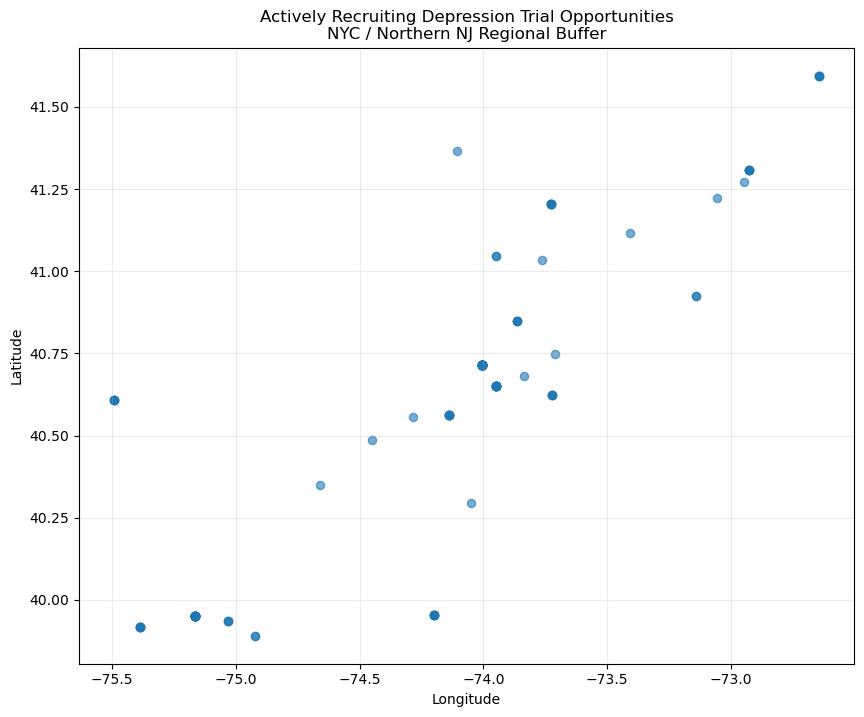

In [55]:
# ============================================================
# FIRST MAP-LIKE PLOT OF CONFIRMED REGIONAL TRIAL SITES
# ============================================================

plt.figure(figsize=(10, 8))

plt.scatter(
    final_regional_sites_df["longitude"],
    final_regional_sites_df["latitude"],
    alpha=0.6,
    s=35
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Actively Recruiting Depression Trial Opportunities\n"
    "NYC / Northern NJ Regional Buffer"
)

plt.grid(alpha=0.25)

plt.show()

GEOGRAPHIC LOCATION SUMMARY
---------------------------
Unique coordinate locations: 27
Total unique trials represented: 63

TOP LOCATIONS BY NUMBER OF RECRUITING TRIALS
         city        state  unique_trials  unique_facility_names
     New York     New York             40                     29
 Philadelphia Pennsylvania             18                     12
     Brooklyn     New York              9                      7
Staten Island     New York              7                      6
   Toms River   New Jersey              6                      2
  Mount Kisco     New York              6                      4
        Media Pennsylvania              6                      5
    New Haven  Connecticut              5                      5
    Allentown Pennsylvania              5                      5
     Cromwell  Connecticut              4                      4
    The Bronx     New York              4                      4
   Cedarhurst     New York              4         

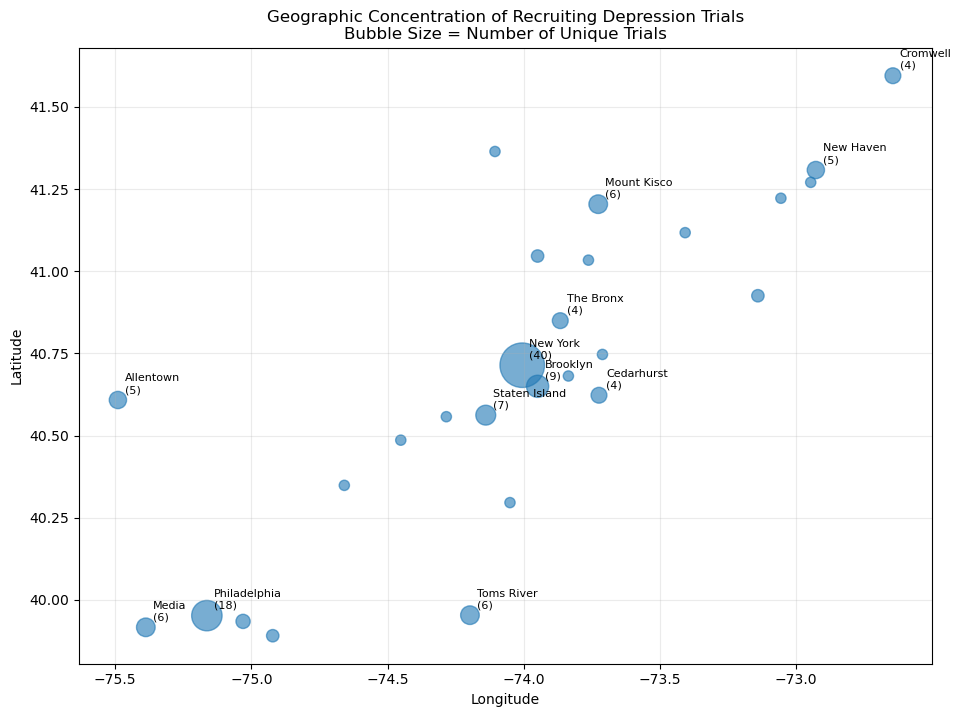

In [56]:
# ============================================================
# COLLAPSE TRIAL-SITE ROWS INTO GEOGRAPHIC LOCATIONS
# Point size = number of unique recruiting depression trials
# ============================================================

location_summary_df = (
    final_regional_sites_df
    .groupby(
        [
            "latitude",
            "longitude",
            "city",
            "state"
        ],
        dropna=False
    )
    .agg(
        unique_trials=(
            "nct_id",
            "nunique"
        ),

        trial_site_rows=(
            "nct_id",
            "size"
        ),

        unique_facility_names=(
            "facility",
            "nunique"
        ),

        facilities=(
            "facility",
            lambda x: " | ".join(
                sorted(
                    set(
                        str(v)
                        for v in x
                        if pd.notna(v)
                    )
                )
            )
        )
    )
    .reset_index()
)


print("GEOGRAPHIC LOCATION SUMMARY")
print("---------------------------")

print(
    "Unique coordinate locations:",
    len(location_summary_df)
)

print(
    "Total unique trials represented:",
    final_regional_sites_df["nct_id"].nunique()
)

print()

print("TOP LOCATIONS BY NUMBER OF RECRUITING TRIALS")

print(
    location_summary_df[
        [
            "city",
            "state",
            "unique_trials",
            "unique_facility_names"
        ]
    ]
    .sort_values(
        "unique_trials",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(11, 8))


plt.scatter(
    location_summary_df["longitude"],
    location_summary_df["latitude"],

    # Bigger bubble = more unique trials
    s=(
        30
        +
        location_summary_df["unique_trials"] * 25
    ),

    alpha=0.6
)


plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Geographic Concentration of Recruiting Depression Trials\n"
    "Bubble Size = Number of Unique Trials"
)

plt.grid(alpha=0.25)


# ------------------------------------------------------------
# Label the 12 largest trial clusters
# ------------------------------------------------------------

top_locations = (
    location_summary_df
    .sort_values(
        "unique_trials",
        ascending=False
    )
    .head(12)
)


for _, row in top_locations.iterrows():

    plt.annotate(
        f'{row["city"]}\n({row["unique_trials"]})',

        (
            row["longitude"],
            row["latitude"]
        ),

        xytext=(5, 5),

        textcoords="offset points",

        fontsize=8
    )


plt.show()

In [57]:
# ============================================================
# SAVE STEP 2 FINAL DATASETS
# Clinical Trial Access Desert Index
# ============================================================

from datetime import datetime

save_date = datetime.now().strftime("%Y-%m-%d")


# ------------------------------------------------------------
# 1. MASTER STUDY SCREENING DATASET
# One row = one study
# ------------------------------------------------------------

screening_df.to_csv(
    f"ctadi_study_screening_{save_date}.csv",
    index=False
)


# ------------------------------------------------------------
# 2. ALL RECRUITING U.S. SITE RECORDS
# One row = one study × recruiting site
# ------------------------------------------------------------

sites_df.to_csv(
    f"ctadi_all_us_recruiting_sites_{save_date}.csv",
    index=False
)


# ------------------------------------------------------------
# 3. CONFIRMED PRIMARY REGIONAL NETWORK
# Broad NYC/NJ access buffer
# ------------------------------------------------------------

final_regional_sites_df.to_csv(
    f"ctadi_primary_regional_sites_{save_date}.csv",
    index=False
)


# ------------------------------------------------------------
# 4. COORDINATE-LEVEL SUMMARY
# ------------------------------------------------------------

location_summary_df.to_csv(
    f"ctadi_regional_location_summary_{save_date}.csv",
    index=False
)


print("STEP 2 FILES SAVED")
print("------------------")

print(
    f"ctadi_study_screening_{save_date}.csv"
)

print(
    f"ctadi_all_us_recruiting_sites_{save_date}.csv"
)

print(
    f"ctadi_primary_regional_sites_{save_date}.csv"
)

print(
    f"ctadi_regional_location_summary_{save_date}.csv"
)

print()

print("FINAL STEP 2 CHECKPOINT")
print("-----------------------")

print(
    "Confirmed regional trials:",
    final_regional_sites_df["nct_id"].nunique()
)

print(
    "Recruiting trial-site rows:",
    len(final_regional_sites_df)
)

print(
    "Reported facility names:",
    final_regional_sites_df["facility"].nunique()
)

print(
    "ClinicalTrials.gov coordinate pairs:",
    len(location_summary_df)
)

STEP 2 FILES SAVED
------------------
ctadi_study_screening_2026-08-31.csv
ctadi_all_us_recruiting_sites_2026-08-31.csv
ctadi_primary_regional_sites_2026-08-31.csv
ctadi_regional_location_summary_2026-08-31.csv

FINAL STEP 2 CHECKPOINT
-----------------------
Confirmed regional trials: 63
Recruiting trial-site rows: 151
Reported facility names: 79
ClinicalTrials.gov coordinate pairs: 27


In [58]:
# ============================================================
# STEP 3A
# TEST CDC PLACES 2025 CENSUS-TRACT API
# Depression among adults
# ============================================================

PLACES_URL = (
    "https://data.cdc.gov/resource/"
    "cwsq-ngmh.json"
)

params = {

    "$select": (
        "year,"
        "stateabbr,"
        "countyfips,"
        "locationname,"
        "locationid,"
        "measure,"
        "measureid,"
        "data_value_type,"
        "data_value,"
        "low_confidence_limit,"
        "high_confidence_limit,"
        "totalpop18plus,"
        "geolocation"
    ),

    "$where": (
        "stateabbr in ('NY','NJ') "
        "AND measure = 'Depression among adults'"
    ),

    "$limit": 10
}


response = requests.get(
    PLACES_URL,
    params=params,
    timeout=60
)

print("Status code:", response.status_code)

response.raise_for_status()

places_test_df = pd.DataFrame(
    response.json()
)


print()
print(
    "Rows returned:",
    len(places_test_df)
)

print()

print(
    places_test_df.to_string(
        index=False
    )
)

Status code: 200

Rows returned: 10

year stateabbr countyfips locationname  locationid                 measure  measureid  data_value_type data_value low_confidence_limit high_confidence_limit totalpop18plus                                                 geolocation
2023        NJ      34001  34001010101 34001010101 Depression among adults DEPRESSION Crude prevalence       16.3                 13.8                  19.0           2560 {'type': 'Point', 'coordinates': [-74.3669024, 39.4225085]}
2023        NJ      34001  34001011202 34001011202 Depression among adults DEPRESSION Crude prevalence       17.6                 15.0                  20.3           5730 {'type': 'Point', 'coordinates': [-74.8800477, 39.5130629]}
2023        NJ      34005  34005701700 34005701700 Depression among adults DEPRESSION Crude prevalence       17.0                 14.7                  19.7           3312  {'type': 'Point', 'coordinates': [-74.707679, 40.1496935]}
2023        NJ      34023  34023001

In [59]:
# ============================================================
# STEP 3B
# DOWNLOAD CDC PLACES DEPRESSION DATA
# FOR THE 10-COUNTY NYC / NORTHERN NJ STUDY REGION
# ============================================================

study_counties = {

    # New York City
    "36005": "Bronx County, NY",
    "36047": "Kings County, NY",
    "36061": "New York County, NY",
    "36081": "Queens County, NY",
    "36085": "Richmond County, NY",

    # Northern New Jersey
    "34003": "Bergen County, NJ",
    "34013": "Essex County, NJ",
    "34017": "Hudson County, NJ",
    "34031": "Passaic County, NJ",
    "34039": "Union County, NJ"
}


county_fips_string = ",".join(
    f"'{fips}'"
    for fips in study_counties.keys()
)


params = {

    "$select": (
        "year,"
        "stateabbr,"
        "countyfips,"
        "locationname,"
        "locationid,"
        "measure,"
        "measureid,"
        "data_value_type,"
        "data_value,"
        "low_confidence_limit,"
        "high_confidence_limit,"
        "totalpop18plus,"
        "geolocation"
    ),

    "$where": (
        f"countyfips in ({county_fips_string}) "
        "AND measureid = 'DEPRESSION' "
        "AND data_value_type = 'Crude prevalence'"
    ),

    "$limit": 5000
}


response = requests.get(
    PLACES_URL,
    params=params,
    timeout=60
)

response.raise_for_status()


places_depression_df = pd.DataFrame(
    response.json()
)


# ------------------------------------------------------------
# Convert numeric variables
# ------------------------------------------------------------

numeric_columns = [
    "data_value",
    "low_confidence_limit",
    "high_confidence_limit",
    "totalpop18plus"
]

for col in numeric_columns:

    places_depression_df[col] = pd.to_numeric(
        places_depression_df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Add readable county name
# ------------------------------------------------------------

places_depression_df["study_county"] = (
    places_depression_df["countyfips"]
    .map(study_counties)
)


# ------------------------------------------------------------
# Extract tract centroid coordinates
# ------------------------------------------------------------

def get_longitude(geo):

    if isinstance(geo, dict):
        coords = geo.get("coordinates", [])

        if len(coords) >= 2:
            return coords[0]

    return None


def get_latitude(geo):

    if isinstance(geo, dict):
        coords = geo.get("coordinates", [])

        if len(coords) >= 2:
            return coords[1]

    return None


places_depression_df["longitude"] = (
    places_depression_df["geolocation"]
    .apply(get_longitude)
)

places_depression_df["latitude"] = (
    places_depression_df["geolocation"]
    .apply(get_latitude)
)


# ------------------------------------------------------------
# Estimated number of adults with lifetime diagnosed depression
#
# This is a modeled burden estimate:
# adult population × modeled crude prevalence
# ------------------------------------------------------------

places_depression_df[
    "estimated_adults_with_depression"
] = (
    places_depression_df["totalpop18plus"]
    *
    places_depression_df["data_value"]
    / 100
)


# ------------------------------------------------------------
# QUALITY CHECK
# ------------------------------------------------------------

print("CDC PLACES DEPRESSION DATA")
print("--------------------------")

print(
    "Rows:",
    len(places_depression_df)
)

print(
    "Unique census tracts:",
    places_depression_df[
        "locationid"
    ].nunique()
)

print(
    "Counties represented:",
    places_depression_df[
        "countyfips"
    ].nunique()
)

print()

print("TRACTS BY COUNTY")

print(
    places_depression_df[
        "study_county"
    ].value_counts()
)

print()

print(
    "Missing depression prevalence:",
    places_depression_df[
        "data_value"
    ].isna().sum()
)

print(
    "Missing adult population:",
    places_depression_df[
        "totalpop18plus"
    ].isna().sum()
)

print(
    "Missing coordinates:",
    places_depression_df[
        "latitude"
    ].isna().sum()
)

print()

print(
    "Lowest tract prevalence:",
    places_depression_df[
        "data_value"
    ].min()
)

print(
    "Highest tract prevalence:",
    places_depression_df[
        "data_value"
    ].max()
)

print(
    "Median tract prevalence:",
    places_depression_df[
        "data_value"
    ].median()
)

CDC PLACES DEPRESSION DATA
--------------------------
Rows: 3065
Unique census tracts: 3065
Counties represented: 10

TRACTS BY COUNTY
study_county
Kings County, NY       776
Queens County, NY      684
Bronx County, NY       347
New York County, NY    304
Essex County, NJ       210
Bergen County, NJ      203
Hudson County, NJ      182
Union County, NJ       120
Richmond County, NY    120
Passaic County, NJ     119
Name: count, dtype: int64

Missing depression prevalence: 0
Missing adult population: 0
Missing coordinates: 0

Lowest tract prevalence: 9.5
Highest tract prevalence: 27.4
Median tract prevalence: 15.7


In [60]:
# ============================================================
# STEP 3C
# COUNTY-LEVEL DEPRESSION BURDEN SUMMARY
# Population-weighted using adult population
# ============================================================

county_depression_summary = (
    places_depression_df
    .groupby(
        [
            "countyfips",
            "study_county"
        ],
        as_index=False
    )
    .agg(
        census_tracts=(
            "locationid",
            "nunique"
        ),

        adult_population=(
            "totalpop18plus",
            "sum"
        ),

        estimated_adults_with_depression=(
            "estimated_adults_with_depression",
            "sum"
        ),

        median_tract_prevalence=(
            "data_value",
            "median"
        ),

        minimum_tract_prevalence=(
            "data_value",
            "min"
        ),

        maximum_tract_prevalence=(
            "data_value",
            "max"
        )
    )
)


# ------------------------------------------------------------
# Population-weighted county prevalence
# ------------------------------------------------------------

county_depression_summary[
    "weighted_depression_prevalence"
] = (
    county_depression_summary[
        "estimated_adults_with_depression"
    ]
    /
    county_depression_summary[
        "adult_population"
    ]
    * 100
)


# ------------------------------------------------------------
# Round for readable output
# ------------------------------------------------------------

county_depression_summary[
    "weighted_depression_prevalence"
] = (
    county_depression_summary[
        "weighted_depression_prevalence"
    ].round(1)
)

county_depression_summary[
    "estimated_adults_with_depression"
] = (
    county_depression_summary[
        "estimated_adults_with_depression"
    ].round()
    .astype(int)
)


# ------------------------------------------------------------
# Rank counties
# ------------------------------------------------------------

county_depression_summary = (
    county_depression_summary
    .sort_values(
        "weighted_depression_prevalence",
        ascending=False
    )
    .reset_index(drop=True)
)


county_depression_summary[
    "prevalence_rank"
] = (
    county_depression_summary.index + 1
)


print("COUNTY-LEVEL MODELED DEPRESSION BURDEN")
print("--------------------------------------")

print(
    county_depression_summary[
        [
            "prevalence_rank",
            "study_county",
            "census_tracts",
            "adult_population",
            "estimated_adults_with_depression",
            "weighted_depression_prevalence",
            "median_tract_prevalence",
            "maximum_tract_prevalence"
        ]
    ].to_string(index=False)
)

COUNTY-LEVEL MODELED DEPRESSION BURDEN
--------------------------------------
 prevalence_rank        study_county  census_tracts  adult_population  estimated_adults_with_depression  weighted_depression_prevalence  median_tract_prevalence  maximum_tract_prevalence
               1 New York County, NY            304           1461712                            277673                            19.0                    18.80                      25.1
               2    Kings County, NY            776           2140225                            355666                            16.6                    16.50                      25.8
               3    Bronx County, NY            347           1122959                            183611                            16.4                    16.50                      27.4
               4    Essex County, NJ            210            661503                            105267                            15.9                    15.95              

In [61]:
# ============================================================
# STEP 3D
# IDENTIFY HIGHEST-NEED CENSUS TRACTS
#
# View need in TWO ways:
# 1. Highest modeled depression prevalence
# 2. Largest estimated number of adults with depression
# ============================================================


# ------------------------------------------------------------
# Add regional percentile ranks
# ------------------------------------------------------------

places_depression_df[
    "prevalence_percentile"
] = (
    places_depression_df[
        "data_value"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


places_depression_df[
    "case_burden_percentile"
] = (
    places_depression_df[
        "estimated_adults_with_depression"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# Simple preliminary need score
#
# This is NOT our final Access Desert Index.
# For now, it gives equal weight to:
# - prevalence
# - estimated number of affected adults
# ------------------------------------------------------------

places_depression_df[
    "preliminary_need_score"
] = (
    places_depression_df[
        "prevalence_percentile"
    ]
    +
    places_depression_df[
        "case_burden_percentile"
    ]
) / 2


# ------------------------------------------------------------
# TOP 20 BY PREVALENCE
# ------------------------------------------------------------

top_prevalence_tracts = (
    places_depression_df
    .sort_values(
        "data_value",
        ascending=False
    )
    .head(20)
)


print("TOP 20 TRACTS BY MODELED DEPRESSION PREVALENCE")
print("------------------------------------------------")

print(
    top_prevalence_tracts[
        [
            "locationid",
            "study_county",
            "data_value",
            "totalpop18plus",
            "estimated_adults_with_depression",
            "latitude",
            "longitude"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# TOP 20 BY ESTIMATED NUMBER OF ADULTS WITH DEPRESSION
# ------------------------------------------------------------

top_case_burden_tracts = (
    places_depression_df
    .sort_values(
        "estimated_adults_with_depression",
        ascending=False
    )
    .head(20)
)


print()
print()
print("TOP 20 TRACTS BY ESTIMATED ADULT DEPRESSION BURDEN")
print("----------------------------------------------------")

print(
    top_case_burden_tracts[
        [
            "locationid",
            "study_county",
            "data_value",
            "totalpop18plus",
            "estimated_adults_with_depression",
            "latitude",
            "longitude"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# TOP 20 BY PRELIMINARY NEED SCORE
# ------------------------------------------------------------

top_need_tracts = (
    places_depression_df
    .sort_values(
        "preliminary_need_score",
        ascending=False
    )
    .head(20)
)


print()
print()
print("TOP 20 TRACTS BY PRELIMINARY NEED SCORE")
print("---------------------------------------")

print(
    top_need_tracts[
        [
            "locationid",
            "study_county",
            "data_value",
            "estimated_adults_with_depression",
            "prevalence_percentile",
            "case_burden_percentile",
            "preliminary_need_score"
        ]
    ]
    .round(1)
    .to_string(index=False)
)

TOP 20 TRACTS BY MODELED DEPRESSION PREVALENCE
------------------------------------------------
 locationid        study_county  data_value  totalpop18plus  estimated_adults_with_depression  latitude  longitude
36005031900    Bronx County, NY        27.4             441                           120.834 40.913873 -73.911107
36047050900    Kings County, NY        25.8            2466                           636.228 40.703277 -73.950565
36047053500    Kings County, NY        25.7            2566                           659.462 40.706144 -73.961220
36047053102    Kings County, NY        25.5            2462                           627.810 40.700235 -73.953302
36047052900    Kings County, NY        25.5            2432                           620.160 40.705872 -73.954506
36047123700    Kings County, NY        25.3            3724                           942.172 40.696738 -73.956740
36005039700    Bronx County, NY        25.3            4218                          1067.154 40.86

In [62]:
# ============================================================
# STEP 3E
# DEFINE HIGH-NEED TRACTS
# Top 20% and Top 10% of preliminary depression need
# ============================================================

# ------------------------------------------------------------
# Calculate regional thresholds
# ------------------------------------------------------------

need_80_threshold = (
    places_depression_df[
        "preliminary_need_score"
    ].quantile(0.80)
)

need_90_threshold = (
    places_depression_df[
        "preliminary_need_score"
    ].quantile(0.90)
)


print("HIGH-NEED THRESHOLDS")
print("--------------------")

print(
    "Top 20% threshold:",
    round(need_80_threshold, 1)
)

print(
    "Top 10% threshold:",
    round(need_90_threshold, 1)
)

print()


# ------------------------------------------------------------
# Create high-need flags
# ------------------------------------------------------------

places_depression_df[
    "high_need_top20"
] = (
    places_depression_df[
        "preliminary_need_score"
    ]
    >= need_80_threshold
)

places_depression_df[
    "high_need_top10"
] = (
    places_depression_df[
        "preliminary_need_score"
    ]
    >= need_90_threshold
)


print(
    "Top-20% high-need tracts:",
    places_depression_df[
        "high_need_top20"
    ].sum()
)

print(
    "Top-10% high-need tracts:",
    places_depression_df[
        "high_need_top10"
    ].sum()
)

print()


# ============================================================
# COUNTY DISTRIBUTION OF HIGH-NEED TRACTS
# ============================================================

high_need_county_summary = (
    places_depression_df
    .groupby(
        [
            "countyfips",
            "study_county"
        ]
    )
    .agg(
        total_tracts=(
            "locationid",
            "nunique"
        ),

        top20_high_need_tracts=(
            "high_need_top20",
            "sum"
        ),

        top10_high_need_tracts=(
            "high_need_top10",
            "sum"
        ),

        adult_population=(
            "totalpop18plus",
            "sum"
        ),

        estimated_adults_with_depression=(
            "estimated_adults_with_depression",
            "sum"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# Percent of county tracts classified as high need
# ------------------------------------------------------------

high_need_county_summary[
    "pct_tracts_top20"
] = (
    high_need_county_summary[
        "top20_high_need_tracts"
    ]
    /
    high_need_county_summary[
        "total_tracts"
    ]
    * 100
)


high_need_county_summary[
    "pct_tracts_top10"
] = (
    high_need_county_summary[
        "top10_high_need_tracts"
    ]
    /
    high_need_county_summary[
        "total_tracts"
    ]
    * 100
)


high_need_county_summary = (
    high_need_county_summary
    .sort_values(
        "pct_tracts_top10",
        ascending=False
    )
)


print("HIGH-NEED TRACTS BY COUNTY")
print("--------------------------")

print(
    high_need_county_summary[
        [
            "study_county",
            "total_tracts",
            "top20_high_need_tracts",
            "pct_tracts_top20",
            "top10_high_need_tracts",
            "pct_tracts_top10"
        ]
    ]
    .round(1)
    .to_string(index=False)
)

HIGH-NEED THRESHOLDS
--------------------
Top 20% threshold: 72.1
Top 10% threshold: 83.4

Top-20% high-need tracts: 613
Top-10% high-need tracts: 307

HIGH-NEED TRACTS BY COUNTY
--------------------------
       study_county  total_tracts  top20_high_need_tracts  pct_tracts_top20  top10_high_need_tracts  pct_tracts_top10
New York County, NY           304                     238              78.3                     198              65.1
   Kings County, NY           776                     160              20.6                      60               7.7
   Bronx County, NY           347                      94              27.1                      26               7.5
   Essex County, NJ           210                      29              13.8                       7               3.3
 Passaic County, NJ           119                      13              10.9                       2               1.7
  Queens County, NY           684                      39               5.7           

In [64]:
# ============================================================
# STEP 4A WORKAROUND
# Create direct browser links to the 2024 ACS 5-Year API
#
# This bypasses the Pyodide/browser request restriction.
# ============================================================

from urllib.parse import urlencode
from IPython.display import display, HTML


ACS_URL = "https://api.census.gov/data/2024/acs/acs5"


# ------------------------------------------------------------
# Variables
# ------------------------------------------------------------

acs_variables = ",".join([

    "NAME",

    # Poverty
    "B17001_001E",   # poverty universe
    "B17001_002E",   # below poverty

    # Vehicle access
    "B08201_001E",   # total households
    "B08201_002E",   # no vehicle available

    # Median household income
    "B19013_001E",

    # Internet access
    "B28002_001E",   # total households
    "B28002_013E",   # no internet access

    # Health insurance
    "B27010_001E",   # total population
    "B27010_017E",   # uninsured under 19
    "B27010_033E",   # uninsured age 19-34
    "B27010_050E",   # uninsured age 35-64
    "B27010_066E"    # uninsured age 65+
])


def make_census_link(state_fips, label):

    params = {
        "get": acs_variables,
        "for": "tract:*",
        "in": f"state:{state_fips}",
        "key": CENSUS_API_KEY
    }

    url = (
        ACS_URL
        + "?"
        + urlencode(params)
    )

    display(
        HTML(
            f'<a href="{url}" target="_blank" '
            f'style="font-size:18px;font-weight:bold;">'
            f'{label}</a>'
        )
    )


print("Click each link below:")
print()

make_census_link(
    "36",
    "OPEN NEW YORK ACS DATA"
)

print()

make_census_link(
    "34",
    "OPEN NEW JERSEY ACS DATA"
)

Click each link below:



In [2]:
import requests

print("requests works!")

requests works!


In [4]:
# ============================================================
# STEP 4A
# TEST ACS DATA THROUGH CENSUS REPORTER
# Using its currently available 5-year ACS release
# ============================================================

import requests

CR_URL = (
    "https://api.censusreporter.org/"
    "1.0/data/show/latest"
)

params = {
    "table_ids": "B19013",
    "geo_ids": "140|05000US36061"
}

response = requests.get(
    CR_URL,
    params=params,
    timeout=60
)

print("Status code:", response.status_code)

response.raise_for_status()

cr_test = response.json()

print()
print("ACS release:")
print(cr_test["release"]["name"])

print()

print(
    "Manhattan census tracts returned:",
    len(cr_test["data"])
)

print()

first_geoid = next(iter(cr_test["data"]))

print("Example GEOID:", first_geoid)

print(
    "Geography:",
    cr_test["geography"][first_geoid]["name"]
)

print(
    "Median household income:",
    cr_test["data"][first_geoid]
    ["B19013"]["estimate"]["B19013001"]
)

Status code: 200

ACS release:
ACS 2024 5-year

Manhattan census tracts returned: 310

Example GEOID: 14000US36061000100
Geography: Census Tract 1, New York, NY
Median household income: None


In [5]:
# ============================================================
# STEP 4B
# PULL ACS 2024 5-YEAR SOCIOECONOMIC DATA
# THROUGH CENSUS REPORTER
#
# 10 study counties
# 5 socioeconomic / access domains
# ============================================================

import requests
import pandas as pd
import time


# ------------------------------------------------------------
# Census Reporter endpoint
# ------------------------------------------------------------

CR_URL = (
    "https://api.censusreporter.org/"
    "1.0/data/show/latest"
)


# ------------------------------------------------------------
# ACS tables
#
# B17001 = Poverty status
# B08201 = Household vehicles available
# B19013 = Median household income
# B28002 = Internet access
# B27010 = Health insurance coverage
# ------------------------------------------------------------

ACS_TABLES = ",".join([
    "B17001",
    "B08201",
    "B19013",
    "B28002",
    "B27010"
])


# ------------------------------------------------------------
# Our 10 study counties
# ------------------------------------------------------------

study_counties = {

    # NYC
    "36005": "Bronx County, NY",
    "36047": "Kings County, NY",
    "36061": "New York County, NY",
    "36081": "Queens County, NY",
    "36085": "Richmond County, NY",

    # Northern NJ
    "34003": "Bergen County, NJ",
    "34013": "Essex County, NJ",
    "34017": "Hudson County, NJ",
    "34031": "Passaic County, NJ",
    "34039": "Union County, NJ"
}


# ------------------------------------------------------------
# Safe nested extraction
# ------------------------------------------------------------

def get_estimate(tract_data, table, variable):

    try:
        return (
            tract_data[table]
            ["estimate"]
            [variable]
        )

    except (
        KeyError,
        TypeError
    ):
        return None


# ------------------------------------------------------------
# Download one county at a time
# ------------------------------------------------------------

acs_rows = []


for county_fips, county_name in study_counties.items():

    print(
        "Downloading:",
        county_name
    )

    params = {

        "table_ids":
            ACS_TABLES,

        "geo_ids":
            f"140|05000US{county_fips}"
    }


    # --------------------------------------------------------
    # Simple retry system
    # --------------------------------------------------------

    success = False

    for attempt in range(1, 4):

        try:

            response = requests.get(
                CR_URL,
                params=params,
                timeout=60
            )

            response.raise_for_status()

            county_json = response.json()

            success = True

            break


        except Exception as e:

            print(
                f"  Attempt {attempt} failed:",
                e
            )

            time.sleep(2)


    if not success:

        print(
            "  FAILED:",
            county_name
        )

        continue


    # --------------------------------------------------------
    # Parse each census tract
    # --------------------------------------------------------

    for geoid, tract_data in county_json[
        "data"
    ].items():

        # Census Reporter:
        # 14000US36061000100
        #
        # PLACES:
        # 36061000100

        tract_fips = (
            geoid
            .replace(
                "14000US",
                ""
            )
        )


        # ----------------------------------------------------
        # Poverty
        # ----------------------------------------------------

        poverty_total = get_estimate(
            tract_data,
            "B17001",
            "B17001001"
        )

        poverty_below = get_estimate(
            tract_data,
            "B17001",
            "B17001002"
        )


        # ----------------------------------------------------
        # Vehicle access
        # ----------------------------------------------------

        vehicle_households = get_estimate(
            tract_data,
            "B08201",
            "B08201001"
        )

        no_vehicle_households = get_estimate(
            tract_data,
            "B08201",
            "B08201002"
        )


        # ----------------------------------------------------
        # Median household income
        # ----------------------------------------------------

        median_household_income = get_estimate(
            tract_data,
            "B19013",
            "B19013001"
        )


        # ----------------------------------------------------
        # Internet access
        # ----------------------------------------------------

        internet_households = get_estimate(
            tract_data,
            "B28002",
            "B28002001"
        )

        no_internet_households = get_estimate(
            tract_data,
            "B28002",
            "B28002013"
        )


        # ----------------------------------------------------
        # Health insurance
        #
        # B27010 total civilian
        # noninstitutionalized population
        # ----------------------------------------------------

        insurance_population = get_estimate(
            tract_data,
            "B27010",
            "B27010001"
        )


        uninsured_under19 = get_estimate(
            tract_data,
            "B27010",
            "B27010017"
        )

        uninsured_19_34 = get_estimate(
            tract_data,
            "B27010",
            "B27010033"
        )

        uninsured_35_64 = get_estimate(
            tract_data,
            "B27010",
            "B27010050"
        )

        uninsured_65plus = get_estimate(
            tract_data,
            "B27010",
            "B27010066"
        )


        # ----------------------------------------------------
        # Save row
        # ----------------------------------------------------

        acs_rows.append({

            "locationid":
                tract_fips,

            "countyfips":
                county_fips,

            "study_county":
                county_name,

            "poverty_total":
                poverty_total,

            "poverty_below":
                poverty_below,

            "vehicle_households":
                vehicle_households,

            "no_vehicle_households":
                no_vehicle_households,

            "median_household_income":
                median_household_income,

            "internet_households":
                internet_households,

            "no_internet_households":
                no_internet_households,

            "insurance_population":
                insurance_population,

            "uninsured_under19":
                uninsured_under19,

            "uninsured_19_34":
                uninsured_19_34,

            "uninsured_35_64":
                uninsured_35_64,

            "uninsured_65plus":
                uninsured_65plus
        })


    print(
        "  Tracts retrieved:",
        len(county_json["data"])
    )

    print()


# ------------------------------------------------------------
# Create ACS dataframe
# ------------------------------------------------------------

acs_df = pd.DataFrame(
    acs_rows
)


print()
print("ACS DOWNLOAD COMPLETE")
print("---------------------")

print(
    "Rows:",
    len(acs_df)
)

print(
    "Unique tracts:",
    acs_df["locationid"].nunique()
)

print(
    "Counties:",
    acs_df["countyfips"].nunique()
)

Downloading: Bronx County, NY
  Tracts retrieved: 361

Downloading: Kings County, NY
  Tracts retrieved: 805

Downloading: New York County, NY
  Tracts retrieved: 310

Downloading: Queens County, NY
  Tracts retrieved: 725

Downloading: Richmond County, NY
  Tracts retrieved: 126

Downloading: Bergen County, NJ
  Tracts retrieved: 203

Downloading: Essex County, NJ
  Tracts retrieved: 211

Downloading: Hudson County, NJ
  Tracts retrieved: 183

Downloading: Passaic County, NJ
  Tracts retrieved: 120

Downloading: Union County, NJ
  Tracts retrieved: 120


ACS DOWNLOAD COMPLETE
---------------------
Rows: 3164
Unique tracts: 3164
Counties: 10


In [6]:
# ============================================================
# STEP 4C
# CALCULATE ACS SOCIOECONOMIC / ACCESS INDICATORS
# ============================================================

# ------------------------------------------------------------
# Convert all component variables to numeric
# ------------------------------------------------------------

numeric_cols = [

    "poverty_total",
    "poverty_below",

    "vehicle_households",
    "no_vehicle_households",

    "median_household_income",

    "internet_households",
    "no_internet_households",

    "insurance_population",

    "uninsured_under19",
    "uninsured_19_34",
    "uninsured_35_64",
    "uninsured_65plus"
]


for col in numeric_cols:

    acs_df[col] = pd.to_numeric(
        acs_df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Census can use negative sentinel values for unavailable
# estimates. Treat those as missing.
# ------------------------------------------------------------

acs_df.loc[
    acs_df["median_household_income"] < 0,
    "median_household_income"
] = pd.NA


# ------------------------------------------------------------
# 1. POVERTY %
# ------------------------------------------------------------

acs_df["poverty_pct"] = (
    acs_df["poverty_below"]
    /
    acs_df["poverty_total"].replace(0, pd.NA)
    * 100
)


# ------------------------------------------------------------
# 2. HOUSEHOLDS WITH NO VEHICLE %
# ------------------------------------------------------------

acs_df["no_vehicle_pct"] = (
    acs_df["no_vehicle_households"]
    /
    acs_df["vehicle_households"].replace(0, pd.NA)
    * 100
)


# ------------------------------------------------------------
# 3. HOUSEHOLDS WITH NO INTERNET ACCESS %
# ------------------------------------------------------------

acs_df["no_internet_pct"] = (
    acs_df["no_internet_households"]
    /
    acs_df["internet_households"].replace(0, pd.NA)
    * 100
)


# ------------------------------------------------------------
# 4. UNINSURED COUNT
#
# Sum uninsured estimates across:
# under 19
# 19–34
# 35–64
# 65+
# ------------------------------------------------------------

acs_df["uninsured_count"] = (
    acs_df[
        [
            "uninsured_under19",
            "uninsured_19_34",
            "uninsured_35_64",
            "uninsured_65plus"
        ]
    ]
    .sum(
        axis=1,
        min_count=1
    )
)


# ------------------------------------------------------------
# 5. UNINSURED %
# ------------------------------------------------------------

acs_df["uninsured_pct"] = (
    acs_df["uninsured_count"]
    /
    acs_df["insurance_population"].replace(0, pd.NA)
    * 100
)


# ------------------------------------------------------------
# Round percentages only for easier inspection
# Keep raw precision in the dataframe
# ------------------------------------------------------------

print("ACS VULNERABILITY INDICATORS")
print("----------------------------")

print(
    acs_df[
        [
            "poverty_pct",
            "no_vehicle_pct",
            "uninsured_pct",
            "no_internet_pct",
            "median_household_income"
        ]
    ]
    .describe()
    .round(1)
)

print()
print("MISSING VALUES IN ACS DATA")

print(
    acs_df[
        [
            "poverty_pct",
            "no_vehicle_pct",
            "uninsured_pct",
            "no_internet_pct",
            "median_household_income"
        ]
    ]
    .isna()
    .sum()
)

print()

print(
    "Tracts with all 5 indicators:",
    acs_df[
        [
            "poverty_pct",
            "no_vehicle_pct",
            "uninsured_pct",
            "no_internet_pct",
            "median_household_income"
        ]
    ]
    .notna()
    .all(axis=1)
    .sum()
)

ACS VULNERABILITY INDICATORS
----------------------------
       median_household_income
count                   3027.0
mean                   94657.7
std                    47399.2
min                    11094.0
25%                    62104.5
50%                    85129.0
75%                   115789.5
max                   250001.0

MISSING VALUES IN ACS DATA
poverty_pct                 89
no_vehicle_pct              99
uninsured_pct               88
no_internet_pct             99
median_household_income    137
dtype: int64

Tracts with all 5 indicators: 3027


In [7]:
# ============================================================
# STEP 4C.1
# FIX ACS INDICATOR DATA TYPES + FINAL VALIDATION
# ============================================================

import numpy as np


indicator_cols = [
    "poverty_pct",
    "no_vehicle_pct",
    "uninsured_pct",
    "no_internet_pct",
    "median_household_income"
]


# ------------------------------------------------------------
# Force all final indicators to true numeric dtype
# ------------------------------------------------------------

for col in indicator_cols:

    acs_df[col] = pd.to_numeric(
        acs_df[col],
        errors="coerce"
    ).astype(float)


# ------------------------------------------------------------
# Replace impossible infinite values
# ------------------------------------------------------------

acs_df[indicator_cols] = (
    acs_df[indicator_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ------------------------------------------------------------
# Sanity check percentages
# ------------------------------------------------------------

for col in [
    "poverty_pct",
    "no_vehicle_pct",
    "uninsured_pct",
    "no_internet_pct"
]:

    invalid = (
        (acs_df[col] < 0)
        |
        (acs_df[col] > 100)
    )

    print(
        f"{col} outside 0-100:",
        invalid.sum()
    )


print()
print("FINAL ACS INDICATOR DTYPES")
print("--------------------------")

print(
    acs_df[indicator_cols].dtypes
)


print()
print("FINAL ACS INDICATOR SUMMARY")
print("---------------------------")

print(
    acs_df[
        indicator_cols
    ]
    .describe()
    .round(1)
)


print()
print("MISSING VALUES")

print(
    acs_df[
        indicator_cols
    ]
    .isna()
    .sum()
)

poverty_pct outside 0-100: 0
no_vehicle_pct outside 0-100: 0
uninsured_pct outside 0-100: 0
no_internet_pct outside 0-100: 0

FINAL ACS INDICATOR DTYPES
--------------------------
poverty_pct                float64
no_vehicle_pct             float64
uninsured_pct              float64
no_internet_pct            float64
median_household_income    float64
dtype: object

FINAL ACS INDICATOR SUMMARY
---------------------------
       poverty_pct  no_vehicle_pct  uninsured_pct  no_internet_pct  \
count       3075.0          3065.0         3076.0           3065.0   
mean          16.1            40.6            7.5              7.0   
std           12.3            26.2            7.0              7.1   
min            0.0             0.0            0.0              0.0   
25%            7.0            17.0            2.9              2.5   
50%           13.0            39.1            5.6              5.4   
75%           21.8            63.1            9.6              9.5   
max          1

In [10]:
# ============================================================
# RECOVERY CELL
# REBUILD CDC PLACES DEPRESSION DATA FOR THE 10 STUDY COUNTIES
# ============================================================

import pandas as pd
import requests


# ------------------------------------------------------------
# 10 study counties
# ------------------------------------------------------------

study_counties = {

    # NYC
    "36005": "Bronx County, NY",
    "36047": "Kings County, NY",
    "36061": "New York County, NY",
    "36081": "Queens County, NY",
    "36085": "Richmond County, NY",

    # Northern NJ
    "34003": "Bergen County, NJ",
    "34013": "Essex County, NJ",
    "34017": "Hudson County, NJ",
    "34031": "Passaic County, NJ",
    "34039": "Union County, NJ"
}


PLACES_URL = (
    "https://data.cdc.gov/resource/"
    "cwsq-ngmh.json"
)


county_fips_string = ",".join(
    f"'{fips}'"
    for fips in study_counties.keys()
)


params = {

    "$select": (
        "year,"
        "stateabbr,"
        "countyfips,"
        "locationname,"
        "locationid,"
        "measure,"
        "measureid,"
        "data_value_type,"
        "data_value,"
        "low_confidence_limit,"
        "high_confidence_limit,"
        "totalpop18plus,"
        "geolocation"
    ),

    "$where": (
        f"countyfips in ({county_fips_string}) "
        "AND measureid = 'DEPRESSION' "
        "AND data_value_type = 'Crude prevalence'"
    ),

    "$limit": 5000
}


response = requests.get(
    PLACES_URL,
    params=params,
    timeout=60
)

print(
    "Status code:",
    response.status_code
)

response.raise_for_status()


places_depression_df = pd.DataFrame(
    response.json()
)


# ============================================================
# CLEAN VARIABLES
# ============================================================

numeric_columns = [
    "data_value",
    "low_confidence_limit",
    "high_confidence_limit",
    "totalpop18plus"
]


for col in numeric_columns:

    places_depression_df[col] = pd.to_numeric(
        places_depression_df[col],
        errors="coerce"
    )


places_depression_df["locationid"] = (
    places_depression_df["locationid"]
    .astype(str)
    .str.zfill(11)
)


places_depression_df["study_county"] = (
    places_depression_df["countyfips"]
    .map(study_counties)
)


# ============================================================
# EXTRACT TRACT CENTROID
# ============================================================

def get_longitude(geo):

    if isinstance(geo, dict):

        coords = geo.get(
            "coordinates", []
        )

        if len(coords) >= 2:
            return coords[0]

    return None


def get_latitude(geo):

    if isinstance(geo, dict):

        coords = geo.get(
            "coordinates", []
        )

        if len(coords) >= 2:
            return coords[1]

    return None


places_depression_df["longitude"] = (
    places_depression_df[
        "geolocation"
    ].apply(get_longitude)
)


places_depression_df["latitude"] = (
    places_depression_df[
        "geolocation"
    ].apply(get_latitude)
)


# ============================================================
# ESTIMATED DEPRESSION BURDEN
# ============================================================

places_depression_df[
    "estimated_adults_with_depression"
] = (
    places_depression_df[
        "totalpop18plus"
    ]
    *
    places_depression_df[
        "data_value"
    ]
    / 100
)


# ============================================================
# REBUILD PRELIMINARY NEED VARIABLES FROM STEP 3
# ============================================================

places_depression_df[
    "prevalence_percentile"
] = (
    places_depression_df[
        "data_value"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


places_depression_df[
    "case_burden_percentile"
] = (
    places_depression_df[
        "estimated_adults_with_depression"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


places_depression_df[
    "preliminary_need_score"
] = (
    places_depression_df[
        "prevalence_percentile"
    ]
    +
    places_depression_df[
        "case_burden_percentile"
    ]
) / 2


need_80_threshold = (
    places_depression_df[
        "preliminary_need_score"
    ].quantile(0.80)
)


need_90_threshold = (
    places_depression_df[
        "preliminary_need_score"
    ].quantile(0.90)
)


places_depression_df[
    "high_need_top20"
] = (
    places_depression_df[
        "preliminary_need_score"
    ]
    >= need_80_threshold
)


places_depression_df[
    "high_need_top10"
] = (
    places_depression_df[
        "preliminary_need_score"
    ]
    >= need_90_threshold
)


# ============================================================
# SAVE IMMEDIATELY
# ============================================================

places_depression_df.to_csv(
    "ctadi_places_depression_tracts.csv",
    index=False
)


# ============================================================
# QA
# ============================================================

print()
print("PLACES DATA RESTORED")
print("--------------------")

print(
    "Rows:",
    len(places_depression_df)
)

print(
    "Unique tracts:",
    places_depression_df[
        "locationid"
    ].nunique()
)

print(
    "Counties:",
    places_depression_df[
        "countyfips"
    ].nunique()
)

print(
    "Missing depression prevalence:",
    places_depression_df[
        "data_value"
    ].isna().sum()
)

print()
print(
    "Saved as:",
    "ctadi_places_depression_tracts.csv"
)

Status code: 200

PLACES DATA RESTORED
--------------------
Rows: 3065
Unique tracts: 3065
Counties: 10
Missing depression prevalence: 0

Saved as: ctadi_places_depression_tracts.csv


In [11]:
# ============================================================
# STEP 4D
# MERGE ACS VULNERABILITY DATA ONTO CDC PLACES
# AND SAVE EVERYTHING IMMEDIATELY
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Make sure ACS data are still in memory
# ------------------------------------------------------------

if "acs_df" not in globals():
    raise RuntimeError(
        "acs_df is no longer in memory. "
        "Stop here and tell ChatGPT before rerunning anything."
    )


# ------------------------------------------------------------
# Final ACS indicator names
# ------------------------------------------------------------

acs_indicator_cols = [
    "poverty_pct",
    "no_vehicle_pct",
    "uninsured_pct",
    "no_internet_pct",
    "median_household_income"
]


# ------------------------------------------------------------
# Standardize census tract FIPS
# ------------------------------------------------------------

places_depression_df["locationid"] = (
    places_depression_df["locationid"]
    .astype(str)
    .str.zfill(11)
)

acs_df["locationid"] = (
    acs_df["locationid"]
    .astype(str)
    .str.zfill(11)
)


# ------------------------------------------------------------
# Make sure final ACS indicators are numeric
# ------------------------------------------------------------

for col in acs_indicator_cols:

    acs_df[col] = pd.to_numeric(
        acs_df[col],
        errors="coerce"
    ).astype(float)


acs_df[acs_indicator_cols] = (
    acs_df[acs_indicator_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ------------------------------------------------------------
# Save full ACS dataset NOW
# ------------------------------------------------------------

acs_df.to_csv(
    "ctadi_acs_2024_tract_vulnerability.csv",
    index=False
)


# ------------------------------------------------------------
# Keep only variables needed for merge
# ------------------------------------------------------------

acs_merge_df = (
    acs_df[
        [
            "locationid",
            "poverty_pct",
            "no_vehicle_pct",
            "uninsured_pct",
            "no_internet_pct",
            "median_household_income"
        ]
    ]
    .drop_duplicates(
        subset="locationid"
    )
    .copy()
)


# ------------------------------------------------------------
# LEFT JOIN
#
# PLACES remains our analytic universe:
# exactly 3,065 census tracts.
# ------------------------------------------------------------

tract_analysis_df = (
    places_depression_df
    .merge(
        acs_merge_df,
        on="locationid",
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# ACS completeness flags
# ------------------------------------------------------------

tract_analysis_df["acs_complete"] = (
    tract_analysis_df[
        acs_indicator_cols
    ]
    .notna()
    .all(axis=1)
)


tract_analysis_df["acs_all_missing"] = (
    tract_analysis_df[
        acs_indicator_cols
    ]
    .isna()
    .all(axis=1)
)


# ============================================================
# QUALITY CHECK
# ============================================================

print("MERGED TRACT ANALYSIS DATASET")
print("-----------------------------")

print(
    "Rows:",
    len(tract_analysis_df)
)

print(
    "Unique tracts:",
    tract_analysis_df[
        "locationid"
    ].nunique()
)

print(
    "Counties represented:",
    tract_analysis_df[
        "countyfips"
    ].nunique()
)


print()
print("MISSING ACS VALUES AFTER MERGE")
print("------------------------------")

print(
    tract_analysis_df[
        acs_indicator_cols
    ]
    .isna()
    .sum()
)


print()

print(
    "Tracts with all 5 ACS indicators:",
    tract_analysis_df[
        "acs_complete"
    ].sum()
)

print(
    "Tracts missing at least 1 ACS indicator:",
    (
        ~tract_analysis_df[
            "acs_complete"
        ]
    ).sum()
)

print(
    "PLACES tracts with NO ACS match at all:",
    tract_analysis_df[
        "acs_all_missing"
    ].sum()
)


# ============================================================
# COVERAGE BY COUNTY
# ============================================================

coverage_by_county = (
    tract_analysis_df
    .groupby(
        "study_county"
    )
    .agg(

        total_tracts=(
            "locationid",
            "size"
        ),

        complete_acs_tracts=(
            "acs_complete",
            "sum"
        )
    )
)


coverage_by_county[
    "pct_complete"
] = (
    coverage_by_county[
        "complete_acs_tracts"
    ]
    /
    coverage_by_county[
        "total_tracts"
    ]
    * 100
)


print()
print("ACS-COMPLETE TRACTS BY COUNTY")
print("-----------------------------")

print(
    coverage_by_county
    .sort_values(
        "pct_complete",
        ascending=False
    )
    .round(1)
)


# ============================================================
# SAVE MERGED ANALYTIC DATASET
# ============================================================

tract_analysis_df.to_csv(
    "ctadi_tract_analysis_depression_acs.csv",
    index=False
)


print()
print("FILES SAVED")
print("-----------")

print(
    "ctadi_acs_2024_tract_vulnerability.csv"
)

print(
    "ctadi_tract_analysis_depression_acs.csv"
)

MERGED TRACT ANALYSIS DATASET
-----------------------------
Rows: 3065
Unique tracts: 3065
Counties represented: 10

MISSING ACS VALUES AFTER MERGE
------------------------------
poverty_pct                 5
no_vehicle_pct             12
uninsured_pct               4
no_internet_pct            12
median_household_income    40
dtype: int64

Tracts with all 5 ACS indicators: 3025
Tracts missing at least 1 ACS indicator: 40
PLACES tracts with NO ACS match at all: 4

ACS-COMPLETE TRACTS BY COUNTY
-----------------------------
                     total_tracts  complete_acs_tracts  pct_complete
study_county                                                        
Bergen County, NJ             203                  203         100.0
Passaic County, NJ            119                  119         100.0
Union County, NJ              120                  119          99.2
Essex County, NJ              210                  208          99.0
Kings County, NY              776                  768   

In [12]:
# ============================================================
# STEP 4E
# INVESTIGATE THE 40 TRACTS WITH INCOMPLETE ACS DATA
# ============================================================

incomplete_acs_df = (
    tract_analysis_df[
        ~tract_analysis_df["acs_complete"]
    ]
    .copy()
)


print("INCOMPLETE ACS TRACTS")
print("---------------------")

print(
    "Number of incomplete tracts:",
    len(incomplete_acs_df)
)

print(
    "Percent of all study tracts:",
    round(
        len(incomplete_acs_df)
        /
        len(tract_analysis_df)
        * 100,
        2
    )
)

print()


# ------------------------------------------------------------
# How much population do these tracts represent?
# ------------------------------------------------------------

print("ADULT POPULATION IN INCOMPLETE TRACTS")
print("-------------------------------------")

print(
    incomplete_acs_df[
        "totalpop18plus"
    ]
    .describe()
    .round(1)
)

print()

print(
    "Total adults in incomplete tracts:",
    int(
        incomplete_acs_df[
            "totalpop18plus"
        ].sum()
    )
)

print(
    "Percent of regional adult population:",
    round(
        incomplete_acs_df[
            "totalpop18plus"
        ].sum()
        /
        tract_analysis_df[
            "totalpop18plus"
        ].sum()
        * 100,
        2
    )
)


# ------------------------------------------------------------
# Missingness by county
# ------------------------------------------------------------

print()
print("INCOMPLETE TRACTS BY COUNTY")
print("---------------------------")

print(
    incomplete_acs_df[
        "study_county"
    ]
    .value_counts()
)


# ------------------------------------------------------------
# Show the 4 tracts with NO ACS match
# ------------------------------------------------------------

print()
print("TRACTS WITH NO ACS MATCH")
print("------------------------")

no_match_df = (
    tract_analysis_df[
        tract_analysis_df[
            "acs_all_missing"
        ]
    ]
    [
        [
            "locationid",
            "study_county",
            "locationname",
            "totalpop18plus",
            "data_value",
            "latitude",
            "longitude"
        ]
    ]
)

print(
    no_match_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Show which indicators are missing in the remaining tracts
# ------------------------------------------------------------

print()
print("MISSING-PATTERN SUMMARY")
print("-----------------------")

missing_pattern_df = (
    incomplete_acs_df[
        [
            "poverty_pct",
            "no_vehicle_pct",
            "uninsured_pct",
            "no_internet_pct",
            "median_household_income"
        ]
    ]
    .isna()
    .astype(int)
)

print(
    missing_pattern_df
    .value_counts()
    .to_string()
)

INCOMPLETE ACS TRACTS
---------------------
Number of incomplete tracts: 40
Percent of all study tracts: 1.31

ADULT POPULATION IN INCOMPLETE TRACTS
-------------------------------------
count      40.0
mean     1395.9
std      1395.7
min        51.0
25%       261.2
50%      1052.0
75%      2413.5
max      5756.0
Name: totalpop18plus, dtype: float64

Total adults in incomplete tracts: 55836
Percent of regional adult population: 0.56

INCOMPLETE TRACTS BY COUNTY
---------------------------
study_county
Queens County, NY      10
Bronx County, NY        8
Kings County, NY        8
New York County, NY     6
Hudson County, NJ       3
Essex County, NJ        2
Richmond County, NY     2
Union County, NJ        1
Name: count, dtype: int64

TRACTS WITH NO ACS MATCH
------------------------
 locationid        study_county locationname  totalpop18plus  data_value  latitude  longitude
36005000100    Bronx County, NY  36005000100            3760        14.8 40.792936 -73.881207
36005043503    Bronx

In [13]:
# ============================================================
# STEP 4F
# CREATE SOCIOECONOMIC VULNERABILITY SCORE
#
# Primary analysis:
# Complete-case ACS tracts only
#
# Score range:
# 0   = least vulnerable
# 100 = most vulnerable
# ============================================================


# ------------------------------------------------------------
# Start all vulnerability components as missing
# ------------------------------------------------------------

vulnerability_components = [

    "poverty_vuln_percentile",
    "no_vehicle_vuln_percentile",
    "uninsured_vuln_percentile",
    "no_internet_vuln_percentile",
    "low_income_vuln_percentile"
]


for col in vulnerability_components:

    tract_analysis_df[col] = float("nan")


# ------------------------------------------------------------
# Complete-case mask
# ------------------------------------------------------------

complete_mask = (
    tract_analysis_df["acs_complete"]
)


# ------------------------------------------------------------
# 1. POVERTY
# Higher poverty = higher vulnerability
# ------------------------------------------------------------

tract_analysis_df.loc[
    complete_mask,
    "poverty_vuln_percentile"
] = (
    tract_analysis_df.loc[
        complete_mask,
        "poverty_pct"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# 2. NO VEHICLE
# Higher % no vehicle = higher vulnerability
# ------------------------------------------------------------

tract_analysis_df.loc[
    complete_mask,
    "no_vehicle_vuln_percentile"
] = (
    tract_analysis_df.loc[
        complete_mask,
        "no_vehicle_pct"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# 3. UNINSURED
# Higher uninsured % = higher vulnerability
# ------------------------------------------------------------

tract_analysis_df.loc[
    complete_mask,
    "uninsured_vuln_percentile"
] = (
    tract_analysis_df.loc[
        complete_mask,
        "uninsured_pct"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# 4. NO INTERNET
# Higher % no internet = higher vulnerability
# ------------------------------------------------------------

tract_analysis_df.loc[
    complete_mask,
    "no_internet_vuln_percentile"
] = (
    tract_analysis_df.loc[
        complete_mask,
        "no_internet_pct"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# 5. LOW INCOME
#
# Lower household income = HIGHER vulnerability
#
# rank ascending=False:
# lowest income receives highest percentile rank
# ------------------------------------------------------------

tract_analysis_df.loc[
    complete_mask,
    "low_income_vuln_percentile"
] = (
    tract_analysis_df.loc[
        complete_mask,
        "median_household_income"
    ]
    .rank(
        pct=True,
        method="average",
        ascending=False
    )
    * 100
)


# ============================================================
# COMPOSITE VULNERABILITY SCORE
# Equal weight across all 5 domains
# ============================================================

tract_analysis_df[
    "socioeconomic_vulnerability_score"
] = (
    tract_analysis_df[
        vulnerability_components
    ]
    .mean(
        axis=1,
        skipna=False
    )
)


# ------------------------------------------------------------
# Regional percentile of composite score
# ------------------------------------------------------------

tract_analysis_df[
    "socioeconomic_vulnerability_percentile"
] = float("nan")


tract_analysis_df.loc[
    complete_mask,
    "socioeconomic_vulnerability_percentile"
] = (
    tract_analysis_df.loc[
        complete_mask,
        "socioeconomic_vulnerability_score"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# High-vulnerability flags
# ------------------------------------------------------------

vulnerability_80 = (
    tract_analysis_df.loc[
        complete_mask,
        "socioeconomic_vulnerability_score"
    ]
    .quantile(0.80)
)


vulnerability_90 = (
    tract_analysis_df.loc[
        complete_mask,
        "socioeconomic_vulnerability_score"
    ]
    .quantile(0.90)
)


tract_analysis_df[
    "high_vulnerability_top20"
] = (
    tract_analysis_df[
        "socioeconomic_vulnerability_score"
    ]
    >= vulnerability_80
)


tract_analysis_df[
    "high_vulnerability_top10"
] = (
    tract_analysis_df[
        "socioeconomic_vulnerability_score"
    ]
    >= vulnerability_90
)


# ============================================================
# QUALITY CHECK
# ============================================================

print("SOCIOECONOMIC VULNERABILITY SCORE")
print("---------------------------------")

print(
    "Scored tracts:",
    tract_analysis_df[
        "socioeconomic_vulnerability_score"
    ].notna().sum()
)

print(
    "Unscored tracts:",
    tract_analysis_df[
        "socioeconomic_vulnerability_score"
    ].isna().sum()
)

print()

print(
    tract_analysis_df[
        "socioeconomic_vulnerability_score"
    ]
    .describe()
    .round(1)
)

print()

print(
    "Top 20% threshold:",
    round(
        vulnerability_80,
        1
    )
)

print(
    "Top 10% threshold:",
    round(
        vulnerability_90,
        1
    )
)

print()

print(
    "Top-20% vulnerable tracts:",
    tract_analysis_df[
        "high_vulnerability_top20"
    ].sum()
)

print(
    "Top-10% vulnerable tracts:",
    tract_analysis_df[
        "high_vulnerability_top10"
    ].sum()
)

SOCIOECONOMIC VULNERABILITY SCORE
---------------------------------
Scored tracts: 3025
Unscored tracts: 40

count    3025.0
mean       50.0
std        20.8
min         1.7
25%        34.2
50%        50.5
75%        66.1
max        96.2
Name: socioeconomic_vulnerability_score, dtype: float64

Top 20% threshold: 70.3
Top 10% threshold: 78.2

Top-20% vulnerable tracts: 605
Top-10% vulnerable tracts: 303


In [14]:
# ============================================================
# STEP 4G
# CREATE REFINED POPULATION NEED SCORE
#
# 50% depression burden
# 50% socioeconomic vulnerability
# ============================================================


# ------------------------------------------------------------
# Depression burden score already created in Step 3:
#
# preliminary_need_score =
#   50% prevalence percentile
# + 50% case-burden percentile
#
# We rename it here for clarity.
# ------------------------------------------------------------

tract_analysis_df[
    "depression_burden_score"
] = (
    tract_analysis_df[
        "preliminary_need_score"
    ]
)


# ------------------------------------------------------------
# Refined Need requires complete ACS data
# ------------------------------------------------------------

tract_analysis_df[
    "refined_need_score"
] = float("nan")


tract_analysis_df.loc[
    tract_analysis_df["acs_complete"],
    "refined_need_score"
] = (
    0.50
    *
    tract_analysis_df.loc[
        tract_analysis_df["acs_complete"],
        "depression_burden_score"
    ]
    +
    0.50
    *
    tract_analysis_df.loc[
        tract_analysis_df["acs_complete"],
        "socioeconomic_vulnerability_percentile"
    ]
)


# ------------------------------------------------------------
# Regional percentile of final need score
# ------------------------------------------------------------

tract_analysis_df[
    "refined_need_percentile"
] = float("nan")


tract_analysis_df.loc[
    tract_analysis_df["acs_complete"],
    "refined_need_percentile"
] = (
    tract_analysis_df.loc[
        tract_analysis_df["acs_complete"],
        "refined_need_score"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# Define top 20% and top 10%
# ------------------------------------------------------------

refined_need_80 = (
    tract_analysis_df.loc[
        tract_analysis_df["acs_complete"],
        "refined_need_score"
    ]
    .quantile(0.80)
)


refined_need_90 = (
    tract_analysis_df.loc[
        tract_analysis_df["acs_complete"],
        "refined_need_score"
    ]
    .quantile(0.90)
)


tract_analysis_df[
    "refined_high_need_top20"
] = (
    tract_analysis_df[
        "refined_need_score"
    ]
    >= refined_need_80
)


tract_analysis_df[
    "refined_high_need_top10"
] = (
    tract_analysis_df[
        "refined_need_score"
    ]
    >= refined_need_90
)


# ============================================================
# STRICT "HIGH ON BOTH" FLAGS
#
# These are useful later:
# high disease burden AND high socioeconomic vulnerability
# ============================================================

tract_analysis_df[
    "high_burden_and_vulnerability_top20"
] = (
    tract_analysis_df[
        "high_need_top20"
    ]
    &
    tract_analysis_df[
        "high_vulnerability_top20"
    ]
)


tract_analysis_df[
    "high_burden_and_vulnerability_top10"
] = (
    tract_analysis_df[
        "high_need_top10"
    ]
    &
    tract_analysis_df[
        "high_vulnerability_top10"
    ]
)


# ============================================================
# QUALITY CHECK
# ============================================================

print("REFINED POPULATION NEED SCORE")
print("-----------------------------")

print(
    "Scored tracts:",
    tract_analysis_df[
        "refined_need_score"
    ].notna().sum()
)

print(
    "Unscored tracts:",
    tract_analysis_df[
        "refined_need_score"
    ].isna().sum()
)

print()

print(
    tract_analysis_df[
        "refined_need_score"
    ]
    .describe()
    .round(1)
)

print()

print(
    "Top 20% threshold:",
    round(refined_need_80, 1)
)

print(
    "Top 10% threshold:",
    round(refined_need_90, 1)
)

print()

print(
    "Refined top-20% high-need tracts:",
    tract_analysis_df[
        "refined_high_need_top20"
    ].sum()
)

print(
    "Refined top-10% high-need tracts:",
    tract_analysis_df[
        "refined_high_need_top10"
    ].sum()
)

print()

print(
    "Top-20% on BOTH burden + vulnerability:",
    tract_analysis_df[
        "high_burden_and_vulnerability_top20"
    ].sum()
)

print(
    "Top-10% on BOTH burden + vulnerability:",
    tract_analysis_df[
        "high_burden_and_vulnerability_top10"
    ].sum()
)


# ============================================================
# TOP 20 REFINED-NEED TRACTS
# ============================================================

print()
print("TOP 20 TRACTS BY REFINED POPULATION NEED")
print("----------------------------------------")

top_refined_need = (
    tract_analysis_df
    .sort_values(
        "refined_need_score",
        ascending=False
    )
    .head(20)
)


print(
    top_refined_need[
        [
            "locationid",
            "study_county",
            "data_value",
            "estimated_adults_with_depression",
            "socioeconomic_vulnerability_score",
            "refined_need_score",
            "refined_need_percentile"
        ]
    ]
    .round(1)
    .to_string(index=False)
)


# ============================================================
# SAVE UPDATED MASTER TRACT DATASET
# ============================================================

tract_analysis_df.to_csv(
    "ctadi_tract_analysis_with_refined_need.csv",
    index=False
)

print()
print(
    "Saved:",
    "ctadi_tract_analysis_with_refined_need.csv"
)

REFINED POPULATION NEED SCORE
-----------------------------
Scored tracts: 3025
Unscored tracts: 40

count    3025.0
mean       50.1
std        20.2
min         2.3
25%        34.5
50%        49.3
75%        64.8
max        97.5
Name: refined_need_score, dtype: float64

Top 20% threshold: 68.8
Top 10% threshold: 78.5

Refined top-20% high-need tracts: 605
Refined top-10% high-need tracts: 303

Top-20% on BOTH burden + vulnerability: 216
Top-10% on BOTH burden + vulnerability: 62

TOP 20 TRACTS BY REFINED POPULATION NEED
----------------------------------------
 locationid        study_county  data_value  estimated_adults_with_depression  socioeconomic_vulnerability_score  refined_need_score  refined_need_percentile
36061022400 New York County, NY        20.2                            1142.1                               87.0                97.5                    100.0
36061018800 New York County, NY        20.4                             926.2                               89.0     

In [15]:
# ============================================================
# STEP 4H
# FINAL COUNTY SUMMARY OF POPULATION NEED
#
# Summarizes:
# - refined high need
# - high disease burden + high vulnerability overlap
# ============================================================

need_county_summary = (
    tract_analysis_df
    .groupby(
        "study_county"
    )
    .agg(

        total_tracts=(
            "locationid",
            "size"
        ),

        scored_tracts=(
            "refined_need_score",
            lambda x: x.notna().sum()
        ),

        refined_top20=(
            "refined_high_need_top20",
            "sum"
        ),

        refined_top10=(
            "refined_high_need_top10",
            "sum"
        ),

        both_top20=(
            "high_burden_and_vulnerability_top20",
            "sum"
        ),

        both_top10=(
            "high_burden_and_vulnerability_top10",
            "sum"
        ),

        median_refined_need=(
            "refined_need_score",
            "median"
        ),

        mean_refined_need=(
            "refined_need_score",
            "mean"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# Convert counts to county percentages
# ------------------------------------------------------------

need_county_summary[
    "pct_refined_top20"
] = (
    need_county_summary["refined_top20"]
    /
    need_county_summary["scored_tracts"]
    * 100
)


need_county_summary[
    "pct_refined_top10"
] = (
    need_county_summary["refined_top10"]
    /
    need_county_summary["scored_tracts"]
    * 100
)


need_county_summary[
    "pct_both_top20"
] = (
    need_county_summary["both_top20"]
    /
    need_county_summary["scored_tracts"]
    * 100
)


need_county_summary[
    "pct_both_top10"
] = (
    need_county_summary["both_top10"]
    /
    need_county_summary["scored_tracts"]
    * 100
)


# ------------------------------------------------------------
# Sort by strictest definition:
# top 10% for BOTH burden + vulnerability
# ------------------------------------------------------------

need_county_summary = (
    need_county_summary
    .sort_values(
        [
            "pct_both_top10",
            "mean_refined_need"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("FINAL POPULATION-NEED SUMMARY BY COUNTY")
print("---------------------------------------")

print(
    need_county_summary[
        [
            "study_county",
            "scored_tracts",

            "refined_top20",
            "pct_refined_top20",

            "refined_top10",
            "pct_refined_top10",

            "both_top20",
            "pct_both_top20",

            "both_top10",
            "pct_both_top10",

            "mean_refined_need"
        ]
    ]
    .round(1)
    .to_string(index=False)
)


# ============================================================
# COMPONENT CORRELATION
#
# Useful methodological QA:
# Are disease burden and socioeconomic vulnerability
# measuring essentially the same thing?
# ============================================================

print()
print("CORRELATION BETWEEN NEED COMPONENTS")
print("-----------------------------------")

print(
    tract_analysis_df[
        [
            "depression_burden_score",
            "socioeconomic_vulnerability_percentile",
            "refined_need_score"
        ]
    ]
    .corr()
    .round(3)
)


# ============================================================
# SAVE STEP 4 FINAL FILES
# ============================================================

need_county_summary.to_csv(
    "ctadi_county_population_need_summary.csv",
    index=False
)

tract_analysis_df.to_csv(
    "ctadi_population_need_final.csv",
    index=False
)


print()
print("STEP 4 FILES SAVED")
print("------------------")

print(
    "ctadi_county_population_need_summary.csv"
)

print(
    "ctadi_population_need_final.csv"
)

FINAL POPULATION-NEED SUMMARY BY COUNTY
---------------------------------------
       study_county  scored_tracts  refined_top20  pct_refined_top20  refined_top10  pct_refined_top10  both_top20  pct_both_top20  both_top10  pct_both_top10  mean_refined_need
New York County, NY            298            131               44.0             82               27.5          58            19.5          30            10.1               66.6
   Bronx County, NY            339            175               51.6            106               31.3          85            25.1          18             5.3               65.5
   Kings County, NY            768            185               24.1             82               10.7          52             6.8          13             1.7               54.3
  Queens County, NY            674             30                4.5              7                1.0           7             1.0           1             0.1               39.9
   Essex County, NJ           

In [16]:
# ============================================================
# STEP 5A
# BUILD UNIQUE RECRUITING FACILITY DATASET
#
# One row = one reported facility/location combination
# ============================================================

import pandas as pd
import glob
import os


# ------------------------------------------------------------
# Reload the saved Step 2 primary regional network
# if it is no longer in memory
# ------------------------------------------------------------

if "final_regional_sites_df" not in globals():

    site_files = sorted(
        glob.glob(
            "ctadi_primary_regional_sites_*.csv"
        )
    )

    if len(site_files) == 0:

        raise RuntimeError(
            "Could not find the saved primary regional "
            "sites CSV. Stop here and tell ChatGPT."
        )

    site_file = site_files[-1]

    print(
        "Reloading:",
        site_file
    )

    final_regional_sites_df = pd.read_csv(
        site_file
    )


# ------------------------------------------------------------
# Standardize text fields
# ------------------------------------------------------------

for col in [
    "facility",
    "city",
    "state",
    "zip"
]:

    final_regional_sites_df[col] = (
        final_regional_sites_df[col]
        .astype("string")
        .str.strip()
    )


# Preserve ZIP leading zeros
final_regional_sites_df["zip"] = (
    final_regional_sites_df["zip"]
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
    .str.zfill(5)
)


# ------------------------------------------------------------
# One row per EXACT reported facility/location combination
# ------------------------------------------------------------

facility_lookup_df = (
    final_regional_sites_df
    .groupby(
        [
            "facility",
            "city",
            "state",
            "zip"
        ],
        dropna=False
    )
    .agg(

        unique_trials=(
            "nct_id",
            "nunique"
        ),

        trial_site_rows=(
            "nct_id",
            "size"
        ),

        ctgov_latitude=(
            "latitude",
            "first"
        ),

        ctgov_longitude=(
            "longitude",
            "first"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# Create a geocoding search string
#
# We will use the facility name + locality information,
# NOT the coarse ClinicalTrials.gov coordinate.
# ------------------------------------------------------------

facility_lookup_df[
    "geocode_query"
] = (
    facility_lookup_df["facility"].fillna("")
    + ", "
    + facility_lookup_df["city"].fillna("")
    + ", "
    + facility_lookup_df["state"].fillna("")
    + " "
    + facility_lookup_df["zip"].fillna("")
    + ", USA"
)


# ------------------------------------------------------------
# Sort by number of recruiting trials
# ------------------------------------------------------------

facility_lookup_df = (
    facility_lookup_df
    .sort_values(
        [
            "unique_trials",
            "facility"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# QA
# ============================================================

print("STEP 5A — FACILITY LOOKUP DATASET")
print("--------------------------------")

print(
    "Trial-site rows:",
    len(final_regional_sites_df)
)

print(
    "Unique trials:",
    final_regional_sites_df[
        "nct_id"
    ].nunique()
)

print(
    "Unique facility names:",
    final_regional_sites_df[
        "facility"
    ].nunique()
)

print(
    "Unique facility/location combinations:",
    len(facility_lookup_df)
)

print()

print("TOP 25 REPORTED FACILITIES")
print("--------------------------")

print(
    facility_lookup_df[
        [
            "facility",
            "city",
            "state",
            "zip",
            "unique_trials",
            "trial_site_rows"
        ]
    ]
    .head(25)
    .to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Save immediately
# ------------------------------------------------------------

facility_lookup_df.to_csv(
    "ctadi_facility_geocoding_lookup.csv",
    index=False
)

print()
print(
    "Saved:",
    "ctadi_facility_geocoding_lookup.csv"
)

Reloading: ctadi_primary_regional_sites_2026-08-31.csv
STEP 5A — FACILITY LOOKUP DATASET
--------------------------------
Trial-site rows: 151
Unique trials: 63
Unique facility names: 79
Unique facility/location combinations: 110

TOP 25 REPORTED FACILITIES
--------------------------
                                  facility          city        state   zip  unique_trials  trial_site_rows
                University of Pennsylvania  Philadelphia Pennsylvania 19104              5                5
                    Weill Cornell Medicine      New York     New York 10065              5                5
                     Bio Behavioral Health    Toms River   New Jersey 08755              4                4
   Icahn School of Medicine at Mount Sinai      New York     New York 10029              4                4
                        NYU Langone Health      New York     New York 10016              4                4
                     Adams Clinical Harlem      New York     New Yo

In [17]:
# ============================================================
# STEP 5B
# TEST FACILITY GEOCODING
#
# Test one recognizable facility before touching all 110.
# ============================================================

import requests
import pandas as pd


NOMINATIM_URL = (
    "https://nominatim.openstreetmap.org/search"
)


test_query = (
    "Weill Cornell Medicine, "
    "New York, New York 10065, USA"
)


params = {
    "q": test_query,
    "format": "jsonv2",
    "limit": 5,
    "countrycodes": "us",
    "addressdetails": 1
}


headers = {
    "User-Agent": (
        "ClinicalTrialAccessDesertIndex/"
        "1.0 academic research"
    )
}


response = requests.get(
    NOMINATIM_URL,
    params=params,
    headers=headers,
    timeout=60
)


print("Status code:", response.status_code)

response.raise_for_status()

results = response.json()


print()
print("Query:")
print(test_query)

print()

print(
    "Results returned:",
    len(results)
)

print()


# ------------------------------------------------------------
# Show results in readable form
# ------------------------------------------------------------

for i, result in enumerate(
    results,
    start=1
):

    print(
        f"RESULT {i}"
    )

    print(
        "Name:",
        result.get("display_name")
    )

    print(
        "Latitude:",
        result.get("lat")
    )

    print(
        "Longitude:",
        result.get("lon")
    )

    print(
        "Type:",
        result.get("type")
    )

    print(
        "Importance:",
        result.get("importance")
    )

    print(
        "-" * 70
    )

Status code: 200

Query:
Weill Cornell Medicine, New York, New York 10065, USA

Results returned: 1

RESULT 1
Name: Weill Cornell Medicine, 428, East 72nd Street, Lenox Hill, Manhattan Community Board 8, Manhattan, New York County, New York, 10162, United States
Latitude: 40.7670090
Longitude: -73.9547002
Type: clinic
Importance: 9.175936522464359e-05
----------------------------------------------------------------------


In [18]:
# ============================================================
# STEP 5C
# GEOCODE THE 110 RECRUITING FACILITY/LOCATION COMBINATIONS
#
# One-time Nominatim run
# - single threaded
# - >= 1 second between requests
# - saves/caches after every request
# - returns up to 3 candidates per query
# - assigns preliminary match confidence
# ============================================================

import requests
import pandas as pd
import numpy as np
import time
import os
import re
from difflib import SequenceMatcher


NOMINATIM_URL = (
    "https://nominatim.openstreetmap.org/search"
)

CACHE_FILE = (
    "ctadi_facility_geocoding_results.csv"
)


headers = {
    "User-Agent": (
        "ClinicalTrialAccessDesertIndex/"
        "1.0 academic-research"
    )
}


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def clean_text(value):

    if pd.isna(value):
        return ""

    value = str(value).lower()

    value = re.sub(
        r"[^a-z0-9 ]",
        " ",
        value
    )

    value = re.sub(
        r"\s+",
        " ",
        value
    )

    return value.strip()


def clean_zip(value):

    if pd.isna(value):
        return ""

    value = str(value)

    match = re.search(
        r"\d{5}",
        value
    )

    if match:
        return match.group()

    return ""


# ------------------------------------------------------------
# Generic facility names
#
# These should NEVER automatically receive HIGH confidence.
# ------------------------------------------------------------

def is_generic_facility(name):

    text = clean_text(name)

    generic_patterns = [

        "clinical research site",
        "clinical site",
        "research site",
        "study site",
        "investigational site",

        "neurocrine clinical site"
    ]

    return any(
        pattern in text
        for pattern in generic_patterns
    )


# ------------------------------------------------------------
# Facility-name similarity
#
# Compare reported facility name against the FIRST portion
# of Nominatim's display name.
# ------------------------------------------------------------

def facility_similarity(
    facility,
    display_name
):

    facility_clean = clean_text(
        facility
    )

    result_name = (
        str(display_name)
        .split(",")[0]
    )

    result_clean = clean_text(
        result_name
    )

    if (
        facility_clean == ""
        or
        result_clean == ""
    ):
        return 0.0

    return SequenceMatcher(
        None,
        facility_clean,
        result_clean
    ).ratio()


# ------------------------------------------------------------
# Extract locality from Nominatim address
# ------------------------------------------------------------

def get_result_city(address):

    if not isinstance(
        address,
        dict
    ):
        return ""

    for key in [

        "city",
        "town",
        "village",
        "municipality",
        "borough",
        "city_district"

    ]:

        value = address.get(key)

        if value:
            return clean_text(value)

    return ""


# ------------------------------------------------------------
# Score one candidate
# ------------------------------------------------------------

def score_candidate(
    row,
    candidate
):

    address = candidate.get(
        "address",
        {}
    )


    # ------------------------
    # Name similarity
    # ------------------------

    name_similarity = (
        facility_similarity(
            row["facility"],
            candidate.get(
                "display_name",
                ""
            )
        )
    )


    # ------------------------
    # ZIP match
    # ------------------------

    target_zip = clean_zip(
        row["zip"]
    )

    result_zip = clean_zip(
        address.get(
            "postcode"
        )
    )

    zip_match = (
        target_zip != ""
        and
        result_zip != ""
        and
        target_zip == result_zip
    )


    # ------------------------
    # State match
    # ------------------------

    target_state = clean_text(
        row["state"]
    )

    result_state = clean_text(
        address.get(
            "state"
        )
    )

    state_match = (
        target_state != ""
        and
        result_state != ""
        and
        (
            target_state == result_state
            or
            target_state in result_state
            or
            result_state in target_state
        )
    )


    # ------------------------
    # City match
    # ------------------------

    target_city = clean_text(
        row["city"]
    )

    result_city = get_result_city(
        address
    )


    display_clean = clean_text(
        candidate.get(
            "display_name",
            ""
        )
    )


    city_match = (
        target_city != ""
        and
        (
            target_city == result_city
            or
            target_city in display_clean
        )
    )


    # ------------------------
    # Overall selection score
    #
    # Name matters most.
    # ------------------------

    candidate_score = (

        name_similarity * 4

        +

        int(zip_match) * 3

        +

        int(state_match) * 2

        +

        int(city_match) * 1
    )


    return {

        "candidate_score":
            candidate_score,

        "name_similarity":
            name_similarity,

        "zip_match":
            zip_match,

        "state_match":
            state_match,

        "city_match":
            city_match,

        "result_zip":
            result_zip
    }


# ------------------------------------------------------------
# Confidence classification
# ------------------------------------------------------------

def classify_confidence(
    row,
    scoring
):

    # Generic ClinicalTrials.gov names
    # require manual review.

    if is_generic_facility(
        row["facility"]
    ):

        return "REVIEW_GENERIC_NAME"


    similarity = scoring[
        "name_similarity"
    ]

    zip_match = scoring[
        "zip_match"
    ]

    state_match = scoring[
        "state_match"
    ]

    city_match = scoring[
        "city_match"
    ]


    # Strongest match
    if (
        similarity >= 0.70
        and
        zip_match
        and
        state_match
    ):

        return "HIGH"


    # Correct institution/locality,
    # but ZIP may differ.
    if (
        similarity >= 0.70
        and
        state_match
        and
        city_match
    ):

        return "MEDIUM"


    # Exact ZIP/locality but imperfect
    # facility-name representation.
    if (
        similarity >= 0.45
        and
        zip_match
        and
        state_match
    ):

        return "MEDIUM"


    return "REVIEW"


# ============================================================
# LOAD EXISTING CACHE IF PRESENT
# ============================================================

if os.path.exists(
    CACHE_FILE
):

    geocode_results_df = (
        pd.read_csv(
            CACHE_FILE,
            dtype={
                "zip": "string"
            }
        )
    )

    completed_queries = set(
        geocode_results_df[
            "geocode_query"
        ]
        .dropna()
        .astype(str)
    )

    print(
        "Existing cached results:",
        len(geocode_results_df)
    )

else:

    geocode_results_df = (
        pd.DataFrame()
    )

    completed_queries = set()


# ============================================================
# GEOCODE
# ============================================================

new_rows = []


total_sites = len(
    facility_lookup_df
)


for index, row in (
    facility_lookup_df.iterrows()
):

    query = str(
        row["geocode_query"]
    )


    # --------------------------------------------------------
    # Never repeat a cached query
    # --------------------------------------------------------

    if query in completed_queries:

        print(
            f"[{index + 1}/{total_sites}] "
            f"CACHED: {row['facility']}"
        )

        continue


    print(
        f"[{index + 1}/{total_sites}] "
        f"Searching: {row['facility']} "
        f"| {row['city']} {row['zip']}"
    )


    params = {

        "q":
            query,

        "format":
            "jsonv2",

        "limit":
            3,

        "countrycodes":
            "us",

        "addressdetails":
            1
    }


    try:

        response = requests.get(

            NOMINATIM_URL,

            params=params,

            headers=headers,

            timeout=60
        )


        response.raise_for_status()

        results = response.json()


        # ----------------------------------------------------
        # NO MATCH
        # ----------------------------------------------------

        if len(results) == 0:

            result_row = {

                "facility":
                    row["facility"],

                "city":
                    row["city"],

                "state":
                    row["state"],

                "zip":
                    row["zip"],

                "unique_trials":
                    row["unique_trials"],

                "geocode_query":
                    query,

                "geocode_latitude":
                    np.nan,

                "geocode_longitude":
                    np.nan,

                "geocode_match_name":
                    None,

                "geocode_result_zip":
                    None,

                "name_similarity":
                    np.nan,

                "zip_match":
                    False,

                "state_match":
                    False,

                "city_match":
                    False,

                "geocode_confidence":
                    "NO_MATCH",

                "geocode_method":
                    "Nominatim"
            }


        # ----------------------------------------------------
        # SCORE ALL RETURNED CANDIDATES
        # ----------------------------------------------------

        else:

            scored_candidates = []


            for candidate in results:

                scoring = score_candidate(
                    row,
                    candidate
                )

                scored_candidates.append(
                    (
                        candidate,
                        scoring
                    )
                )


            # Select highest scoring candidate
            best_candidate, best_score = max(

                scored_candidates,

                key=lambda x:
                    x[1][
                        "candidate_score"
                    ]
            )


            confidence = (
                classify_confidence(
                    row,
                    best_score
                )
            )


            result_row = {

                "facility":
                    row["facility"],

                "city":
                    row["city"],

                "state":
                    row["state"],

                "zip":
                    row["zip"],

                "unique_trials":
                    row["unique_trials"],

                "geocode_query":
                    query,

                "geocode_latitude":
                    float(
                        best_candidate[
                            "lat"
                        ]
                    ),

                "geocode_longitude":
                    float(
                        best_candidate[
                            "lon"
                        ]
                    ),

                "geocode_match_name":
                    best_candidate.get(
                        "display_name"
                    ),

                "geocode_result_zip":
                    best_score[
                        "result_zip"
                    ],

                "name_similarity":
                    round(
                        best_score[
                            "name_similarity"
                        ],
                        3
                    ),

                "zip_match":
                    best_score[
                        "zip_match"
                    ],

                "state_match":
                    best_score[
                        "state_match"
                    ],

                "city_match":
                    best_score[
                        "city_match"
                    ],

                "geocode_confidence":
                    confidence,

                "geocode_method":
                    "Nominatim"
            }


    except Exception as e:

        result_row = {

            "facility":
                row["facility"],

            "city":
                row["city"],

            "state":
                row["state"],

            "zip":
                row["zip"],

            "unique_trials":
                row["unique_trials"],

            "geocode_query":
                query,

            "geocode_latitude":
                np.nan,

            "geocode_longitude":
                np.nan,

            "geocode_match_name":
                None,

            "geocode_result_zip":
                None,

            "name_similarity":
                np.nan,

            "zip_match":
                False,

            "state_match":
                False,

            "city_match":
                False,

            "geocode_confidence":
                "REQUEST_ERROR",

            "geocode_method":
                "Nominatim",

            "error_message":
                str(e)
        }


    new_rows.append(
        result_row
    )


    # ========================================================
    # CACHE AFTER EVERY SINGLE SITE
    # ========================================================

    current_new_df = pd.DataFrame(
        new_rows
    )


    if len(
        geocode_results_df
    ) > 0:

        save_df = pd.concat(
            [
                geocode_results_df,
                current_new_df
            ],
            ignore_index=True
        )

    else:

        save_df = (
            current_new_df
            .copy()
        )


    save_df.to_csv(
        CACHE_FILE,
        index=False
    )


    # --------------------------------------------------------
    # Respect Nominatim rate limit
    # --------------------------------------------------------

    time.sleep(1.1)


# ============================================================
# FINAL RELOAD
# ============================================================

geocode_results_df = pd.read_csv(
    CACHE_FILE,
    dtype={
        "zip": "string",
        "geocode_result_zip":
            "string"
    }
)


print()
print("GEOCODING COMPLETE")
print("------------------")

print(
    "Facility/location rows:",
    len(geocode_results_df)
)

print()

print("CONFIDENCE BREAKDOWN")

print(
    geocode_results_df[
        "geocode_confidence"
    ]
    .value_counts(
        dropna=False
    )
)

print()

print(
    "Rows with coordinates:",
    geocode_results_df[
        "geocode_latitude"
    ]
    .notna()
    .sum()
)

print(
    "Rows without coordinates:",
    geocode_results_df[
        "geocode_latitude"
    ]
    .isna()
    .sum()
)

print()

print(
    "Saved:",
    CACHE_FILE
)

[1/110] Searching: University of Pennsylvania | Philadelphia 19104
[2/110] Searching: Weill Cornell Medicine | New York 10065
[3/110] Searching: Bio Behavioral Health | Toms River 08755
[4/110] Searching: Icahn School of Medicine at Mount Sinai | New York 10029
[5/110] Searching: NYU Langone Health | New York 10016
[6/110] Searching: Adams Clinical Harlem | New York 10029
[7/110] Searching: Integrative Clinical Trials LLC | Brooklyn 11229
[8/110] Searching: Neurocrine Clinical Site | Philadelphia 19104
[9/110] Searching: SPRI Clinical Trials, LLC | Brooklyn 11235
[10/110] Searching: Adams Clinical Philadelphia | Philadelphia 19104
[11/110] Searching: Bioscience Research LLC | Mount Kisco 10549
[12/110] Searching: Clinical Research Site | Brooklyn 11235
[13/110] Searching: Clinical Research Site | Cherry Hill 08002
[14/110] Searching: Clinical Research Site | New York 10128
[15/110] Searching: Clinical Research Site | Staten Island 10314
[16/110] Searching: Clinical Research Site | Toms

In [19]:
# ============================================================
# STEP 5D
# TEST ZIP-CODE CENTROID GEOCODING
#
# We will use a common spatial resolution for trial sites:
# ZIP-code centroid.
# ============================================================

import requests


test_zips = [
    "10065",   # Weill Cornell
    "19104",   # University of Pennsylvania
    "08755"    # Toms River
]


for zip_code in test_zips:

    url = (
        f"https://api.zippopotam.us/"
        f"us/{zip_code}"
    )

    response = requests.get(
        url,
        timeout=30
    )

    print(
        "ZIP:",
        zip_code
    )

    print(
        "Status code:",
        response.status_code
    )


    if response.status_code == 200:

        data = response.json()

        places = data.get(
            "places",
            []
        )

        if len(places) > 0:

            place = places[0]

            print(
                "Place:",
                place.get(
                    "place name"
                )
            )

            print(
                "State:",
                place.get(
                    "state"
                )
            )

            print(
                "Latitude:",
                place.get(
                    "latitude"
                )
            )

            print(
                "Longitude:",
                place.get(
                    "longitude"
                )
            )

    print(
        "-" * 50
    )

ZIP: 10065
Status code: 200
Place: New York City
State: New York
Latitude: 40.7651
Longitude: -73.9638
--------------------------------------------------
ZIP: 19104
Status code: 200
Place: Philadelphia
State: Pennsylvania
Latitude: 39.9597
Longitude: -75.2024
--------------------------------------------------
ZIP: 08755
Status code: 200
Place: Toms River
State: New Jersey
Latitude: 39.9999
Longitude: -74.2228
--------------------------------------------------


In [20]:
# ============================================================
# STEP 5E
# BUILD STANDARDIZED TRIAL-SITE GEOGRAPHY
#
# Primary geography:
#   ZIP-code centroid
#
# Fallback:
#   ClinicalTrials.gov reported coordinate
# ============================================================

import pandas as pd
import numpy as np
import requests
import re
import os
import time


ZIP_CACHE_FILE = "ctadi_zip_centroids.csv"


# ------------------------------------------------------------
# Standardize ZIP to first 5 digits
# Examples:
# 19104-4551 -> 19104
# ------------------------------------------------------------

def normalize_zip(value):

    if pd.isna(value):
        return None

    match = re.search(
        r"\d{5}",
        str(value)
    )

    if match:
        return match.group()

    return None


facility_lookup_df[
    "zip5"
] = (
    facility_lookup_df["zip"]
    .apply(normalize_zip)
)


print("TRIAL-SITE ZIP SUMMARY")
print("----------------------")

print(
    "Facility/location rows:",
    len(facility_lookup_df)
)

print(
    "Unique ZIP codes:",
    facility_lookup_df[
        "zip5"
    ].nunique()
)

print(
    "Rows missing usable ZIP:",
    facility_lookup_df[
        "zip5"
    ].isna().sum()
)


# ============================================================
# UNIQUE ZIP TABLE
# ============================================================

unique_zips = (
    facility_lookup_df[
        ["zip5"]
    ]
    .dropna()
    .drop_duplicates()
    .sort_values("zip5")
    .reset_index(drop=True)
)


# ============================================================
# LOAD EXISTING ZIP CACHE IF AVAILABLE
# ============================================================

if os.path.exists(
    ZIP_CACHE_FILE
):

    zip_centroid_df = pd.read_csv(
        ZIP_CACHE_FILE,
        dtype={
            "zip5": "string"
        }
    )

    completed_zips = set(
        zip_centroid_df[
            "zip5"
        ]
        .dropna()
        .astype(str)
    )

    print()
    print(
        "Existing cached ZIPs:",
        len(completed_zips)
    )

else:

    zip_centroid_df = pd.DataFrame()

    completed_zips = set()


# ============================================================
# LOOK UP EACH UNIQUE ZIP ONCE
# ============================================================

new_zip_rows = []


for i, row in unique_zips.iterrows():

    zip_code = str(
        row["zip5"]
    )


    if zip_code in completed_zips:

        print(
            f"[{i + 1}/{len(unique_zips)}] "
            f"CACHED: {zip_code}"
        )

        continue


    print(
        f"[{i + 1}/{len(unique_zips)}] "
        f"Looking up ZIP {zip_code}"
    )


    url = (
        f"https://api.zippopotam.us/"
        f"us/{zip_code}"
    )


    try:

        response = requests.get(
            url,
            timeout=30
        )


        if response.status_code == 200:

            data = response.json()

            places = data.get(
                "places",
                []
            )


            if len(places) > 0:

                place = places[0]

                result = {

                    "zip5":
                        zip_code,

                    "zip_latitude":
                        pd.to_numeric(
                            place.get(
                                "latitude"
                            ),
                            errors="coerce"
                        ),

                    "zip_longitude":
                        pd.to_numeric(
                            place.get(
                                "longitude"
                            ),
                            errors="coerce"
                        ),

                    "zip_place_name":
                        place.get(
                            "place name"
                        ),

                    "zip_state":
                        place.get(
                            "state"
                        ),

                    "zip_lookup_status":
                        "MATCH"
                }


            else:

                result = {

                    "zip5":
                        zip_code,

                    "zip_latitude":
                        np.nan,

                    "zip_longitude":
                        np.nan,

                    "zip_place_name":
                        None,

                    "zip_state":
                        None,

                    "zip_lookup_status":
                        "NO_PLACE"
                }


        else:

            result = {

                "zip5":
                    zip_code,

                "zip_latitude":
                    np.nan,

                "zip_longitude":
                    np.nan,

                "zip_place_name":
                    None,

                "zip_state":
                    None,

                "zip_lookup_status":
                    f"HTTP_{response.status_code}"
            }


    except Exception as e:

        result = {

            "zip5":
                zip_code,

            "zip_latitude":
                np.nan,

            "zip_longitude":
                np.nan,

            "zip_place_name":
                None,

            "zip_state":
                None,

            "zip_lookup_status":
                "REQUEST_ERROR",

            "error_message":
                str(e)
        }


    new_zip_rows.append(
        result
    )


    # --------------------------------------------------------
    # Save after every ZIP
    # --------------------------------------------------------

    current_new_df = pd.DataFrame(
        new_zip_rows
    )


    if len(zip_centroid_df) > 0:

        save_df = pd.concat(
            [
                zip_centroid_df,
                current_new_df
            ],
            ignore_index=True
        )

    else:

        save_df = (
            current_new_df.copy()
        )


    save_df.to_csv(
        ZIP_CACHE_FILE,
        index=False
    )


    # Small courtesy pause
    time.sleep(0.2)


# ============================================================
# RELOAD COMPLETE ZIP CACHE
# ============================================================

zip_centroid_df = pd.read_csv(
    ZIP_CACHE_FILE,
    dtype={
        "zip5": "string"
    }
)


# Remove accidental duplicates
zip_centroid_df = (
    zip_centroid_df
    .drop_duplicates(
        subset="zip5",
        keep="last"
    )
)


# ============================================================
# MERGE ZIP CENTROIDS ONTO ALL 110 FACILITY/LOCATION ROWS
# ============================================================

trial_site_geo_df = (
    facility_lookup_df
    .merge(
        zip_centroid_df,
        on="zip5",
        how="left",
        validate="many_to_one"
    )
)


# ------------------------------------------------------------
# Make ClinicalTrials.gov coordinates numeric
# ------------------------------------------------------------

trial_site_geo_df[
    "ctgov_latitude"
] = pd.to_numeric(
    trial_site_geo_df[
        "ctgov_latitude"
    ],
    errors="coerce"
)


trial_site_geo_df[
    "ctgov_longitude"
] = pd.to_numeric(
    trial_site_geo_df[
        "ctgov_longitude"
    ],
    errors="coerce"
)


# ============================================================
# FINAL STANDARDIZED SITE COORDINATE
#
# Priority:
# 1. ZIP centroid
# 2. CT.gov coordinate fallback
# ============================================================

trial_site_geo_df[
    "site_latitude"
] = (
    trial_site_geo_df[
        "zip_latitude"
    ]
    .combine_first(
        trial_site_geo_df[
            "ctgov_latitude"
        ]
    )
)


trial_site_geo_df[
    "site_longitude"
] = (
    trial_site_geo_df[
        "zip_longitude"
    ]
    .combine_first(
        trial_site_geo_df[
            "ctgov_longitude"
        ]
    )
)


# ------------------------------------------------------------
# Record source
# ------------------------------------------------------------

trial_site_geo_df[
    "coordinate_source"
] = np.select(

    [
        trial_site_geo_df[
            "zip_latitude"
        ].notna(),

        trial_site_geo_df[
            "zip_latitude"
        ].isna()
        &
        trial_site_geo_df[
            "ctgov_latitude"
        ].notna()
    ],

    [
        "ZIP_CENTROID",
        "CTGOV_FALLBACK"
    ],

    default="MISSING"
)


# ============================================================
# STATE-MATCH QA
# ============================================================

trial_site_geo_df[
    "zip_state_matches_reported"
] = (
    trial_site_geo_df[
        "zip_state"
    ]
    .fillna("")
    .str.lower()
    ==
    trial_site_geo_df[
        "state"
    ]
    .fillna("")
    .str.lower()
)


# ============================================================
# FINAL QA
# ============================================================

print()
print("STANDARDIZED TRIAL-SITE GEOGRAPHY")
print("---------------------------------")

print(
    "Facility/location rows:",
    len(trial_site_geo_df)
)

print(
    "Unique trials:",
    final_regional_sites_df[
        "nct_id"
    ].nunique()
)

print(
    "Unique ZIPs:",
    trial_site_geo_df[
        "zip5"
    ].nunique()
)


print()
print("ZIP LOOKUP STATUS")
print("-----------------")

print(
    zip_centroid_df[
        "zip_lookup_status"
    ]
    .value_counts(
        dropna=False
    )
)


print()
print("COORDINATE SOURCE")
print("-----------------")

print(
    trial_site_geo_df[
        "coordinate_source"
    ]
    .value_counts(
        dropna=False
    )
)


print()

print(
    "Rows with final coordinates:",
    trial_site_geo_df[
        "site_latitude"
    ].notna().sum()
)

print(
    "Rows still missing coordinates:",
    trial_site_geo_df[
        "site_latitude"
    ].isna().sum()
)


# ------------------------------------------------------------
# How many unique geographic locations?
# ------------------------------------------------------------

unique_site_coordinates = (
    trial_site_geo_df[
        [
            "site_latitude",
            "site_longitude"
        ]
    ]
    .dropna()
    .drop_duplicates()
)


print()

print(
    "Unique standardized coordinate pairs:",
    len(unique_site_coordinates)
)


# ------------------------------------------------------------
# Check state disagreements
# ------------------------------------------------------------

state_mismatches = (
    trial_site_geo_df[
        trial_site_geo_df[
            "zip_latitude"
        ].notna()
        &
        ~trial_site_geo_df[
            "zip_state_matches_reported"
        ]
    ]
)


print(
    "ZIP/state mismatches:",
    len(state_mismatches)
)


if len(state_mismatches) > 0:

    print()

    print(
        state_mismatches[
            [
                "facility",
                "city",
                "state",
                "zip",
                "zip_place_name",
                "zip_state"
            ]
        ]
        .to_string(
            index=False
        )
    )


# ============================================================
# SAVE
# ============================================================

trial_site_geo_df.to_csv(
    "ctadi_trial_sites_standardized_geography.csv",
    index=False
)


print()
print(
    "Saved:",
    "ctadi_trial_sites_standardized_geography.csv"
)

TRIAL-SITE ZIP SUMMARY
----------------------
Facility/location rows: 110
Unique ZIP codes: 52
Rows missing usable ZIP: 0
[1/52] Looking up ZIP 06416
[2/52] Looking up ZIP 06461
[3/52] Looking up ZIP 06511
[4/52] Looking up ZIP 06512
[5/52] Looking up ZIP 06516
[6/52] Looking up ZIP 06519
[7/52] Looking up ZIP 06520
[8/52] Looking up ZIP 06851
[9/52] Looking up ZIP 07095
[10/52] Looking up ZIP 07724
[11/52] Looking up ZIP 08002
[12/52] Looking up ZIP 08009
[13/52] Looking up ZIP 08053
[14/52] Looking up ZIP 08540
[15/52] Looking up ZIP 08755
[16/52] Looking up ZIP 08901
[17/52] Looking up ZIP 10011
[18/52] Looking up ZIP 10016
[19/52] Looking up ZIP 10017
[20/52] Looking up ZIP 10019
[21/52] Looking up ZIP 10023
[22/52] Looking up ZIP 10024
[23/52] Looking up ZIP 10025
[24/52] Looking up ZIP 10029
[25/52] Looking up ZIP 10032
[26/52] Looking up ZIP 10034
[27/52] Looking up ZIP 10035
[28/52] Looking up ZIP 10036
[29/52] Looking up ZIP 10065
[30/52] Looking up ZIP 10128
[31/52] Looking u

In [21]:
# ============================================================
# STEP 5F
# CALCULATE TRACT-LEVEL CLINICAL TRIAL ACCESS
#
# Primary geographic measure:
# Straight-line (great-circle) distance from
# census-tract centroid to recruiting ZIP centroid
# ============================================================

import pandas as pd
import numpy as np
import re
import os


# ============================================================
# 1. RELOAD SAVED FILES IF NEEDED
# ============================================================

if "tract_analysis_df" not in globals():

    if os.path.exists(
        "ctadi_population_need_final.csv"
    ):

        print(
            "Reloading population-need dataset..."
        )

        tract_analysis_df = pd.read_csv(
            "ctadi_population_need_final.csv",
            dtype={
                "locationid": "string"
            }
        )

    else:

        raise RuntimeError(
            "Could not find "
            "ctadi_population_need_final.csv"
        )


if "trial_site_geo_df" not in globals():

    if os.path.exists(
        "ctadi_trial_sites_standardized_geography.csv"
    ):

        print(
            "Reloading standardized trial-site geography..."
        )

        trial_site_geo_df = pd.read_csv(
            "ctadi_trial_sites_standardized_geography.csv",
            dtype={
                "zip": "string",
                "zip5": "string"
            }
        )

    else:

        raise RuntimeError(
            "Could not find "
            "ctadi_trial_sites_standardized_geography.csv"
        )


if "final_regional_sites_df" not in globals():

    import glob

    site_files = sorted(
        glob.glob(
            "ctadi_primary_regional_sites_*.csv"
        )
    )

    if len(site_files) == 0:

        raise RuntimeError(
            "Could not find the Step 2 regional-sites file."
        )

    final_regional_sites_df = pd.read_csv(
        site_files[-1]
    )


# ============================================================
# 2. ZIP NORMALIZATION
# ============================================================

def normalize_zip(value):

    if pd.isna(value):
        return None

    match = re.search(
        r"\d{5}",
        str(value)
    )

    if match:
        return match.group()

    return None


final_regional_sites_df[
    "zip5"
] = (
    final_regional_sites_df[
        "zip"
    ]
    .apply(normalize_zip)
)


# ============================================================
# 3. BUILD UNIQUE RECRUITING ZIP NETWORK
#
# One row = one standardized recruiting ZIP centroid
# ============================================================

zip_site_df = (
    trial_site_geo_df[
        [
            "zip5",
            "site_latitude",
            "site_longitude"
        ]
    ]
    .dropna(
        subset=[
            "zip5",
            "site_latitude",
            "site_longitude"
        ]
    )
    .drop_duplicates(
        subset="zip5"
    )
    .sort_values(
        "zip5"
    )
    .reset_index(
        drop=True
    )
)


print("RECRUITING ZIP NETWORK")
print("----------------------")

print(
    "Unique recruiting ZIPs:",
    len(zip_site_df)
)


# ============================================================
# 4. BUILD ZIP x TRIAL INCIDENCE TABLE
#
# Same trial appearing multiple times in the same ZIP
# is counted once.
# ============================================================

trial_zip_df = (
    final_regional_sites_df[
        [
            "nct_id",
            "zip5"
        ]
    ]
    .dropna()
    .drop_duplicates()
)


# Keep only ZIPs in final standardized network
trial_zip_df = (
    trial_zip_df[
        trial_zip_df[
            "zip5"
        ].isin(
            zip_site_df[
                "zip5"
            ]
        )
    ]
    .copy()
)


zip_trial_incidence = pd.crosstab(
    trial_zip_df[
        "zip5"
    ],
    trial_zip_df[
        "nct_id"
    ]
)


# Ensure ZIP order matches zip_site_df
zip_trial_incidence = (
    zip_trial_incidence
    .reindex(
        zip_site_df[
            "zip5"
        ],
        fill_value=0
    )
)


print(
    "Unique recruiting trials:",
    zip_trial_incidence.shape[1]
)

print(
    "Unique trial-ZIP combinations:",
    len(trial_zip_df)
)


# ============================================================
# 5. PREPARE TRACT COORDINATES
# ============================================================

tract_analysis_df[
    "latitude"
] = pd.to_numeric(
    tract_analysis_df[
        "latitude"
    ],
    errors="coerce"
)


tract_analysis_df[
    "longitude"
] = pd.to_numeric(
    tract_analysis_df[
        "longitude"
    ],
    errors="coerce"
)


valid_tract_mask = (
    tract_analysis_df[
        "latitude"
    ].notna()
    &
    tract_analysis_df[
        "longitude"
    ].notna()
)


print()
print("TRACT GEOGRAPHY")

print(
    "Tracts with coordinates:",
    valid_tract_mask.sum()
)

print(
    "Tracts missing coordinates:",
    (~valid_tract_mask).sum()
)


# ============================================================
# 6. HAVERSINE DISTANCE MATRIX
#
# Result:
# rows    = census tracts
# columns = recruiting ZIPs
#
# Units = miles
# ============================================================

EARTH_RADIUS_MILES = 3958.7613


tract_lat = np.radians(
    tract_analysis_df.loc[
        valid_tract_mask,
        "latitude"
    ].to_numpy(
        dtype=float
    )
)[:, None]


tract_lon = np.radians(
    tract_analysis_df.loc[
        valid_tract_mask,
        "longitude"
    ].to_numpy(
        dtype=float
    )
)[:, None]


site_lat = np.radians(
    zip_site_df[
        "site_latitude"
    ].to_numpy(
        dtype=float
    )
)[None, :]


site_lon = np.radians(
    zip_site_df[
        "site_longitude"
    ].to_numpy(
        dtype=float
    )
)[None, :]


delta_lat = (
    site_lat
    -
    tract_lat
)


delta_lon = (
    site_lon
    -
    tract_lon
)


a = (
    np.sin(
        delta_lat / 2
    ) ** 2

    +

    np.cos(
        tract_lat
    )
    *
    np.cos(
        site_lat
    )
    *
    np.sin(
        delta_lon / 2
    ) ** 2
)


c = (
    2
    *
    np.arcsin(
        np.sqrt(a)
    )
)


distance_matrix = (
    EARTH_RADIUS_MILES
    *
    c
)


print()
print(
    "Distance matrix shape:",
    distance_matrix.shape
)


# ============================================================
# 7. NEAREST RECRUITING LOCATION
# ============================================================

nearest_index = (
    distance_matrix
    .argmin(
        axis=1
    )
)


nearest_distance = (
    distance_matrix
    .min(
        axis=1
    )
)


nearest_zip = (
    zip_site_df[
        "zip5"
    ]
    .to_numpy()[
        nearest_index
    ]
)


# Initialize as missing
tract_analysis_df[
    "nearest_trial_site_miles"
] = np.nan


tract_analysis_df[
    "nearest_trial_zip"
] = pd.NA


tract_analysis_df.loc[
    valid_tract_mask,
    "nearest_trial_site_miles"
] = (
    nearest_distance
)


tract_analysis_df.loc[
    valid_tract_mask,
    "nearest_trial_zip"
] = (
    nearest_zip
)


# ============================================================
# 8. ACCESS WITHIN DISTANCE BANDS
#
# Count:
# - unique recruiting ZIPs
# - unique clinical trials
#
# Bands:
# 5, 10, 25, 50 miles
# ============================================================

distance_bands = [
    5,
    10,
    25,
    50
]


incidence_matrix = (
    zip_trial_incidence
    .to_numpy(
        dtype=int
    )
)


for miles in distance_bands:

    within_band = (
        distance_matrix
        <= miles
    )


    # --------------------------------------------------------
    # Number of recruiting ZIP locations
    # --------------------------------------------------------

    site_count = (
        within_band
        .sum(
            axis=1
        )
    )


    # --------------------------------------------------------
    # Distinct trials accessible
    #
    # Matrix multiplication:
    # tract x ZIP
    # multiplied by
    # ZIP x NCT
    #
    # >0 means that trial has at least one site in range.
    # --------------------------------------------------------

    trial_access_matrix = (
        within_band.astype(int)
        @
        incidence_matrix
    )


    unique_trial_count = (
        (
            trial_access_matrix
            > 0
        )
        .sum(
            axis=1
        )
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    tract_analysis_df[
        f"recruiting_zips_within_{miles}mi"
    ] = np.nan


    tract_analysis_df[
        f"unique_trials_within_{miles}mi"
    ] = np.nan


    tract_analysis_df.loc[
        valid_tract_mask,
        f"recruiting_zips_within_{miles}mi"
    ] = site_count


    tract_analysis_df.loc[
        valid_tract_mask,
        f"unique_trials_within_{miles}mi"
    ] = unique_trial_count


# ============================================================
# 9. ACCESS QA SUMMARY
# ============================================================

print()
print("TRACT-LEVEL TRIAL ACCESS")
print("------------------------")

print()

print("NEAREST RECRUITING SITE DISTANCE")

print(
    tract_analysis_df[
        "nearest_trial_site_miles"
    ]
    .describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .90,
            .95
        ]
    )
    .round(1)
)


print()

for miles in distance_bands:

    print(
        f"UNIQUE TRIALS WITHIN {miles} MILES"
    )

    print(
        tract_analysis_df[
            f"unique_trials_within_{miles}mi"
        ]
        .describe()
        .round(1)
    )

    print()


# ============================================================
# 10. SIMPLE ACCESS FLAGS
# ============================================================

tract_analysis_df[
    "no_trial_within_5mi"
] = (
    tract_analysis_df[
        "unique_trials_within_5mi"
    ]
    ==
    0
)


tract_analysis_df[
    "no_trial_within_10mi"
] = (
    tract_analysis_df[
        "unique_trials_within_10mi"
    ]
    ==
    0
)


tract_analysis_df[
    "no_trial_within_25mi"
] = (
    tract_analysis_df[
        "unique_trials_within_25mi"
    ]
    ==
    0
)


print("ACCESS GAPS")
print("-----------")

print(
    "Tracts with NO recruiting trial within 5 miles:",
    tract_analysis_df[
        "no_trial_within_5mi"
    ].sum()
)

print(
    "Tracts with NO recruiting trial within 10 miles:",
    tract_analysis_df[
        "no_trial_within_10mi"
    ].sum()
)

print(
    "Tracts with NO recruiting trial within 25 miles:",
    tract_analysis_df[
        "no_trial_within_25mi"
    ].sum()
)


# ============================================================
# 11. HIGH-NEED ACCESS CHECK
# ============================================================

scored_df = (
    tract_analysis_df[
        tract_analysis_df[
            "refined_need_score"
        ].notna()
    ]
)


top20_need_df = (
    scored_df[
        scored_df[
            "refined_high_need_top20"
        ]
    ]
)


top10_need_df = (
    scored_df[
        scored_df[
            "refined_high_need_top10"
        ]
    ]
)


print()
print("HIGH-NEED TRACT ACCESS")
print("----------------------")


print(
    "Top-20% need tracts:",
    len(top20_need_df)
)

print(
    "Top-20% need with NO trial within 10 miles:",
    top20_need_df[
        "no_trial_within_10mi"
    ].sum()
)

print(
    "Top-20% need with NO trial within 25 miles:",
    top20_need_df[
        "no_trial_within_25mi"
    ].sum()
)


print()

print(
    "Top-10% need tracts:",
    len(top10_need_df)
)

print(
    "Top-10% need with NO trial within 10 miles:",
    top10_need_df[
        "no_trial_within_10mi"
    ].sum()
)

print(
    "Top-10% need with NO trial within 25 miles:",
    top10_need_df[
        "no_trial_within_25mi"
    ].sum()
)


# ============================================================
# 12. SAVE
# ============================================================

tract_analysis_df.to_csv(
    "ctadi_tract_analysis_with_trial_access.csv",
    index=False
)


zip_site_df.to_csv(
    "ctadi_recruiting_zip_network.csv",
    index=False
)


print()
print("STEP 5F FILES SAVED")
print("-------------------")

print(
    "ctadi_tract_analysis_with_trial_access.csv"
)

print(
    "ctadi_recruiting_zip_network.csv"
)

RECRUITING ZIP NETWORK
----------------------
Unique recruiting ZIPs: 52
Unique recruiting trials: 63
Unique trial-ZIP combinations: 150

TRACT GEOGRAPHY
Tracts with coordinates: 3065
Tracts missing coordinates: 0

Distance matrix shape: (3065, 52)

TRACT-LEVEL TRIAL ACCESS
------------------------

NEAREST RECRUITING SITE DISTANCE
count    3065.0
mean        4.2
std         3.5
min         0.0
10%         0.7
25%         1.7
50%         3.3
75%         5.6
90%         9.4
95%        11.6
max        24.5
Name: nearest_trial_site_miles, dtype: float64

UNIQUE TRIALS WITHIN 5 MILES
count    3065.0
mean       10.8
std        12.9
min         0.0
25%         0.0
50%         6.0
75%        16.0
max        41.0
Name: unique_trials_within_5mi, dtype: float64

UNIQUE TRIALS WITHIN 10 MILES
count    3065.0
mean       28.0
std        15.8
min         0.0
25%        12.0
50%        38.0
75%        41.0
max        47.0
Name: unique_trials_within_10mi, dtype: float64

UNIQUE TRIALS WITHIN 25 MILES


In [22]:
# ============================================================
# STEP 5G
# CREATE TRIAL ACCESS DISADVANTAGE SCORE
#
# Higher score = WORSE trial access
#
# Components:
# 50% greater distance to nearest recruiting ZIP
# 50% fewer unique recruiting trials within 10 miles
# ============================================================


# ------------------------------------------------------------
# 1. DISTANCE DISADVANTAGE
#
# Farther nearest site = greater disadvantage
# ------------------------------------------------------------

tract_analysis_df[
    "nearest_site_distance_disadvantage_pct"
] = (
    tract_analysis_df[
        "nearest_trial_site_miles"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ------------------------------------------------------------
# 2. TRIAL OPPORTUNITY DISADVANTAGE
#
# Fewer trials within 10 miles = greater disadvantage
#
# descending rank means:
# high trial count -> low disadvantage percentile
# low trial count  -> high disadvantage percentile
# ------------------------------------------------------------

tract_analysis_df[
    "trial_opportunity_disadvantage_pct"
] = (
    tract_analysis_df[
        "unique_trials_within_10mi"
    ]
    .rank(
        pct=True,
        method="average",
        ascending=False
    )
    * 100
)


# ============================================================
# 3. COMPOSITE ACCESS DISADVANTAGE SCORE
# ============================================================

tract_analysis_df[
    "trial_access_disadvantage_score"
] = (
    tract_analysis_df[
        [
            "nearest_site_distance_disadvantage_pct",
            "trial_opportunity_disadvantage_pct"
        ]
    ]
    .mean(axis=1)
)


# ------------------------------------------------------------
# Regional percentile of composite
# ------------------------------------------------------------

tract_analysis_df[
    "trial_access_disadvantage_percentile"
] = (
    tract_analysis_df[
        "trial_access_disadvantage_score"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ============================================================
# 4. TOP 20% / TOP 10% WORST ACCESS
# ============================================================

access_80 = (
    tract_analysis_df[
        "trial_access_disadvantage_score"
    ]
    .quantile(0.80)
)


access_90 = (
    tract_analysis_df[
        "trial_access_disadvantage_score"
    ]
    .quantile(0.90)
)


tract_analysis_df[
    "poor_access_top20"
] = (
    tract_analysis_df[
        "trial_access_disadvantage_score"
    ]
    >= access_80
)


tract_analysis_df[
    "poor_access_top10"
] = (
    tract_analysis_df[
        "trial_access_disadvantage_score"
    ]
    >= access_90
)


# ============================================================
# 5. PRELIMINARY DESERT FLAGS
#
# Not final CTADI yet.
#
# These identify tracts simultaneously:
# - high population need
# - poor trial access
# ============================================================

tract_analysis_df[
    "high_need_poor_access_top20"
] = (
    tract_analysis_df[
        "refined_high_need_top20"
    ]
    &
    tract_analysis_df[
        "poor_access_top20"
    ]
)


tract_analysis_df[
    "high_need_poor_access_top10"
] = (
    tract_analysis_df[
        "refined_high_need_top10"
    ]
    &
    tract_analysis_df[
        "poor_access_top10"
    ]
)


# ============================================================
# 6. QA
# ============================================================

print("TRIAL ACCESS DISADVANTAGE SCORE")
print("--------------------------------")

print(
    tract_analysis_df[
        "trial_access_disadvantage_score"
    ]
    .describe()
    .round(1)
)

print()

print(
    "Top 20% poor-access threshold:",
    round(access_80, 1)
)

print(
    "Top 10% poor-access threshold:",
    round(access_90, 1)
)

print()

print(
    "Top-20% poor-access tracts:",
    tract_analysis_df[
        "poor_access_top20"
    ].sum()
)

print(
    "Top-10% poor-access tracts:",
    tract_analysis_df[
        "poor_access_top10"
    ].sum()
)


# ============================================================
# 7. COMPONENT CORRELATIONS
# ============================================================

print()
print("ACCESS COMPONENT CORRELATIONS")
print("-----------------------------")

print(
    tract_analysis_df[
        [
            "nearest_trial_site_miles",
            "unique_trials_within_10mi",
            "trial_access_disadvantage_score"
        ]
    ]
    .corr()
    .round(3)
)


# ============================================================
# 8. HIGH NEED + POOR ACCESS OVERLAP
# ============================================================

print()
print("HIGH NEED + POOR ACCESS")
print("-----------------------")

print(
    "Top-20% on BOTH need + poor access:",
    tract_analysis_df[
        "high_need_poor_access_top20"
    ].sum()
)

print(
    "Top-10% on BOTH need + poor access:",
    tract_analysis_df[
        "high_need_poor_access_top10"
    ].sum()
)


# ============================================================
# 9. COUNTY ACCESS SUMMARY
# ============================================================

access_county_summary = (
    tract_analysis_df
    .groupby(
        "study_county"
    )
    .agg(

        total_tracts=(
            "locationid",
            "size"
        ),

        median_nearest_miles=(
            "nearest_trial_site_miles",
            "median"
        ),

        median_trials_10mi=(
            "unique_trials_within_10mi",
            "median"
        ),

        mean_access_disadvantage=(
            "trial_access_disadvantage_score",
            "mean"
        ),

        poor_access_top20=(
            "poor_access_top20",
            "sum"
        ),

        poor_access_top10=(
            "poor_access_top10",
            "sum"
        ),

        no_trial_10mi=(
            "no_trial_within_10mi",
            "sum"
        ),

        high_need_poor_access_top20=(
            "high_need_poor_access_top20",
            "sum"
        ),

        high_need_poor_access_top10=(
            "high_need_poor_access_top10",
            "sum"
        )
    )
    .reset_index()
)


access_county_summary[
    "pct_poor_access_top20"
] = (
    access_county_summary[
        "poor_access_top20"
    ]
    /
    access_county_summary[
        "total_tracts"
    ]
    * 100
)


access_county_summary[
    "pct_poor_access_top10"
] = (
    access_county_summary[
        "poor_access_top10"
    ]
    /
    access_county_summary[
        "total_tracts"
    ]
    * 100
)


access_county_summary = (
    access_county_summary
    .sort_values(
        "mean_access_disadvantage",
        ascending=False
    )
)


print()
print("TRIAL ACCESS BY COUNTY")
print("----------------------")

print(
    access_county_summary[
        [
            "study_county",
            "median_nearest_miles",
            "median_trials_10mi",
            "mean_access_disadvantage",
            "pct_poor_access_top20",
            "pct_poor_access_top10",
            "no_trial_10mi",
            "high_need_poor_access_top20",
            "high_need_poor_access_top10"
        ]
    ]
    .round(1)
    .to_string(index=False)
)


# ============================================================
# 10. TOP 20 WORST-ACCESS TRACTS
# ============================================================

print()
print("TOP 20 TRACTS WITH WORST TRIAL ACCESS")
print("-------------------------------------")

worst_access_df = (
    tract_analysis_df
    .sort_values(
        "trial_access_disadvantage_score",
        ascending=False
    )
    .head(20)
)


print(
    worst_access_df[
        [
            "locationid",
            "study_county",
            "nearest_trial_site_miles",
            "unique_trials_within_5mi",
            "unique_trials_within_10mi",
            "refined_need_score",
            "trial_access_disadvantage_score"
        ]
    ]
    .round(1)
    .to_string(index=False)
)


# ============================================================
# 11. SAVE
# ============================================================

tract_analysis_df.to_csv(
    "ctadi_tract_analysis_with_access_score.csv",
    index=False
)


access_county_summary.to_csv(
    "ctadi_county_trial_access_summary.csv",
    index=False
)


print()
print("STEP 5G FILES SAVED")
print("-------------------")

print(
    "ctadi_tract_analysis_with_access_score.csv"
)

print(
    "ctadi_county_trial_access_summary.csv"
)

TRIAL ACCESS DISADVANTAGE SCORE
--------------------------------
count    3065.0
mean       50.0
std        23.8
min         1.6
25%        31.7
50%        46.1
75%        65.8
max        97.9
Name: trial_access_disadvantage_score, dtype: float64

Top 20% poor-access threshold: 72.7
Top 10% poor-access threshold: 88.4

Top-20% poor-access tracts: 613
Top-10% poor-access tracts: 307

ACCESS COMPONENT CORRELATIONS
-----------------------------
                                 nearest_trial_site_miles  \
nearest_trial_site_miles                             1.00   
unique_trials_within_10mi                           -0.57   
trial_access_disadvantage_score                      0.84   

                                 unique_trials_within_10mi  \
nearest_trial_site_miles                            -0.570   
unique_trials_within_10mi                            1.000   
trial_access_disadvantage_score                     -0.848   

                                 trial_access_disadvantage_s

In [23]:
# ============================================================
# STEP 6A
# FINAL CLINICAL TRIAL ACCESS DESERT INDEX (CTADI)
#
# PRIMARY INDEX:
# Geometric mean of
#   1. Population Need percentile
#   2. Trial Access Disadvantage percentile
#
# Higher CTADI = greater clinical-trial access desert
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Final index can only be calculated where population need
# is available.
#
# Access is available for all 3,065 tracts.
# Need is available for 3,025 tracts.
# ------------------------------------------------------------

ctadi_mask = (
    tract_analysis_df[
        "refined_need_percentile"
    ].notna()
    &
    tract_analysis_df[
        "trial_access_disadvantage_percentile"
    ].notna()
)


# ============================================================
# 1. PRIMARY CTADI
#
# GEOMETRIC MEAN
#
# High values require BOTH:
# - high need
# - poor access
# ============================================================

tract_analysis_df[
    "ctadi_score"
] = np.nan


tract_analysis_df.loc[
    ctadi_mask,
    "ctadi_score"
] = np.sqrt(

    tract_analysis_df.loc[
        ctadi_mask,
        "refined_need_percentile"
    ]

    *

    tract_analysis_df.loc[
        ctadi_mask,
        "trial_access_disadvantage_percentile"
    ]
)


# ------------------------------------------------------------
# Regional CTADI percentile
# ------------------------------------------------------------

tract_analysis_df[
    "ctadi_percentile"
] = np.nan


tract_analysis_df.loc[
    ctadi_mask,
    "ctadi_percentile"
] = (
    tract_analysis_df.loc[
        ctadi_mask,
        "ctadi_score"
    ]
    .rank(
        pct=True,
        method="average"
    )
    * 100
)


# ============================================================
# 2. ADDITIVE SENSITIVITY SCORE
#
# Used later to test whether findings change materially
# under a conventional equal-weight arithmetic index.
# ============================================================

tract_analysis_df[
    "ctadi_additive_sensitivity"
] = np.nan


tract_analysis_df.loc[
    ctadi_mask,
    "ctadi_additive_sensitivity"
] = (

    tract_analysis_df.loc[
        ctadi_mask,
        "refined_need_percentile"
    ]

    +

    tract_analysis_df.loc[
        ctadi_mask,
        "trial_access_disadvantage_percentile"
    ]

) / 2


# ============================================================
# 3. CTADI HIGH-DESERT THRESHOLDS
# ============================================================

ctadi_80 = (
    tract_analysis_df.loc[
        ctadi_mask,
        "ctadi_score"
    ]
    .quantile(0.80)
)


ctadi_90 = (
    tract_analysis_df.loc[
        ctadi_mask,
        "ctadi_score"
    ]
    .quantile(0.90)
)


ctadi_95 = (
    tract_analysis_df.loc[
        ctadi_mask,
        "ctadi_score"
    ]
    .quantile(0.95)
)


tract_analysis_df[
    "ctadi_top20"
] = (
    tract_analysis_df[
        "ctadi_score"
    ]
    >= ctadi_80
)


tract_analysis_df[
    "ctadi_top10"
] = (
    tract_analysis_df[
        "ctadi_score"
    ]
    >= ctadi_90
)


tract_analysis_df[
    "ctadi_top5"
] = (
    tract_analysis_df[
        "ctadi_score"
    ]
    >= ctadi_95
)


# ============================================================
# 4. STRICT JOINT-DISADVANTAGE CLASSIFICATIONS
#
# These are separate from the continuous CTADI.
#
# They make interpretation extremely easy:
#
# CRITICAL:
# top 10% need AND top 10% poor access
#
# HIGH PRIORITY:
# top 20% need AND top 20% poor access
# ============================================================

tract_analysis_df[
    "critical_desert"
] = (
    tract_analysis_df[
        "refined_high_need_top10"
    ]
    &
    tract_analysis_df[
        "poor_access_top10"
    ]
)


tract_analysis_df[
    "high_priority_desert"
] = (
    tract_analysis_df[
        "refined_high_need_top20"
    ]
    &
    tract_analysis_df[
        "poor_access_top20"
    ]
)


# ------------------------------------------------------------
# Mutually exclusive descriptive category
# ------------------------------------------------------------

tract_analysis_df[
    "ctadi_category"
] = "LOWER_PRIORITY"


tract_analysis_df.loc[
    tract_analysis_df[
        "ctadi_top20"
    ],
    "ctadi_category"
] = "HIGH_CTADI"


tract_analysis_df.loc[
    tract_analysis_df[
        "high_priority_desert"
    ],
    "ctadi_category"
] = "HIGH_PRIORITY_DESERT"


tract_analysis_df.loc[
    tract_analysis_df[
        "critical_desert"
    ],
    "ctadi_category"
] = "CRITICAL_DESERT"


tract_analysis_df.loc[
    ~ctadi_mask,
    "ctadi_category"
] = "UNSCORED"


# ============================================================
# 5. QA
# ============================================================

print("FINAL CLINICAL TRIAL ACCESS DESERT INDEX")
print("----------------------------------------")

print(
    "CTADI-scored tracts:",
    tract_analysis_df[
        "ctadi_score"
    ].notna().sum()
)

print(
    "Unscored tracts:",
    tract_analysis_df[
        "ctadi_score"
    ].isna().sum()
)


print()
print("CTADI DISTRIBUTION")

print(
    tract_analysis_df[
        "ctadi_score"
    ]
    .describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .80,
            .90,
            .95
        ]
    )
    .round(1)
)


print()
print("CTADI THRESHOLDS")

print(
    "Top 20%:",
    round(ctadi_80, 1)
)

print(
    "Top 10%:",
    round(ctadi_90, 1)
)

print(
    "Top 5%:",
    round(ctadi_95, 1)
)


print()
print("DESERT COUNTS")

print(
    "CTADI top 20%:",
    tract_analysis_df[
        "ctadi_top20"
    ].sum()
)

print(
    "CTADI top 10%:",
    tract_analysis_df[
        "ctadi_top10"
    ].sum()
)

print(
    "CTADI top 5%:",
    tract_analysis_df[
        "ctadi_top5"
    ].sum()
)

print()

print(
    "Strict high-priority deserts:",
    tract_analysis_df[
        "high_priority_desert"
    ].sum()
)

print(
    "Strict CRITICAL deserts:",
    tract_analysis_df[
        "critical_desert"
    ].sum()
)


# ============================================================
# 6. CHECK RELATIONSHIP BETWEEN NEED AND ACCESS
# ============================================================

print()
print("NEED / ACCESS / CTADI CORRELATION")
print("---------------------------------")

print(
    tract_analysis_df[
        [
            "refined_need_percentile",
            "trial_access_disadvantage_percentile",
            "ctadi_score"
        ]
    ]
    .corr()
    .round(3)
)


# ============================================================
# 7. COMPARE PRIMARY VS ADDITIVE FORMULA
# ============================================================

formula_correlation = (
    tract_analysis_df[
        [
            "ctadi_score",
            "ctadi_additive_sensitivity"
        ]
    ]
    .corr()
    .iloc[0, 1]
)


print()
print(
    "Correlation between geometric CTADI "
    "and additive sensitivity score:",
    round(
        formula_correlation,
        3
    )
)


# ============================================================
# 8. TOP 25 CTADI TRACTS
# ============================================================

top_ctadi_df = (
    tract_analysis_df
    .sort_values(
        "ctadi_score",
        ascending=False
    )
    .head(25)
)


print()
print("TOP 25 CLINICAL TRIAL ACCESS DESERTS")
print("------------------------------------")

print(
    top_ctadi_df[
        [
            "locationid",
            "study_county",

            "data_value",
            "estimated_adults_with_depression",

            "socioeconomic_vulnerability_score",

            "refined_need_percentile",

            "nearest_trial_site_miles",
            "unique_trials_within_10mi",

            "trial_access_disadvantage_percentile",

            "ctadi_score",
            "ctadi_percentile",

            "ctadi_category"
        ]
    ]
    .round(1)
    .to_string(
        index=False
    )
)


# ============================================================
# 9. COUNTY-LEVEL CTADI SUMMARY
# ============================================================

ctadi_county_summary = (
    tract_analysis_df
    .groupby(
        "study_county"
    )
    .agg(

        total_tracts=(
            "locationid",
            "size"
        ),

        scored_tracts=(
            "ctadi_score",
            lambda x:
                x.notna().sum()
        ),

        mean_ctadi=(
            "ctadi_score",
            "mean"
        ),

        median_ctadi=(
            "ctadi_score",
            "median"
        ),

        ctadi_top20=(
            "ctadi_top20",
            "sum"
        ),

        ctadi_top10=(
            "ctadi_top10",
            "sum"
        ),

        ctadi_top5=(
            "ctadi_top5",
            "sum"
        ),

        high_priority_deserts=(
            "high_priority_desert",
            "sum"
        ),

        critical_deserts=(
            "critical_desert",
            "sum"
        )
    )
    .reset_index()
)


ctadi_county_summary[
    "pct_ctadi_top20"
] = (
    ctadi_county_summary[
        "ctadi_top20"
    ]
    /
    ctadi_county_summary[
        "scored_tracts"
    ]
    * 100
)


ctadi_county_summary[
    "pct_ctadi_top10"
] = (
    ctadi_county_summary[
        "ctadi_top10"
    ]
    /
    ctadi_county_summary[
        "scored_tracts"
    ]
    * 100
)


ctadi_county_summary = (
    ctadi_county_summary
    .sort_values(
        [
            "mean_ctadi",
            "critical_deserts"
        ],
        ascending=False
    )
)


print()
print("CTADI BY COUNTY")
print("---------------")

print(
    ctadi_county_summary[
        [
            "study_county",
            "scored_tracts",

            "mean_ctadi",
            "median_ctadi",

            "ctadi_top20",
            "pct_ctadi_top20",

            "ctadi_top10",
            "pct_ctadi_top10",

            "high_priority_deserts",
            "critical_deserts"
        ]
    ]
    .round(1)
    .to_string(
        index=False
    )
)


# ============================================================
# 10. SAVE FINAL INDEX
# ============================================================

tract_analysis_df.to_csv(
    "ctadi_final_tract_index.csv",
    index=False
)


ctadi_county_summary.to_csv(
    "ctadi_final_county_summary.csv",
    index=False
)


print()
print("FINAL CTADI FILES SAVED")
print("-----------------------")

print(
    "ctadi_final_tract_index.csv"
)

print(
    "ctadi_final_county_summary.csv"
)

FINAL CLINICAL TRIAL ACCESS DESERT INDEX
----------------------------------------
CTADI-scored tracts: 3025
Unscored tracts: 40

CTADI DISTRIBUTION
count    3025.0
mean       42.6
std        19.9
min         1.5
10%        17.1
25%        27.9
50%        41.4
75%        56.1
80%        60.3
90%        70.3
95%        78.6
max        95.2
Name: ctadi_score, dtype: float64

CTADI THRESHOLDS
Top 20%: 60.3
Top 10%: 70.3
Top 5%: 78.6

DESERT COUNTS
CTADI top 20%: 605
CTADI top 10%: 303
CTADI top 5%: 152

Strict high-priority deserts: 63
Strict CRITICAL deserts: 8

NEED / ACCESS / CTADI CORRELATION
---------------------------------
                                      refined_need_percentile  \
refined_need_percentile                                 1.000   
trial_access_disadvantage_percentile                   -0.350   
ctadi_score                                             0.507   

                                      trial_access_disadvantage_percentile  \
refined_need_percentile    

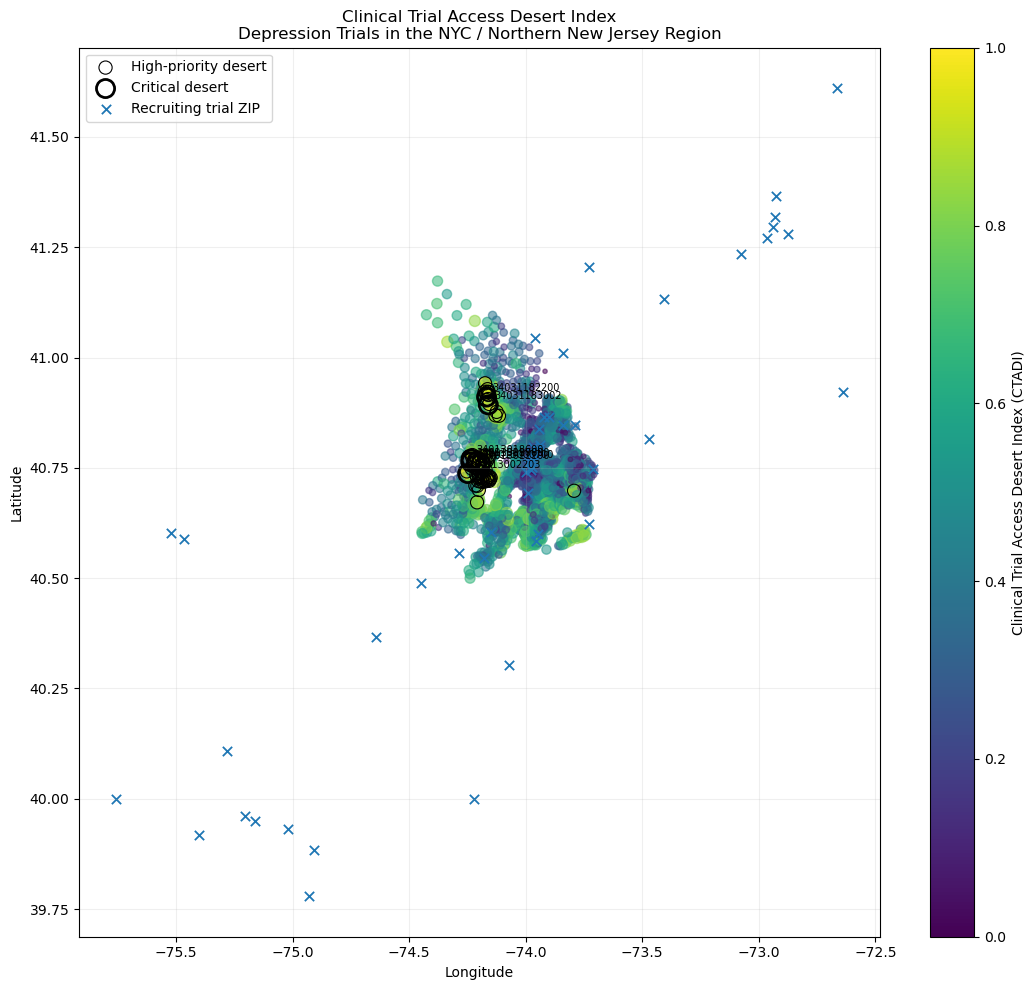

In [24]:
# ============================================================
# STEP 6B
# MAP THE FINAL CLINICAL TRIAL ACCESS DESERT INDEX
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Scored tracts only
# ------------------------------------------------------------

map_df = (
    tract_analysis_df[
        tract_analysis_df[
            "ctadi_score"
        ].notna()
    ]
    .copy()
)


critical_df = (
    map_df[
        map_df[
            "critical_desert"
        ]
    ]
    .copy()
)


high_priority_df = (
    map_df[
        map_df[
            "high_priority_desert"
        ]
        &
        ~map_df[
            "critical_desert"
        ]
    ]
    .copy()
)


# ============================================================
# MAP
# ============================================================

plt.figure(
    figsize=(11, 10)
)


# ------------------------------------------------------------
# All tracts
#
# Size increases with CTADI.
# ------------------------------------------------------------

plt.scatter(
    map_df["longitude"],
    map_df["latitude"],
    s=(
        8
        +
        map_df["ctadi_score"] * 0.7
    ),
    c=map_df["ctadi_score"],
    alpha=0.55
)


# ------------------------------------------------------------
# High-priority desert outlines
# ------------------------------------------------------------

plt.scatter(
    high_priority_df["longitude"],
    high_priority_df["latitude"],
    s=90,
    facecolors="none",
    edgecolors="black",
    linewidths=0.8,
    label="High-priority desert"
)


# ------------------------------------------------------------
# Critical desert outlines
# ------------------------------------------------------------

plt.scatter(
    critical_df["longitude"],
    critical_df["latitude"],
    s=170,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Critical desert"
)


# ------------------------------------------------------------
# Recruiting ZIP centroids
# ------------------------------------------------------------

plt.scatter(
    zip_site_df["site_longitude"],
    zip_site_df["site_latitude"],
    marker="x",
    s=45,
    linewidths=1.3,
    label="Recruiting trial ZIP"
)


# ------------------------------------------------------------
# Labels for critical tracts
# ------------------------------------------------------------

for _, row in critical_df.iterrows():

    plt.annotate(
        str(row["locationid"]),
        (
            row["longitude"],
            row["latitude"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.colorbar(
    label="Clinical Trial Access Desert Index (CTADI)"
)

plt.xlabel(
    "Longitude"
)

plt.ylabel(
    "Latitude"
)

plt.title(
    "Clinical Trial Access Desert Index\n"
    "Depression Trials in the NYC / Northern New Jersey Region"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [25]:
# ============================================================
# STEP 6C
# EXACT CRITICAL DESERT TRACTS
# ============================================================

critical_desert_table = (
    tract_analysis_df[
        tract_analysis_df[
            "critical_desert"
        ]
    ]
    [
        [
            "locationid",
            "study_county",
            "latitude",
            "longitude",
            "data_value",
            "estimated_adults_with_depression",
            "socioeconomic_vulnerability_score",
            "refined_need_percentile",
            "nearest_trial_site_miles",
            "unique_trials_within_10mi",
            "trial_access_disadvantage_percentile",
            "ctadi_score",
            "ctadi_percentile"
        ]
    ]
    .sort_values(
        "ctadi_score",
        ascending=False
    )
)

print("THE 8 CRITICAL CLINICAL TRIAL ACCESS DESERTS")
print("--------------------------------------------")

print(
    critical_desert_table
    .round(1)
    .to_string(index=False)
)

critical_desert_table.to_csv(
    "ctadi_critical_desert_tracts.csv",
    index=False
)

print()
print("Saved: ctadi_critical_desert_tracts.csv")

THE 8 CRITICAL CLINICAL TRIAL ACCESS DESERTS
--------------------------------------------
 locationid       study_county  latitude  longitude  data_value  estimated_adults_with_depression  socioeconomic_vulnerability_score  refined_need_percentile  nearest_trial_site_miles  unique_trials_within_10mi  trial_access_disadvantage_percentile  ctadi_score  ctadi_percentile
34031182200 Passaic County, NJ      40.9      -74.2        17.5                             481.4                               90.2                     93.2                      12.8                        0.0                                  97.2         95.2             100.0
34013018600   Essex County, NJ      40.8      -74.2        16.8                             618.7                               83.7                     93.8                      12.4                        0.0                                  96.4         95.1             100.0
34031183002 Passaic County, NJ      40.9      -74.2        18.4       

In [26]:
# ============================================================
# STEP 7A
# OPTIMAL LOCATION FOR ONE NEW RECRUITING TRIAL SITE
#
# PRIMARY TARGET:
#   63 strict high-priority deserts
#
# SENSITIVITY TARGET:
#   8 critical deserts
#
# Candidate locations:
#   Every scored census-tract centroid in the study region
#
# IMPORTANT:
# This identifies an optimal GEOGRAPHIC TARGET AREA,
# not an exact hospital or building.
# ============================================================

import numpy as np
import pandas as pd


EARTH_RADIUS_MILES = 3958.7613


# ============================================================
# 1. CANDIDATE LOCATIONS
#
# Every CTADI-scored tract centroid is allowed to compete.
# ============================================================

candidate_df = (
    tract_analysis_df[
        tract_analysis_df[
            "ctadi_score"
        ].notna()
        &
        tract_analysis_df[
            "latitude"
        ].notna()
        &
        tract_analysis_df[
            "longitude"
        ].notna()
    ]
    [
        [
            "locationid",
            "study_county",
            "latitude",
            "longitude",
            "ctadi_score",
            "refined_need_percentile",
            "trial_access_disadvantage_percentile"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


print("SITE-PLACEMENT CANDIDATES")
print("-------------------------")

print(
    "Candidate tract centroids:",
    len(candidate_df)
)


# ============================================================
# 2. HAVERSINE DISTANCE MATRIX FUNCTION
# ============================================================

def haversine_candidate_target_matrix(
    candidates,
    targets
):

    candidate_lat = np.radians(
        candidates[
            "latitude"
        ].to_numpy(
            dtype=float
        )
    )[:, None]


    candidate_lon = np.radians(
        candidates[
            "longitude"
        ].to_numpy(
            dtype=float
        )
    )[:, None]


    target_lat = np.radians(
        targets[
            "latitude"
        ].to_numpy(
            dtype=float
        )
    )[None, :]


    target_lon = np.radians(
        targets[
            "longitude"
        ].to_numpy(
            dtype=float
        )
    )[None, :]


    delta_lat = (
        target_lat
        -
        candidate_lat
    )


    delta_lon = (
        target_lon
        -
        candidate_lon
    )


    a = (
        np.sin(
            delta_lat / 2
        ) ** 2

        +

        np.cos(
            candidate_lat
        )
        *
        np.cos(
            target_lat
        )
        *
        np.sin(
            delta_lon / 2
        ) ** 2
    )


    c = (
        2
        *
        np.arcsin(
            np.sqrt(a)
        )
    )


    return (
        EARTH_RADIUS_MILES
        *
        c
    )


# ============================================================
# 3. OPTIMIZATION FUNCTION
# ============================================================

def evaluate_new_site(
    target_mask,
    analysis_name
):

    targets = (
        tract_analysis_df[
            target_mask
            &
            tract_analysis_df[
                "latitude"
            ].notna()
            &
            tract_analysis_df[
                "longitude"
            ].notna()
        ]
        .copy()
        .reset_index(drop=True)
    )


    print()
    print(
        analysis_name
    )

    print(
        "-" * len(analysis_name)
    )

    print(
        "Target tracts:",
        len(targets)
    )


    # --------------------------------------------------------
    # NEED WEIGHT
    #
    # Higher modeled depression burden
    # AND higher refined population need
    # receive greater weight.
    # --------------------------------------------------------

    targets[
        "site_placement_weight"
    ] = (
        targets[
            "estimated_adults_with_depression"
        ]
        *
        (
            targets[
                "refined_need_percentile"
            ]
            /
            100
        )
    )


    weights = (
        targets[
            "site_placement_weight"
        ]
        .to_numpy(
            dtype=float
        )
    )


    depression_burden = (
        targets[
            "estimated_adults_with_depression"
        ]
        .to_numpy(
            dtype=float
        )
    )


    current_distance = (
        targets[
            "nearest_trial_site_miles"
        ]
        .to_numpy(
            dtype=float
        )
    )[None, :]


    critical_target = (
        targets[
            "critical_desert"
        ]
        .fillna(False)
        .to_numpy(
            dtype=bool
        )
    )


    # --------------------------------------------------------
    # Distance from every candidate location
    # to every target desert tract
    # --------------------------------------------------------

    candidate_distance = (
        haversine_candidate_target_matrix(
            candidate_df,
            targets
        )
    )


    # --------------------------------------------------------
    # New nearest-site distance if candidate were added
    # --------------------------------------------------------

    new_nearest_distance = np.minimum(
        current_distance,
        candidate_distance
    )


    distance_reduction = (
        current_distance
        -
        new_nearest_distance
    )


    # ========================================================
    # PRIMARY OBJECTIVE
    #
    # Need-weighted average reduction in nearest-site distance
    # ========================================================

    weighted_distance_reduction = (
        distance_reduction
        *
        weights[None, :]
    ).sum(
        axis=1
    )


    weighted_avg_miles_reduced = (
        weighted_distance_reduction
        /
        weights.sum()
    )


    # ========================================================
    # OTHER INTERPRETABLE OUTCOMES
    # ========================================================

    tracts_improved = (
        distance_reduction
        >
        0.10
    ).sum(
        axis=1
    )


    tracts_within_5_after = (
        new_nearest_distance
        <=
        5
    ).sum(
        axis=1
    )


    tracts_within_10_after = (
        new_nearest_distance
        <=
        10
    ).sum(
        axis=1
    )


    depression_burden_within_5_after = (
        (
            new_nearest_distance
            <=
            5
        )
        *
        depression_burden[
            None, :
        ]
    ).sum(
        axis=1
    )


    depression_burden_within_10_after = (
        (
            new_nearest_distance
            <=
            10
        )
        *
        depression_burden[
            None, :
        ]
    ).sum(
        axis=1
    )


    # --------------------------------------------------------
    # Critical-desert outcomes
    # --------------------------------------------------------

    critical_within_5_after = (
        (
            new_nearest_distance[
                :,
                critical_target
            ]
            <=
            5
        )
        .sum(
            axis=1
        )
    )


    critical_within_10_after = (
        (
            new_nearest_distance[
                :,
                critical_target
            ]
            <=
            10
        )
        .sum(
            axis=1
        )
    )


    # ========================================================
    # BUILD CANDIDATE RANKING
    # ========================================================

    ranking = (
        candidate_df
        .copy()
    )


    ranking[
        "weighted_avg_miles_reduced"
    ] = (
        weighted_avg_miles_reduced
    )


    ranking[
        "weighted_distance_reduction"
    ] = (
        weighted_distance_reduction
    )


    ranking[
        "target_tracts_improved"
    ] = (
        tracts_improved
    )


    ranking[
        "target_tracts_within_5mi_after"
    ] = (
        tracts_within_5_after
    )


    ranking[
        "target_tracts_within_10mi_after"
    ] = (
        tracts_within_10_after
    )


    ranking[
        "modeled_depression_burden_within_5mi_after"
    ] = (
        depression_burden_within_5_after
    )


    ranking[
        "modeled_depression_burden_within_10mi_after"
    ] = (
        depression_burden_within_10_after
    )


    ranking[
        "critical_deserts_within_5mi_after"
    ] = (
        critical_within_5_after
    )


    ranking[
        "critical_deserts_within_10mi_after"
    ] = (
        critical_within_10_after
    )


    ranking = (
        ranking
        .sort_values(
            [
                "weighted_avg_miles_reduced",
                "critical_deserts_within_5mi_after",
                "target_tracts_within_5mi_after"
            ],
            ascending=[
                False,
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )


    ranking[
        "optimization_rank"
    ] = (
        np.arange(
            1,
            len(ranking) + 1
        )
    )


    # ========================================================
    # BASELINE
    # ========================================================

    print()

    print(
        "Baseline targets within 5 miles:",
        int(
            (
                current_distance[0]
                <=
                5
            ).sum()
        )
    )

    print(
        "Baseline targets within 10 miles:",
        int(
            (
                current_distance[0]
                <=
                10
            ).sum()
        )
    )


    if critical_target.sum() > 0:

        print(
            "Baseline critical deserts within 5 miles:",
            int(
                (
                    current_distance[
                        0,
                        critical_target
                    ]
                    <=
                    5
                ).sum()
            )
        )

        print(
            "Baseline critical deserts within 10 miles:",
            int(
                (
                    current_distance[
                        0,
                        critical_target
                    ]
                    <=
                    10
                ).sum()
            )
        )


    return (
        ranking,
        targets
    )


# ============================================================
# 4. PRIMARY OPTIMIZATION
#
# 63 strict high-priority deserts
# ============================================================

primary_ranking_df, primary_targets_df = (
    evaluate_new_site(

        tract_analysis_df[
            "high_priority_desert"
        ],

        "PRIMARY OPTIMIZATION — 63 HIGH-PRIORITY DESERTS"
    )
)


# ============================================================
# 5. SENSITIVITY OPTIMIZATION
#
# 8 critical deserts only
# ============================================================

critical_ranking_df, critical_targets_df = (
    evaluate_new_site(

        tract_analysis_df[
            "critical_desert"
        ],

        "SENSITIVITY OPTIMIZATION — 8 CRITICAL DESERTS"
    )
)


# ============================================================
# 6. TOP 20 PRIMARY CANDIDATE TARGET AREAS
# ============================================================

print()
print(
    "TOP 20 GEOGRAPHIC TARGET AREAS — PRIMARY OPTIMIZATION"
)

print(
    "-----------------------------------------------------"
)


print(
    primary_ranking_df[
        [
            "optimization_rank",
            "locationid",
            "study_county",
            "latitude",
            "longitude",

            "weighted_avg_miles_reduced",

            "target_tracts_improved",
            "target_tracts_within_5mi_after",
            "target_tracts_within_10mi_after",

            "modeled_depression_burden_within_5mi_after",

            "critical_deserts_within_5mi_after",
            "critical_deserts_within_10mi_after"
        ]
    ]
    .head(20)
    .round(2)
    .to_string(
        index=False
    )
)


# ============================================================
# 7. BEST PRIMARY LOCATION
# ============================================================

best_primary = (
    primary_ranking_df
    .iloc[0]
)


print()
print("BEST PRIMARY GEOGRAPHIC TARGET")
print("------------------------------")

print(
    "Tract:",
    best_primary[
        "locationid"
    ]
)

print(
    "County:",
    best_primary[
        "study_county"
    ]
)

print(
    "Latitude:",
    round(
        best_primary[
            "latitude"
        ],
        5
    )
)

print(
    "Longitude:",
    round(
        best_primary[
            "longitude"
        ],
        5
    )
)

print(
    "Need-weighted average miles reduced:",
    round(
        best_primary[
            "weighted_avg_miles_reduced"
        ],
        2
    )
)

print(
    "High-priority deserts improved:",
    int(
        best_primary[
            "target_tracts_improved"
        ]
    )
)

print(
    "High-priority deserts within 5 miles after:",
    int(
        best_primary[
            "target_tracts_within_5mi_after"
        ]
    )
)

print(
    "Critical deserts within 5 miles after:",
    int(
        best_primary[
            "critical_deserts_within_5mi_after"
        ]
    ),
    "of 8"
)


# ============================================================
# 8. BEST CRITICAL-DESERT SENSITIVITY LOCATION
# ============================================================

best_critical = (
    critical_ranking_df
    .iloc[0]
)


print()
print("BEST CRITICAL-DESERT SENSITIVITY TARGET")
print("---------------------------------------")

print(
    "Tract:",
    best_critical[
        "locationid"
    ]
)

print(
    "County:",
    best_critical[
        "study_county"
    ]
)

print(
    "Latitude:",
    round(
        best_critical[
            "latitude"
        ],
        5
    )
)

print(
    "Longitude:",
    round(
        best_critical[
            "longitude"
        ],
        5
    )
)

print(
    "Need-weighted average miles reduced:",
    round(
        best_critical[
            "weighted_avg_miles_reduced"
        ],
        2
    )
)


# ============================================================
# 9. SAVE
# ============================================================

primary_ranking_df.to_csv(
    "ctadi_new_site_candidate_ranking.csv",
    index=False
)


critical_ranking_df.to_csv(
    "ctadi_new_site_candidate_ranking_critical_sensitivity.csv",
    index=False
)


print()
print("STEP 7A FILES SAVED")
print("-------------------")

print(
    "ctadi_new_site_candidate_ranking.csv"
)

print(
    "ctadi_new_site_candidate_ranking_critical_sensitivity.csv"
)

SITE-PLACEMENT CANDIDATES
-------------------------
Candidate tract centroids: 3025

PRIMARY OPTIMIZATION — 63 HIGH-PRIORITY DESERTS
-----------------------------------------------
Target tracts: 63

Baseline targets within 5 miles: 0
Baseline targets within 10 miles: 38
Baseline critical deserts within 5 miles: 0
Baseline critical deserts within 10 miles: 0

SENSITIVITY OPTIMIZATION — 8 CRITICAL DESERTS
---------------------------------------------
Target tracts: 8

Baseline targets within 5 miles: 0
Baseline targets within 10 miles: 0
Baseline critical deserts within 5 miles: 0
Baseline critical deserts within 10 miles: 0

TOP 20 GEOGRAPHIC TARGET AREAS — PRIMARY OPTIMIZATION
-----------------------------------------------------
 optimization_rank  locationid     study_county  latitude  longitude  weighted_avg_miles_reduced  target_tracts_improved  target_tracts_within_5mi_after  target_tracts_within_10mi_after  modeled_depression_burden_within_5mi_after  critical_deserts_within_5mi_

In [27]:
# ============================================================
# STEP 7B
# TEST REAL-WORLD FACILITIES AGAINST MATHEMATICAL OPTIMUM
# ============================================================

import requests
import numpy as np
import pandas as pd
import time


# ------------------------------------------------------------
# Candidate real-world facilities
# ------------------------------------------------------------

real_facilities = [

    {
        "facility":
            "Rutgers New Jersey Medical School Clinical Research Unit",

        "address":
            "90 Bergen Street, Newark, NJ 07103, USA"
    },

    {
        "facility":
            "Biotrial Inc.",

        "address":
            "130 Norfolk Street, Newark, NJ 07103, USA"
    }

]


# ============================================================
# 1. GEOCODE EXACT ADDRESSES
# ============================================================

NOMINATIM_URL = (
    "https://nominatim.openstreetmap.org/search"
)


headers = {

    "User-Agent":
        "ClinicalTrialAccessDesertIndex/"
        "1.0 academic-research"
}


facility_rows = []


for facility in real_facilities:

    response = requests.get(

        NOMINATIM_URL,

        params={
            "q":
                facility["address"],

            "format":
                "jsonv2",

            "limit":
                1,

            "countrycodes":
                "us"
        },

        headers=headers,

        timeout=60
    )


    response.raise_for_status()

    results = response.json()


    if len(results) == 0:

        print(
            "NO MATCH:",
            facility["facility"]
        )

        continue


    result = results[0]


    facility_rows.append({

        "facility":
            facility["facility"],

        "address":
            facility["address"],

        "latitude":
            float(
                result["lat"]
            ),

        "longitude":
            float(
                result["lon"]
            ),

        "geocode_match":
            result.get(
                "display_name"
            )
    })


    time.sleep(1.1)


real_facility_df = pd.DataFrame(
    facility_rows
)


print(
    "REAL-WORLD FACILITIES"
)

print(
    "---------------------"
)

print(
    real_facility_df
    .to_string(
        index=False
    )
)


# ============================================================
# 2. HIGH-PRIORITY DESERT TARGETS
# ============================================================

targets = (
    tract_analysis_df[
        tract_analysis_df[
            "high_priority_desert"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


targets[
    "site_placement_weight"
] = (

    targets[
        "estimated_adults_with_depression"
    ]

    *

    (
        targets[
            "refined_need_percentile"
        ]
        /
        100
    )
)


weights = (
    targets[
        "site_placement_weight"
    ]
    .to_numpy(
        dtype=float
    )
)


current_distance = (
    targets[
        "nearest_trial_site_miles"
    ]
    .to_numpy(
        dtype=float
    )
)


# ============================================================
# 3. DISTANCE FUNCTION
# ============================================================

def distance_to_targets(
    site_lat,
    site_lon,
    targets
):

    R = 3958.7613


    lat1 = np.radians(
        site_lat
    )


    lon1 = np.radians(
        site_lon
    )


    lat2 = np.radians(
        targets[
            "latitude"
        ].to_numpy(
            dtype=float
        )
    )


    lon2 = np.radians(
        targets[
            "longitude"
        ].to_numpy(
            dtype=float
        )
    )


    dlat = lat2 - lat1

    dlon = lon2 - lon1


    a = (

        np.sin(
            dlat / 2
        ) ** 2

        +

        np.cos(
            lat1
        )
        *
        np.cos(
            lat2
        )
        *
        np.sin(
            dlon / 2
        ) ** 2
    )


    return (

        2
        *
        R
        *
        np.arcsin(
            np.sqrt(a)
        )
    )


# ============================================================
# 4. ADD MATHEMATICAL OPTIMUM
# ============================================================

comparison_sites = [

    {
        "facility":
            "Mathematical optimum",

        "latitude":
            40.75419,

        "longitude":
            -74.18777
    }

]


for _, row in real_facility_df.iterrows():

    comparison_sites.append({

        "facility":
            row["facility"],

        "latitude":
            row["latitude"],

        "longitude":
            row["longitude"]
    })


# ============================================================
# 5. EVALUATE EACH REAL LOCATION
# ============================================================

comparison_rows = []


for site in comparison_sites:

    candidate_distance = (
        distance_to_targets(

            site["latitude"],

            site["longitude"],

            targets
        )
    )


    new_nearest = np.minimum(

        current_distance,

        candidate_distance
    )


    distance_reduction = (

        current_distance
        -
        new_nearest
    )


    weighted_avg_reduction = (

        (
            distance_reduction
            *
            weights
        ).sum()

        /
        weights.sum()
    )


    comparison_rows.append({

        "facility":
            site["facility"],

        "latitude":
            site["latitude"],

        "longitude":
            site["longitude"],

        "weighted_avg_miles_reduced":
            weighted_avg_reduction,

        "high_priority_tracts_improved":
            (
                distance_reduction
                >
                0.1
            ).sum(),

        "high_priority_within_5mi_after":
            (
                new_nearest
                <=
                5
            ).sum(),

        "high_priority_within_10mi_after":
            (
                new_nearest
                <=
                10
            ).sum(),

        "critical_within_5mi_after":
            (
                new_nearest[
                    targets[
                        "critical_desert"
                    ].to_numpy(
                        dtype=bool
                    )
                ]
                <=
                5
            ).sum(),

        "critical_within_10mi_after":
            (
                new_nearest[
                    targets[
                        "critical_desert"
                    ].to_numpy(
                        dtype=bool
                    )
                ]
                <=
                10
            ).sum()
    })


facility_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        "weighted_avg_miles_reduced",
        ascending=False
    )
)


# ============================================================
# 6. % OF THEORETICAL OPTIMUM RETAINED
# ============================================================

optimal_reduction = (
    facility_comparison_df.loc[
        facility_comparison_df[
            "facility"
        ]
        ==
        "Mathematical optimum",
        "weighted_avg_miles_reduced"
    ]
    .iloc[0]
)


facility_comparison_df[
    "pct_of_optimal_impact"
] = (

    facility_comparison_df[
        "weighted_avg_miles_reduced"
    ]

    /

    optimal_reduction

    *
    100
)


print()
print(
    "REAL-WORLD SITE COMPARISON"
)

print(
    "--------------------------"
)

print(

    facility_comparison_df
    .round(2)
    .to_string(
        index=False
    )
)


facility_comparison_df.to_csv(

    "ctadi_real_world_site_comparison.csv",

    index=False
)


print()

print(
    "Saved: "
    "ctadi_real_world_site_comparison.csv"
)

REAL-WORLD FACILITIES
---------------------
                                                facility                                   address  latitude  longitude                                                                                              geocode_match
Rutgers New Jersey Medical School Clinical Research Unit   90 Bergen Street, Newark, NJ 07103, USA 40.740773 -74.192109              90, Bergen Street, University Heights, Newark, Essex County, New Jersey, 07103, United States
                                           Biotrial Inc. 130 Norfolk Street, Newark, NJ 07103, USA 40.745544 -74.183063 130, Norfolk Street, University Heights, Roseville, Newark, Essex County, New Jersey, 07103, United States

REAL-WORLD SITE COMPARISON
--------------------------
                                                facility  latitude  longitude  weighted_avg_miles_reduced  high_priority_tracts_improved  high_priority_within_5mi_after  high_priority_within_10mi_after  critical_within_5

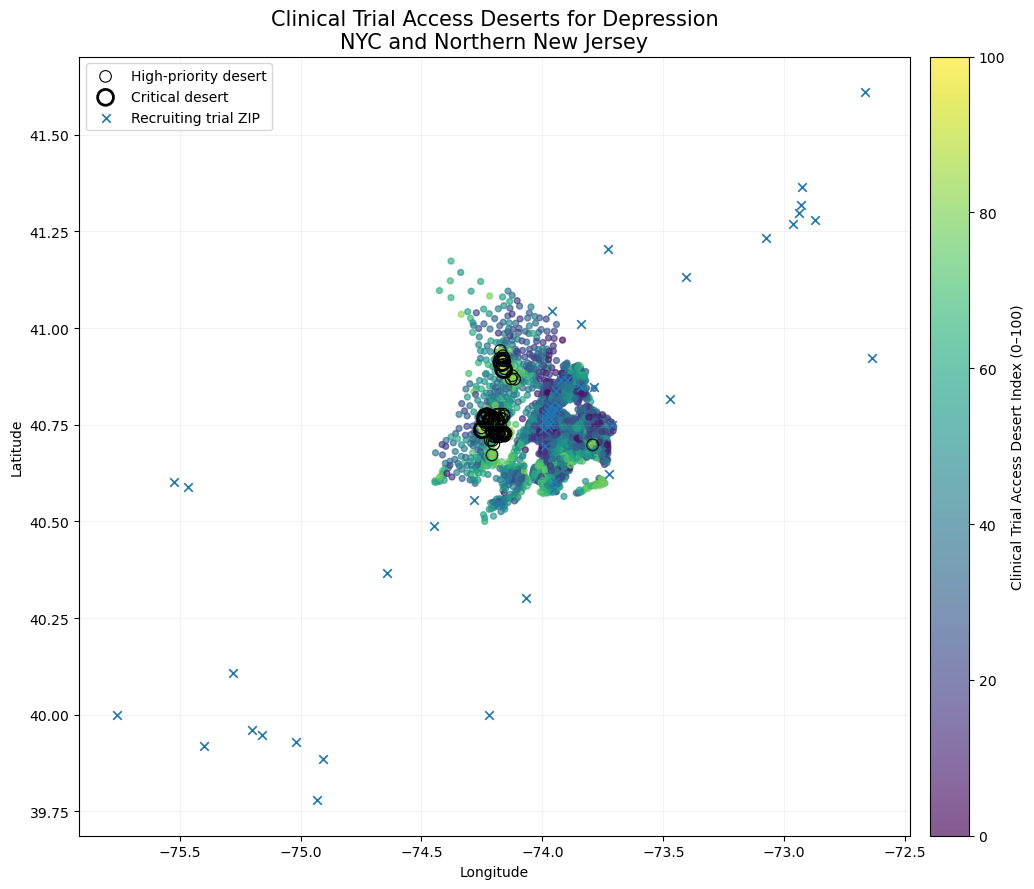

Saved: figure1_ctadi_map.png


In [28]:
# ============================================================
# FINAL FIGURE 1
# CLINICAL TRIAL ACCESS DESERT INDEX
#
# Portfolio-quality version
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

map_df = (
    tract_analysis_df[
        tract_analysis_df["ctadi_score"].notna()
    ]
    .copy()
)

critical_df = (
    map_df[
        map_df["critical_desert"]
    ]
    .copy()
)

high_priority_only_df = (
    map_df[
        map_df["high_priority_desert"]
        &
        ~map_df["critical_desert"]
    ]
    .copy()
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 9)
)


# ------------------------------------------------------------
# All census tracts
# ------------------------------------------------------------

scatter = ax.scatter(
    map_df["longitude"],
    map_df["latitude"],

    c=map_df["ctadi_score"],

    s=18,

    alpha=0.65,

    vmin=0,
    vmax=100
)


# ------------------------------------------------------------
# High-priority deserts
# ------------------------------------------------------------

ax.scatter(
    high_priority_only_df["longitude"],
    high_priority_only_df["latitude"],

    s=70,

    facecolors="none",

    edgecolors="black",

    linewidths=0.8,

    label="High-priority desert"
)


# ------------------------------------------------------------
# Critical deserts
# ------------------------------------------------------------

ax.scatter(
    critical_df["longitude"],
    critical_df["latitude"],

    s=130,

    facecolors="none",

    edgecolors="black",

    linewidths=2,

    label="Critical desert"
)


# ------------------------------------------------------------
# Recruiting trial ZIPs
# ------------------------------------------------------------

ax.scatter(
    zip_site_df["site_longitude"],
    zip_site_df["site_latitude"],

    marker="x",

    s=38,

    linewidths=1.2,

    label="Recruiting trial ZIP"
)


# ------------------------------------------------------------
# Color bar
# ------------------------------------------------------------

cbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Clinical Trial Access Desert Index (0–100)"
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_title(
    "Clinical Trial Access Deserts for Depression\n"
    "NYC and Northern New Jersey",
    fontsize=15
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.legend(
    loc="upper left"
)

ax.grid(
    alpha=0.15
)

fig.tight_layout()


# ------------------------------------------------------------
# SAVE HIGH-RESOLUTION VERSION
# ------------------------------------------------------------

plt.savefig(
    "figure1_ctadi_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved: figure1_ctadi_map.png"
)

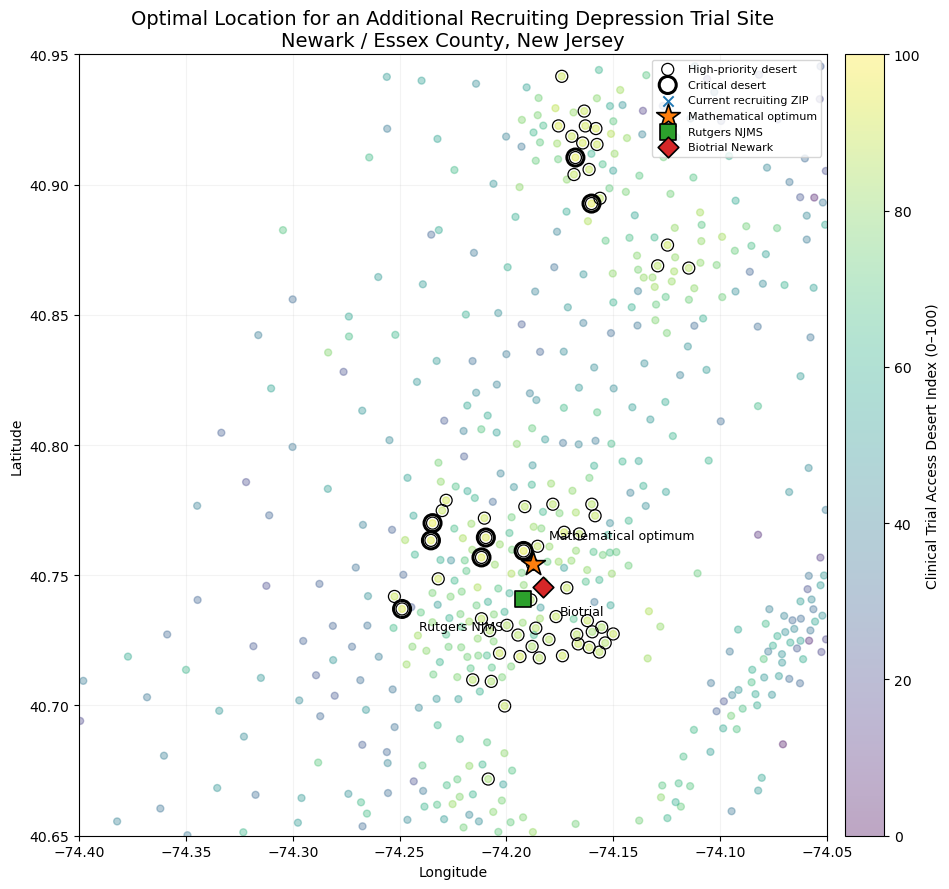

Saved: figure2_newark_site_placement.png


In [29]:
# ============================================================
# FINAL FIGURE 2
# OPTIMAL NEW DEPRESSION TRIAL SITE — NEWARK
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Data
# ------------------------------------------------------------

high_priority_df = (
    tract_analysis_df[
        tract_analysis_df["high_priority_desert"]
    ]
    .copy()
)

critical_df = (
    tract_analysis_df[
        tract_analysis_df["critical_desert"]
    ]
    .copy()
)


# ------------------------------------------------------------
# Recommended locations from optimization
# ------------------------------------------------------------

site_options = {

    "Mathematical optimum": {
        "latitude": 40.75419,
        "longitude": -74.18777
    },

    "Rutgers NJMS Clinical Research Unit": {
        "latitude": 40.740773,
        "longitude": -74.192109
    },

    "Biotrial Newark": {
        "latitude": 40.745544,
        "longitude": -74.183063
    }
}


# ------------------------------------------------------------
# Focus map around Newark / Essex / Passaic
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9)
)


# ------------------------------------------------------------
# Background scored tracts
# ------------------------------------------------------------

regional_zoom_df = (
    tract_analysis_df[
        tract_analysis_df["ctadi_score"].notna()
        &
        tract_analysis_df["longitude"].between(
            -74.40,
            -74.05
        )
        &
        tract_analysis_df["latitude"].between(
            40.65,
            40.95
        )
    ]
)


scatter = ax.scatter(

    regional_zoom_df["longitude"],
    regional_zoom_df["latitude"],

    c=regional_zoom_df["ctadi_score"],

    s=25,

    alpha=0.35,

    vmin=0,
    vmax=100
)


# ------------------------------------------------------------
# High-priority deserts
# ------------------------------------------------------------

ax.scatter(

    high_priority_df["longitude"],
    high_priority_df["latitude"],

    s=75,

    facecolors="none",

    edgecolors="black",

    linewidths=0.9,

    label="High-priority desert"
)


# ------------------------------------------------------------
# Critical deserts
# ------------------------------------------------------------

ax.scatter(

    critical_df["longitude"],
    critical_df["latitude"],

    s=150,

    facecolors="none",

    edgecolors="black",

    linewidths=2.2,

    label="Critical desert"
)


# ------------------------------------------------------------
# Existing recruiting ZIP centroids in zoom window
# ------------------------------------------------------------

zoom_trial_sites = (
    zip_site_df[
        zip_site_df[
            "site_longitude"
        ].between(
            -74.40,
            -74.05
        )
        &
        zip_site_df[
            "site_latitude"
        ].between(
            40.65,
            40.95
        )
    ]
)


ax.scatter(

    zoom_trial_sites["site_longitude"],
    zoom_trial_sites["site_latitude"],

    marker="x",

    s=55,

    linewidths=1.4,

    label="Current recruiting ZIP"
)


# ============================================================
# Recommended sites
# ============================================================

# Mathematical optimum
ax.scatter(

    site_options[
        "Mathematical optimum"
    ]["longitude"],

    site_options[
        "Mathematical optimum"
    ]["latitude"],

    marker="*",

    s=320,

    edgecolors="black",

    linewidths=1.2,

    label="Mathematical optimum"
)


# Rutgers
ax.scatter(

    site_options[
        "Rutgers NJMS Clinical Research Unit"
    ]["longitude"],

    site_options[
        "Rutgers NJMS Clinical Research Unit"
    ]["latitude"],

    marker="s",

    s=130,

    edgecolors="black",

    linewidths=1.2,

    label="Rutgers NJMS"
)


# Biotrial
ax.scatter(

    site_options[
        "Biotrial Newark"
    ]["longitude"],

    site_options[
        "Biotrial Newark"
    ]["latitude"],

    marker="D",

    s=110,

    edgecolors="black",

    linewidths=1.2,

    label="Biotrial Newark"
)


# ------------------------------------------------------------
# Site labels
# ------------------------------------------------------------

ax.annotate(

    "Mathematical optimum",

    (
        -74.18777,
        40.75419
    ),

    xytext=(12, 18),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(

    "Rutgers NJMS",

    (
        -74.192109,
        40.740773
    ),

    xytext=(-75, -22),

    textcoords="offset points",

    fontsize=9
)


ax.annotate(

    "Biotrial",

    (
        -74.183063,
        40.745544
    ),

    xytext=(12, -20),

    textcoords="offset points",

    fontsize=9
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

cbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    "Clinical Trial Access Desert Index (0–100)"
)


ax.set_title(

    "Optimal Location for an Additional Recruiting Depression Trial Site\n"
    "Newark / Essex County, New Jersey",

    fontsize=14
)


ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)


ax.set_xlim(
    -74.40,
    -74.05
)

ax.set_ylim(
    40.65,
    40.95
)


ax.legend(
    loc="upper right",
    fontsize=8
)


ax.grid(
    alpha=0.15
)


fig.tight_layout()


plt.savefig(

    "figure2_newark_site_placement.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


print(
    "Saved: figure2_newark_site_placement.png"
)